# Quote-Then-Judge: Evidence-Conditioned Coding of AMR Policy Documents

## Experiment

This experiment evaluates whether retrieving and explicitly presenting textual
evidence, together with candidate-code definitions, improves automated coding
of five policy-document dimensions:

1. ERIC implementation strategies — multi-label
2. Focus — multi-label
3. Level of implementation — single-label
4. Maturity of implementation — single-label
5. Mechanism — single-label

Pipeline:

Document
   ↓
Candidate-conditioned retrieval
   ↓
Relevant passage
   ↓
Candidate + definition + passage
   ↓
Quote evidence
   ↓
YES / NO judgement
   ↓
Document/intervention-level prediction
   ↓
Evaluation

Primary model:
Qwen/Qwen2.5-7B-Instruct + LoRA

This notebook first performs a fold-4 pilot.
Final thesis results should use the established five-fold grouped CV protocol.

In [ ]:
!pip -q install \
    "transformers>=4.44" \
    "accelerate>=0.33" \
    "peft>=0.12" \
    "trl>=0.9" \
    "bitsandbytes>=0.43" \
    "sentence-transformers>=3.0" \
    "datasets>=2.20" \
    "scikit-learn>=1.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 45.3 MB/s eta 0:00:00


In [ ]:
import os
import gc
import gzip
import json
import math
import random
import re
import time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch

SEED = 20260817

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("GPU is required for this experiment.")

gpu = torch.cuda.get_device_properties(0)

print("GPU:", gpu.name)
print(f"VRAM: {gpu.total_memory / 1e9:.1f} GB")
print(f"Compute capability: sm_{gpu.major}{gpu.minor}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB
Compute capability: sm_89


In [ ]:
# ============================================================
# DRIVE OUTPUT FOLDER
# ============================================================

DRIVE_FOLD = OUT / f"fold_{HELD_OUT_FOLD}"
DRIVE_FOLD.mkdir(parents=True, exist_ok=True)

print("Drive fold output:", DRIVE_FOLD)

Drive fold output: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4


In [ ]:
# ============================================================
# PROJECT PATH
# ============================================================

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")

if not BASE.exists():
    raise FileNotFoundError(
        f"Project folder not found: {BASE}\n"
        "Please make sure Quote_Then_Judge is uploaded/mounted in /content."
    )

print("Project folder:", BASE)
print("\nFiles found:")

for p in sorted(BASE.iterdir()):
    print("  ", p.name)


# ============================================================
# EXPERIMENT CONFIG
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# Pilot fold.
# Final thesis evaluation will use all five folds.
HELD_OUT_FOLD = 4

# Retrieval
TOP_CHUNKS = 3
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
MAX_DOCUMENT_CHUNKS = 400

# Pair construction
HARD_NEGATIVES = 3
EASY_NEGATIVES = 1

# Model
MAX_SEQ = 1536

# LoRA
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# Start conservatively.
EPOCHS = 3
LR = 1e-4

# L4-friendly defaults.
BATCH = 1
ACCUM = 16

# Main experiment.
ABLATION_NO_DEFINITION = False

# Five dimensions.
DIMENSIONS = [
    "eric",
    "focus",
    "level",
    "maturity",
    "mechanism",
]

MULTI_LABEL_DIMS = {
    "eric",
    "focus",
}

SINGLE_LABEL_DIMS = {
    "level",
    "maturity",
    "mechanism",
}

OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True, parents=True)

print("\nConfiguration:")
print("MODEL:", MODEL_NAME)
print("HELD_OUT_FOLD:", HELD_OUT_FOLD)
print("DIMENSIONS:", DIMENSIONS)
print("ABLATION_NO_DEFINITION:", ABLATION_NO_DEFINITION)
print("OUTPUT:", OUT)

Project folder: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge

Files found:
   corpus_documents.json.gz
   dimension_definitions.json
   eric_strategies.json
   gold_full.json
   quote_then_judge.ipynb
   verdict_inputs.json

Configuration:
MODEL: Qwen/Qwen2.5-7B-Instruct
HELD_OUT_FOLD: 4
DIMENSIONS: ['eric', 'focus', 'level', 'maturity', 'mechanism']
ABLATION_NO_DEFINITION: False
OUTPUT: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs


In [ ]:
OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True, parents=True)


# ============================================================
# DRIVE OUTPUT FOLDER
# ============================================================

DRIVE_FOLD = OUT / f"fold_{HELD_OUT_FOLD}"
DRIVE_FOLD.mkdir(parents=True, exist_ok=True)

print("Drive fold output:", DRIVE_FOLD)


print("\nConfiguration:")
print("MODEL:", MODEL_NAME)
print("HELD_OUT_FOLD:", HELD_OUT_FOLD)
print("DIMENSIONS:", DIMENSIONS)
print("ABLATION_NO_DEFINITION:", ABLATION_NO_DEFINITION)
print("OUTPUT:", OUT)

Drive fold output: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4

Configuration:
MODEL: Qwen/Qwen2.5-7B-Instruct
HELD_OUT_FOLD: 4
DIMENSIONS: ['eric', 'focus', 'level', 'maturity', 'mechanism']
ABLATION_NO_DEFINITION: False
OUTPUT: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs


In [ ]:
# ============================================================
# FILE PATHS
# ============================================================

DOC_PATH = BASE / "corpus_documents.json.gz"
GOLD_PATH = BASE / "gold_full.json"
VERDICT_PATH = BASE / "verdict_inputs.json"
ERIC_PATH = BASE / "eric_strategies.json"
DIMDEF_PATH = BASE / "dimension_definitions.json"


required = [
    DOC_PATH,
    GOLD_PATH,
    VERDICT_PATH,
    ERIC_PATH,
    DIMDEF_PATH,
]

missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required project files:\n" + "\n".join(missing)
    )


# ============================================================
# LOAD
# ============================================================

with gzip.open(DOC_PATH, "rt", encoding="utf-8") as f:
    docs = json.load(f)

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    gold = json.load(f)

with open(VERDICT_PATH, "r", encoding="utf-8") as f:
    verdict_inputs = json.load(f)

with open(ERIC_PATH, "r", encoding="utf-8") as f:
    eric_strategies = json.load(f)

with open(DIMDEF_PATH, "r", encoding="utf-8") as f:
    dimension_definitions = json.load(f)


print("Loaded successfully.")
print("Documents:", len(docs))
print("Gold records:", len(gold))
print("Verdict inputs keys:", list(verdict_inputs.keys())[:10])
print("ERIC strategy object type:", type(eric_strategies).__name__)
print("Dimension definitions:", list(dimension_definitions.keys()))

Loaded successfully.
Documents: 221
Gold records: 228
Verdict inputs keys: ['fusion_predictions', 'fusion_gold', 'definitions', 'categories']
ERIC strategy object type: dict
Dimension definitions: ['focus', 'level', 'maturity', 'mechanism']


In [ ]:
print("=" * 70)
print("VERDICT INPUTS")
print("=" * 70)

print("Top-level keys:", list(verdict_inputs.keys()))

if "definitions" in verdict_inputs:
    print("Number of verdict definitions:", len(verdict_inputs["definitions"]))
    print("First 3:")
    for k, v in list(verdict_inputs["definitions"].items())[:3]:
        print("\n", k)
        print(v[:500] if isinstance(v, str) else v)


print("\n" + "=" * 70)
print("ERIC STRATEGIES")
print("=" * 70)

if isinstance(eric_strategies, dict):
    print("Keys:", list(eric_strategies.keys())[:20])
    print("Number of top-level entries:", len(eric_strategies))

elif isinstance(eric_strategies, list):
    print("Number of entries:", len(eric_strategies))
    print("First entry:")
    print(eric_strategies[0])


print("\n" + "=" * 70)
print("DIMENSION DEFINITIONS")
print("=" * 70)

for dim, cfg in dimension_definitions.items():
    print("\nDIMENSION:", dim)
    print("keys:", list(cfg.keys()))

    if "values" in cfg:
        print("values:", list(cfg["values"].keys()))

VERDICT INPUTS
Top-level keys: ['fusion_predictions', 'fusion_gold', 'definitions', 'categories']
Number of verdict definitions: 73
First 3:

 Promote adaptability
Identify the ways a clinical innovation can be tailored to meet local needs and clarify which elements of the innovation must be maintained to preserve fidelity

 Tailor strategies
Tailor the implementation strategies to address barriers and leverage facilitators that were identified through earlier data collection

 Use data experts
Involve, hire, and/or consult experts to inform management on the use of data generated by implementation efforts

ERIC STRATEGIES
Keys: ['source', 'counts', 'categories', 'strategies']
Number of top-level entries: 4

DIMENSION DEFINITIONS

DIMENSION: focus
keys: ['multi_label', 'values']
values: ['AMR', 'AMU', 'IPC', 'Antimicrobial Stewardship', 'Public Education & Awareness Campaign', 'Health Industry & Workforce', 'Technology and R&D']

DIMENSION: level
keys: ['multi_label', 'values']
values:

In [ ]:
# ============================================================
# ERIC DEFINITIONS
# ============================================================

if "definitions" in verdict_inputs:
    ERIC_DEFS = dict(verdict_inputs["definitions"])
else:
    ERIC_DEFS = {}


# If eric_strategies contains additional authoritative definitions,
# inspect them rather than silently replacing the verdict definitions.

print("ERIC definitions available:", len(ERIC_DEFS))

if len(ERIC_DEFS) == 0:
    raise ValueError("No ERIC definitions found in verdict_inputs.json.")

print("\nExample ERIC definitions:")
for name, definition in list(ERIC_DEFS.items())[:5]:
    print(f"\n{name}")
    print(definition)

ERIC definitions available: 73

Example ERIC definitions:

Promote adaptability
Identify the ways a clinical innovation can be tailored to meet local needs and clarify which elements of the innovation must be maintained to preserve fidelity

Tailor strategies
Tailor the implementation strategies to address barriers and leverage facilitators that were identified through earlier data collection

Use data experts
Involve, hire, and/or consult experts to inform management on the use of data generated by implementation efforts

Use data warehousing techniques
Integrate clinical records across facilities and organizations to facilitate implementation across systems

Change accreditation or membership requirements
Strive to alter accreditation standards so that they require or encourage use of the clinical innovation. Work to alter membership organization requirements so that those who want to affiliate with the organization are encouraged or required to use the clinical innovation


In [ ]:
# ============================================================
# CANDIDATE CODEBOOK
# ============================================================

CANDIDATES = {}

# ERIC
CANDIDATES["eric"] = dict(ERIC_DEFS)

# Other dimensions
for dim in ["focus", "level", "maturity", "mechanism"]:
    cfg = dimension_definitions.get(dim)

    if cfg is None:
        raise KeyError(f"Missing dimension definition for: {dim}")

    values = cfg.get("values", {})

    if not isinstance(values, dict):
        raise TypeError(
            f"Expected {dim}.values to be a dictionary, "
            f"got {type(values).__name__}"
        )

    CANDIDATES[dim] = dict(values)


print("Candidate counts:")
for dim in DIMENSIONS:
    print(f"  {dim:12s}: {len(CANDIDATES[dim])}")

Candidate counts:
  eric        : 73
  focus       : 7
  level       : 3
  maturity    : 3
  mechanism   : 3


In [ ]:
# ============================================================
# CODEBOOK VALIDATION + FINAL DIMENSION DEFINITIONS
# ============================================================

# IMPORTANT:
# Keep the canonical labels from dimension_definitions.json.
# Replace only the TODO placeholder definitions with the
# operational definitions used by this experiment.

# ------------------------------------------------------------
# FOCUS
# ------------------------------------------------------------

CANDIDATES["focus"] = {
    "AMR": (
        "Antimicrobial resistance as a programme or policy focus: "
        "actions, programmes, policies, or interventions explicitly "
        "addressing antimicrobial resistance."
    ),

    "AMU": (
        "Antimicrobial use or consumption as a programme or policy focus: "
        "actions addressing how antimicrobials are prescribed, dispensed, "
        "used, consumed, or otherwise managed."
    ),

    "IPC": (
        "Infection prevention and control: policies, programmes, or "
        "interventions intended to prevent and control infections and "
        "reduce transmission of infectious organisms."
    ),

    "Antimicrobial Stewardship": (
        "Antimicrobial stewardship: coordinated interventions intended "
        "to promote appropriate antimicrobial use, including improving "
        "selection, prescribing, dosing, duration, and review of "
        "antimicrobial therapy."
    ),

    "Public Education & Awareness Campaign": (
        "Public education and awareness campaigns: activities intended "
        "to inform, educate, or raise awareness among the public or "
        "communities about antimicrobial resistance, antimicrobial use, "
        "infection prevention, or related health issues."
    ),

    "Health Industry & Workforce": (
        "Health industry and workforce: policies, programmes, or "
        "interventions focused on health-sector workers, professional "
        "capacity, workforce development, or organisations and industries "
        "involved in health service delivery."
    ),

    "Technology and R&D": (
        "Technology and research and development: policies, programmes, "
        "or interventions focused on diagnostic, laboratory, surveillance, "
        "technological, research, or development activities relevant to "
        "antimicrobial resistance and related health-system priorities."
    ),
}


# ------------------------------------------------------------
# LEVEL
# ------------------------------------------------------------

CANDIDATES["level"] = {
    "Macro": (
        "International, regional, or national level: the intervention "
        "operates through national, regional, international, or "
        "system-wide policy and governance structures."
    ),

    "Meso": (
        "Organisational level: the intervention operates within or "
        "across organisations such as hospitals, health facilities, "
        "universities, professional organisations, laboratories, or "
        "other institutions."
    ),

    "Micro": (
        "Individual level: the intervention primarily targets individual "
        "people, such as individual health professionals, patients, "
        "students, or members of the public."
    ),
}


# ------------------------------------------------------------
# MATURITY
# ------------------------------------------------------------

CANDIDATES["maturity"] = {
    "Developed": (
        "Developed: the intervention or policy has been written, "
        "designed, formulated, or otherwise developed, but there is "
        "no evidence that it is yet operating in practice."
    ),

    "Implemented": (
        "Implemented: the intervention or policy is actively being "
        "carried out or operationalised in practice."
    ),

    "Evaluated": (
        "Evaluated: the intervention or policy has been assessed or "
        "measured to determine its implementation, effects, outcomes, "
        "or performance."
    ),
}


# ------------------------------------------------------------
# MECHANISM
# ------------------------------------------------------------

CANDIDATES["mechanism"] = {
    "Regulative": (
        "Regulative mechanism: implementation is shaped through formal "
        "rules, laws, regulations, policies, contracts, sanctions, "
        "authoritative requirements, or other formal control mechanisms."
    ),

    "Normative": (
        "Normative mechanism: implementation is shaped through "
        "professional norms, standards, expectations, roles, routines, "
        "work practices, or shared expectations about appropriate behaviour."
    ),

    "Cultural-Cognitive": (
        "Cultural-cognitive mechanism: implementation is shaped through "
        "shared beliefs, values, understandings, assumptions, meanings, "
        "or taken-for-granted ways of interpreting and responding to an issue."
    ),
}


# ============================================================
# VALIDATE
# ============================================================

print("=" * 70)
print("FINAL CODEBOOK VALIDATION")
print("=" * 70)

for dim in DIMENSIONS:

    values = CANDIDATES[dim]

    print(f"\n[{dim}]")
    print("Candidates:", len(values))

    for name, definition in values.items():

        assert isinstance(name, str)
        assert isinstance(definition, str)

        if not definition.strip():
            raise ValueError(
                f"Empty definition: {dim}/{name}"
            )

        if definition.upper().startswith("TODO"):
            raise ValueError(
                f"TODO definition remains: {dim}/{name}"
            )

        print(f"  ✓ {name}")

print("\n" + "=" * 70)
print("CODEBOOK SUMMARY")
print("=" * 70)

for dim in DIMENSIONS:
    print(
        f"{dim:12s} | "
        f"{len(CANDIDATES[dim]):2d} candidates | "
        f"{'MULTI' if dim in MULTI_LABEL_DIMS else 'SINGLE'}"
    )

print("\n✓ All five dimensions have usable definitions.")
print("✓ No TODO placeholders remain.")

FINAL CODEBOOK VALIDATION

[eric]
Candidates: 73
  ✓ Promote adaptability
  ✓ Tailor strategies
  ✓ Use data experts
  ✓ Use data warehousing techniques
  ✓ Change accreditation or membership requirements
  ✓ Change liability laws
  ✓ Change physical structure and equipment
  ✓ Change record systems
  ✓ Change service sites
  ✓ Create or change credentialing and/or licensure standards
  ✓ Mandate change
  ✓ Start a dissemination organization
  ✓ Build a coalition
  ✓ Capture and share local knowledge
  ✓ Conduct local consensus discussions
  ✓ Develop academic partnerships
  ✓ Develop an implementation glossary
  ✓ Identify and prepare champions
  ✓ Identify early adopters
  ✓ Inform local opinion leaders
  ✓ Involve executive boards
  ✓ Model and simulate change
  ✓ Obtain formal commitments
  ✓ Organize clinician implementation team meetings
  ✓ Promote network weaving
  ✓ Recruit, designate, and train for leadership
  ✓ Use advisory boards and workgroups
  ✓ Use an implementation ad

Diagnostic for cell 9 basically (above) one

In [ ]:
# ============================================================
# DIAGNOSTIC: SHOW ALL DIMENSION DEFINITIONS
# ============================================================

for dim in ["focus", "level", "maturity", "mechanism"]:

    print("\n" + "=" * 80)
    print(dim.upper())
    print("=" * 80)

    cfg = dimension_definitions.get(dim, {})

    print("multi_label:", cfg.get("multi_label"))
    print()

    values = cfg.get("values", {})

    for label, definition in values.items():

        print(f"LABEL: {label}")
        print(f"DEFINITION: {definition}")
        print("-" * 60)


FOCUS
multi_label: True

LABEL: AMR
DEFINITION: TODO - SPAARTA definition of antimicrobial resistance as a programme focus
------------------------------------------------------------
LABEL: AMU
DEFINITION: TODO - SPAARTA definition of antimicrobial use / consumption
------------------------------------------------------------
LABEL: IPC
DEFINITION: TODO - SPAARTA definition of infection prevention and control
------------------------------------------------------------
LABEL: Antimicrobial Stewardship
DEFINITION: TODO - SPAARTA definition of stewardship
------------------------------------------------------------
LABEL: Public Education & Awareness Campaign
DEFINITION: TODO - SPAARTA definition
------------------------------------------------------------
LABEL: Health Industry & Workforce
DEFINITION: TODO - SPAARTA definition
------------------------------------------------------------
LABEL: Technology and R&D
DEFINITION: TODO - SPAARTA definition
-----------------------------------

In [ ]:
# ============================================================
# GOLD LABEL EXTRACTION
# ============================================================

def gold_values(g, dim):
    """
    Return canonical gold labels for a record.

    ERIC:
        multi-label list

    Focus:
        supports slash/comma/semicolon/ampersand/'and' composites

    Level/Maturity/Mechanism:
        single-label matching against the candidate ontology
    """

    if dim == "eric":
        return set(g.get("eric_codes") or [])

    if dim == "focus":
        raw = g.get("focus") or ""

        parts = re.split(
            r"[/,;&]|\band\b",
            str(raw),
            flags=re.IGNORECASE
        )

        return {
            p.strip()
            for p in parts
            if p.strip()
        }

    raw = g.get(dim)

    if raw is None or str(raw).strip() == "":
        return set()

    raw_str = str(raw).strip().lower()

    for candidate in CANDIDATES[dim]:

        base = candidate.lower().split(" (")[0]

        if base == raw_str or base in raw_str:
            return {candidate}

    return set()


# ============================================================
# DISTRIBUTIONS
# ============================================================

for dim in DIMENSIONS:

    counts = Counter()

    for row in gold:
        for value in gold_values(row, dim):
            counts[value] += 1

    print("\n" + "=" * 60)
    print(dim.upper())
    print("=" * 60)

    for value, count in counts.most_common():
        print(f"{count:4d}  {value}")

    print("Records with at least one label:",
          sum(1 for row in gold if gold_values(row, dim)))

    print("Missing/no usable label:",
          sum(1 for row in gold if not gold_values(row, dim)))


ERIC
 149  Capture and share local knowledge
 145  Audit and provide feedback
 123  Distribute educational materials
 113  Conduct ongoing training
  97  Use data experts
  83  Use data warehousing techniques
  73  Assess for readiness and identify barriers and facilitators
  73  Centralize technical assistance
  59  Change physical structure and equipment
  59  Involve executive boards
  58  Change record systems
  57  Change liability laws
  56  Use mass media
  54  Develop and implement tools for quality monitoring
  53  Tailor strategies
  50  Provide local technical assistance
  49  Develop academic partnerships
  47  Develop and organize quality monitoring systems
  38  Access new funding
  36  Create a learning collaborative
  34  Build a coalition
  32  Change service sites
  31  Involve patients/consumers and family members
  28  Facilitation
  26  Create or change credentialing and/or licensure standards
  24  Prepare patients/consumers to be active participants
  23  Work w

In [ ]:
# ============================================================
# FOLD VALIDATION
# ============================================================

fold_counts = Counter()

for row in gold:
    fold_counts[row.get("fold")] += 1

print("Records by fold:")
for fold, n in sorted(fold_counts.items()):
    print(f"  fold {fold}: {n}")

print("\nExpected approximate fold structure:")
print("  [50, 52, 43, 42, 41]")


# ============================================================
# DOCUMENT → FOLD CONSISTENCY
# ============================================================

doc_to_folds = defaultdict(set)

for row in gold:
    fold = row.get("fold")

    for did in row.get("doc_ids", []):
        doc_to_folds[did].add(fold)

leaky_docs = {
    did: folds
    for did, folds in doc_to_folds.items()
    if len(folds) > 1
}

print("\nDocuments appearing in multiple folds:", len(leaky_docs))

if leaky_docs:
    print("Examples:")
    for did, folds in list(leaky_docs.items())[:10]:
        print(did, folds)

    raise ValueError(
        "Document-level fold leakage detected. "
        "Do not train until this is resolved."
    )

print("✓ No document appears across multiple folds.")

Records by fold:
  fold 0: 50
  fold 1: 52
  fold 2: 43
  fold 3: 42
  fold 4: 41

Expected approximate fold structure:
  [50, 52, 43, 42, 41]

Documents appearing in multiple folds: 0
✓ No document appears across multiple folds.


In [ ]:
from sentence_transformers import SentenceTransformer

print("Loading multilingual-e5-large...")

enc = SentenceTransformer(
    "intfloat/multilingual-e5-large",
    device="cuda"
)

enc.max_seq_length = 256

print("Retrieval model ready.")

Loading multilingual-e5-large...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Retrieval model ready.


In [ ]:
# ============================================================
# TEXT PROCESSING
# ============================================================

def chunk_text(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    text = str(text or "")

    if not text.strip():
        return []

    chunks = []
    start = 0

    while start < len(text):
        end = min(start + size, len(text))
        chunk = text[start:end].strip()

        if chunk:
            chunks.append(chunk)

        if end >= len(text):
            break

        start = end - overlap

    return chunks


def split_sentences(text):
    text = str(text or "")

    parts = re.split(
        r"(?<=[.!?])\s+|\n+",
        text
    )

    parts = [
        x.strip()
        for x in parts
        if len(x.strip()) > 25
    ]

    return parts or ([text[:300]] if text.strip() else [])


def document_text(doc):
    if isinstance(doc, dict):
        return str(doc.get("text", ""))
    return str(doc)


print("Text utilities ready.")

Text utilities ready.


In [ ]:
# ============================================================
# CANDIDATE EMBEDDINGS
# ============================================================

ALL_CANDIDATES = [
    (dim, value)
    for dim in DIMENSIONS
    for value in CANDIDATES[dim]
]

print("Total candidate values:", len(ALL_CANDIDATES))

CVEC = {}

for dim in DIMENSIONS:

    names = list(CANDIDATES[dim].keys())

    queries = [
        f"query: {name}. {CANDIDATES[dim][name]}"
        for name in names
    ]

    vectors = enc.encode(
        queries,
        normalize_embeddings=True,
        batch_size=32,
        show_progress_bar=True
    )

    for name, vector in zip(names, vectors):
        CVEC[(dim, name)] = np.asarray(vector)

print("Candidate embeddings:", len(CVEC))

Total candidate values: 89


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Candidate embeddings: 89


In [ ]:
# ============================================================
# RETRIEVAL
# ============================================================

EVIDENCE_PATH = OUT / "evidence_qtj_fold4.json"

evidence = {}

t0 = time.time()

for i, (did, doc) in enumerate(sorted(docs.items()), 1):

    text = document_text(doc)

    chunks = chunk_text(text)

    chunks = chunks[:MAX_DOCUMENT_CHUNKS]

    if not chunks:
        continue

    passage_vectors = enc.encode(
        ["passage: " + c for c in chunks],
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=False
    )

    passage_vectors = np.asarray(passage_vectors)

    per_document = {}

    for dim, value in ALL_CANDIDATES:

        candidate_vector = CVEC[(dim, value)]

        similarities = passage_vectors @ candidate_vector

        top_idx = np.argsort(-similarities)[:TOP_CHUNKS]

        selected_chunks = [
            chunks[j]
            for j in sorted(top_idx)
        ]

        passage = "\n---\n".join(selected_chunks)

        # Sentence-level evidence selection
        best_chunk_index = int(top_idx[0])

        sents = split_sentences(chunks[best_chunk_index])

        if sents:

            sentence_vectors = enc.encode(
                ["passage: " + s for s in sents],
                normalize_embeddings=True,
                batch_size=32,
                show_progress_bar=False
            )

            sentence_vectors = np.asarray(sentence_vectors)

            sentence_scores = sentence_vectors @ candidate_vector

            best_sentence = sents[int(np.argmax(sentence_scores))]

        else:
            best_sentence = chunks[best_chunk_index][:300]

        per_document[f"{dim}|{value}"] = {
            "passage": passage[:2500],
            "evidence": best_sentence[:300],
            "similarity": float(np.max(similarities)),
        }

    evidence[did] = per_document

    if i % 20 == 0 or i == len(docs):

        elapsed = time.time() - t0
        remaining = len(docs) - i

        eta = (
            elapsed / i * remaining
            if i
            else 0
        )

        print(
            f"{i}/{len(docs)} | "
            f"{elapsed/60:.1f} min elapsed | "
            f"{eta/60:.1f} min remaining",
            flush=True
        )


EVIDENCE_PATH.write_text(
    json.dumps(
        evidence,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

print("\nEvidence saved:", EVIDENCE_PATH)
print("Documents with evidence:", len(evidence))

20/221 | 1.9 min elapsed | 19.3 min remaining
40/221 | 3.8 min elapsed | 17.1 min remaining
60/221 | 5.5 min elapsed | 14.7 min remaining
80/221 | 7.3 min elapsed | 12.8 min remaining
100/221 | 9.0 min elapsed | 10.8 min remaining
120/221 | 10.8 min elapsed | 9.1 min remaining
140/221 | 12.5 min elapsed | 7.3 min remaining
160/221 | 14.3 min elapsed | 5.5 min remaining
180/221 | 16.4 min elapsed | 3.7 min remaining
200/221 | 18.2 min elapsed | 1.9 min remaining
220/221 | 19.7 min elapsed | 0.1 min remaining
221/221 | 19.7 min elapsed | 0.0 min remaining

Evidence saved: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/evidence_qtj_fold4.json
Documents with evidence: 221


In [ ]:
# ============================================================
# RANDOM RETRIEVAL INSPECTION
# ============================================================

available_ids = list(evidence.keys())

random.seed(SEED)

sample_ids = random.sample(
    available_ids,
    min(10, len(available_ids))
)

for did in sample_ids:

    print("\n" + "=" * 100)
    print("DOCUMENT:", did)
    print("=" * 100)

    entries = evidence[did]

    for key, item in list(entries.items())[:3]:

        print("\nCANDIDATE:", key)
        print("SIMILARITY:", round(item["similarity"], 4))

        print("\nEVIDENCE:")
        print(item["evidence"])

        print("\nPASSAGE:")
        print(item["passage"][:800])


DOCUMENT: Uganda_05

CANDIDATE: eric|Promote adaptability
SIMILARITY: 0.8007

EVIDENCE:
Promote innovations for new antimicrobial drug development, vaccines, and other innovative

PASSAGE:
ive dissemination of guidelines.
4. Facilitate continued education and training to promote responsible prescribing practices,
dispensing and administering principles for antimicrobials.
3.2 Strategic Objective 2: Improve Infection Prevention and Control 
In order to prevent the spread of resistant infections, it is important to implement infection 
prevention programs across human and animal communities and health care settings through 
individual and environmental sanitation and hygiene, as well as through biosecurity measures 
throughout the entire value chain from farm to plate. Infection prevention and control (IPC) 
measures in healthcare facilities as well as immunization and sanitation and hygiene in the 
community reduce the risk of transmission of infections and minimize the need 

CANDIDAT

In [ ]:
# ============================================================
# EXPERT-VALIDATED DOCUMENT CHECK
# ============================================================

EXPERT_DOC_IDS = [
    "Malawi_07",
    "Zambia_04",
    "Kosovo_10",
    "Ghana_09",
    "Uganda_12",
]

expert_gold = {}

for target in EXPERT_DOC_IDS:

    matches = [
        row
        for row in gold
        if target in row.get("doc_ids", [])
        or target == row.get("name")
        or target == row.get("id")
    ]

    expert_gold[target] = matches

    print(
        target,
        "→",
        len(matches),
        "gold record(s)"
    )

Malawi_07 → 1 gold record(s)
Zambia_04 → 1 gold record(s)
Kosovo_10 → 1 gold record(s)
Ghana_09 → 2 gold record(s)
Uganda_12 → 1 gold record(s)


In [ ]:
# ============================================================
# EXPERT-VALIDATED DOCUMENT CHECK
# ============================================================

EXPERT_DOC_IDS = [
    "Malawi_07",
    "Zambia_04",
    "Kosovo_10",
    "Ghana_09",
    "Uganda_12",
]

expert_gold = {}

for target in EXPERT_DOC_IDS:

    matches = [
        row
        for row in gold
        if target in row.get("doc_ids", [])
        or target == row.get("name")
        or target == row.get("id")
    ]

    expert_gold[target] = matches

    print(
        target,
        "→",
        len(matches),
        "gold record(s)"
    )

Malawi_07 → 1 gold record(s)
Zambia_04 → 1 gold record(s)
Kosovo_10 → 1 gold record(s)
Ghana_09 → 2 gold record(s)
Uganda_12 → 1 gold record(s)


In [ ]:
# ============================================================
# TRAINING PAIRS
# ============================================================

random.seed(SEED)

pairs = []

for row in gold:

    did_candidates = [
        d
        for d in row.get("doc_ids", [])
        if d in evidence
    ]

    if not did_candidates:
        continue

    did = did_candidates[0]

    for dim in DIMENSIONS:

        positive = (
            gold_values(row, dim)
            & set(CANDIDATES[dim])
        )

        if not positive:
            # Missing gold / unsupported category.
            continue

        negative_pool = [
            value
            for value in CANDIDATES[dim]
            if value not in positive
        ]

        # Rank negatives by similarity to nearest true candidate.
        ranked_negatives = sorted(
            negative_pool,
            key=lambda value: -max(
                float(
                    np.dot(
                        CVEC[(dim, value)],
                        CVEC[(dim, true_value)]
                    )
                )
                for true_value in positive
            )
        )

        n_hard = min(
            HARD_NEGATIVES * len(positive),
            len(ranked_negatives)
        )

        hard = ranked_negatives[:n_hard]

        remaining = ranked_negatives[n_hard:]

        n_easy = min(
            EASY_NEGATIVES * len(positive),
            len(remaining)
        )

        easy = random.sample(
            remaining,
            n_easy
        )

        selected = list(positive) + hard + easy

        for value in selected:

            item = evidence[did][f"{dim}|{value}"]

            is_positive = value in positive

            pairs.append({
                "doc": did,
                "fold": row.get("fold"),
                "dim": dim,
                "value": value,
                "definition": CANDIDATES[dim][value],
                "passage": item["passage"],
                "evidence": (
                    item["evidence"]
                    if is_positive
                    else ""
                ),
                "label": (
                    "YES"
                    if is_positive
                    else "NO"
                ),
                "negtype": (
                    "pos"
                    if is_positive
                    else (
                        "hard"
                        if value in hard
                        else "easy"
                    )
                )
            })


print("Total pairs:", f"{len(pairs):,}")

print("\nBy dimension:")
for dim, n in Counter(p["dim"] for p in pairs).items():
    print(f"  {dim:12s}: {n:,}")

print("\nBy label:")
print(Counter(p["label"] for p in pairs))

print("\nBy pair type:")
print(Counter(p["negtype"] for p in pairs))

Total pairs: 11,902

By dimension:
  eric        : 8,803
  focus       : 1,113
  level       : 681
  maturity    : 684
  mechanism   : 621

By label:
Counter({'NO': 8991, 'YES': 2911})

By pair type:
Counter({'hard': 7528, 'pos': 2911, 'easy': 1463})


In [ ]:
# ============================================================
# TRAINING PAIRS
# ============================================================

random.seed(SEED)

pairs = []

for row in gold:

    did_candidates = [
        d
        for d in row.get("doc_ids", [])
        if d in evidence
    ]

    if not did_candidates:
        continue

    did = did_candidates[0]

    for dim in DIMENSIONS:

        positive = (
            gold_values(row, dim)
            & set(CANDIDATES[dim])
        )

        if not positive:
            # Missing gold / unsupported category.
            continue

        negative_pool = [
            value
            for value in CANDIDATES[dim]
            if value not in positive
        ]

        # Rank negatives by similarity to nearest true candidate.
        ranked_negatives = sorted(
            negative_pool,
            key=lambda value: -max(
                float(
                    np.dot(
                        CVEC[(dim, value)],
                        CVEC[(dim, true_value)]
                    )
                )
                for true_value in positive
            )
        )

        n_hard = min(
            HARD_NEGATIVES * len(positive),
            len(ranked_negatives)
        )

        hard = ranked_negatives[:n_hard]

        remaining = ranked_negatives[n_hard:]

        n_easy = min(
            EASY_NEGATIVES * len(positive),
            len(remaining)
        )

        easy = random.sample(
            remaining,
            n_easy
        )

        selected = list(positive) + hard + easy

        for value in selected:

            item = evidence[did][f"{dim}|{value}"]

            is_positive = value in positive

            pairs.append({
                "doc": did,
                "fold": row.get("fold"),
                "dim": dim,
                "value": value,
                "definition": CANDIDATES[dim][value],
                "passage": item["passage"],
                "evidence": (
                    item["evidence"]
                    if is_positive
                    else ""
                ),
                "label": (
                    "YES"
                    if is_positive
                    else "NO"
                ),
                "negtype": (
                    "pos"
                    if is_positive
                    else (
                        "hard"
                        if value in hard
                        else "easy"
                    )
                )
            })


print("Total pairs:", f"{len(pairs):,}")

print("\nBy dimension:")
for dim, n in Counter(p["dim"] for p in pairs).items():
    print(f"  {dim:12s}: {n:,}")

print("\nBy label:")
print(Counter(p["label"] for p in pairs))

print("\nBy pair type:")
print(Counter(p["negtype"] for p in pairs))

Total pairs: 11,902

By dimension:
  eric        : 8,803
  focus       : 1,113
  level       : 681
  maturity    : 684
  mechanism   : 621

By label:
Counter({'NO': 8991, 'YES': 2911})

By pair type:
Counter({'hard': 7528, 'pos': 2911, 'easy': 1463})


In [ ]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

train_pairs = [
    p
    for p in pairs
    if p["fold"] != HELD_OUT_FOLD
]

test_pairs = [
    p
    for p in pairs
    if p["fold"] == HELD_OUT_FOLD
]

train_docs = {
    p["doc"]
    for p in train_pairs
}

test_docs = {
    p["doc"]
    for p in test_pairs
}

overlap = train_docs & test_docs

print("Training pairs:", f"{len(train_pairs):,}")
print("Test pairs:", f"{len(test_pairs):,}")

print("Training documents:", len(train_docs))
print("Test documents:", len(test_docs))

print("Document overlap:", len(overlap))

if overlap:
    raise ValueError(
        "LEAKAGE: documents occur in both train and test."
    )

print("✓ No document leakage.")

Training pairs: 9,849
Test pairs: 2,053
Training documents: 178
Test documents: 39
Document overlap: 0
✓ No document leakage.


In [ ]:
# ============================================================
# PROMPTS
# ============================================================

SYSTEM_INSTRUCTION = """
You are a policy analyst coding national health policy documents.

The task is to determine whether the candidate code is supported by the
provided policy-document passage.

Policy documents may establish mandates, commitments, plans, programmes,
responsibilities, monitoring arrangements, or other intended actions.
These can constitute evidence when they support the candidate definition.

Do not infer evidence that is not present in the passage.

First identify the sentence that best supports the candidate.
If no sentence supports the candidate, output NONE.
""".strip()


# ============================================================
# STEP 1 — EVIDENCE GENERATION
# ============================================================

def build_evidence_prompt(p):

    definition_text = ""

    if not ABLATION_NO_DEFINITION:
        definition_text = (
            f"\nDEFINITION:\n{p['definition']}\n"
        )

    return f"""
{SYSTEM_INSTRUCTION}

CANDIDATE DIMENSION:
{p['dim']}

CANDIDATE CODE:
{p['value']}
{definition_text}

PASSAGE:
{p['passage']}

TASK:
Identify the single sentence that provides the strongest evidence
for this candidate.

Reply in exactly this format:

EVIDENCE: <quote, or NONE>
""".strip()


# ============================================================
# STEP 2 — JUDGEMENT
# ============================================================

def build_judge_prompt(p, generated_evidence):

    definition_text = ""

    if not ABLATION_NO_DEFINITION:
        definition_text = (
            f"\nDEFINITION:\n{p['definition']}\n"
        )

    return f"""
You are a policy analyst coding national health policy documents.

Determine whether the candidate code is supported by the policy
passage and the quoted evidence.

CANDIDATE DIMENSION:
{p['dim']}

CANDIDATE CODE:
{p['value']}
{definition_text}

PASSAGE:
{p['passage']}

QUOTED EVIDENCE:
{generated_evidence}

Answer YES only when the quoted evidence supports the candidate
according to the definition. Otherwise answer NO.

Reply in exactly this format:

ANSWER: <YES or NO>
""".strip()


# ============================================================
# TRAINING TARGET
# ============================================================

def build_target(p):

    evidence_text = (
        p["evidence"]
        if p["label"] == "YES" and p["evidence"]
        else "NONE"
    )

    return (
        f"EVIDENCE: {evidence_text}\n"
        f"ANSWER: {p['label']}"
    )


# ============================================================
# INSPECTION
# ============================================================

example = next(
    p
    for p in train_pairs
    if p["label"] == "YES"
)

print("=== EVIDENCE PROMPT ===")
print(build_evidence_prompt(example))

print("\n=== TRAINING TARGET ===")
print(build_target(example))

print("\n=== JUDGE PROMPT ===")
print(
    build_judge_prompt(
        example,
        example["evidence"]
    )
)

=== EVIDENCE PROMPT ===
You are a policy analyst coding national health policy documents.

The task is to determine whether the candidate code is supported by the
provided policy-document passage.

Policy documents may establish mandates, commitments, plans, programmes,
responsibilities, monitoring arrangements, or other intended actions.
These can constitute evidence when they support the candidate definition.

Do not infer evidence that is not present in the passage.

First identify the sentence that best supports the candidate.
If no sentence supports the candidate, output NONE.

CANDIDATE DIMENSION:
eric

CANDIDATE CODE:
Develop an implementation glossary

DEFINITION:
Develop and distribute a list of terms describing the innovation, implementation, and stakeholders in the organizational change


PASSAGE:
da por 
informações relativas ao sítio de infecção, ao agente 
causal, à gravidade, aos dados epidemiológicos, ao 
hospedeiro e ao produto a ser utilizado. 
8.1 - sítio da infecção

In [ ]:
# ============================================================
# MODEL
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

from datasets import Dataset as HFDataset


# ============================================================
# TOKENIZER
# ============================================================

tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

print("Tokenizer loaded.")


# ============================================================
# CHECK YES / NO TOKENIZATION
# ============================================================

yes_tokens = tok.encode(
    "YES",
    add_special_tokens=False
)

no_tokens = tok.encode(
    "NO",
    add_special_tokens=False
)

print("YES token IDs:", yes_tokens)
print("NO token IDs:", no_tokens)

if len(yes_tokens) != 1 or len(no_tokens) != 1:
    raise ValueError(
        "YES or NO is not represented as a single token. "
        "The logit-scoring method needs to be adjusted."
    )

YES_ID = yes_tokens[0]
NO_ID = no_tokens[0]


# ============================================================
# 4-BIT QLORA
# ============================================================

use_bf16 = (
    torch.cuda.is_bf16_supported()
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=(
        torch.bfloat16
        if use_bf16
        else torch.float16
    ),
)

print("BF16 supported:", use_bf16)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

trainable params: 10,092,544 || all params: 7,625,709,056 || trainable%: 0.1323


In [ ]:
# ============================================================
# MODEL
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

from datasets import Dataset as HFDataset


# ============================================================
# TOKENIZER
# ============================================================

tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

print("Tokenizer loaded.")


# ============================================================
# CHECK YES / NO TOKENIZATION
# ============================================================

yes_tokens = tok.encode(
    "YES",
    add_special_tokens=False
)

no_tokens = tok.encode(
    "NO",
    add_special_tokens=False
)

print("YES token IDs:", yes_tokens)
print("NO token IDs:", no_tokens)

if len(yes_tokens) != 1 or len(no_tokens) != 1:
    raise ValueError(
        "YES or NO is not represented as a single token. "
        "The logit-scoring method needs to be adjusted."
    )

YES_ID = yes_tokens[0]
NO_ID = no_tokens[0]


# ============================================================
# 4-BIT QLORA
# ============================================================

use_bf16 = (
    torch.cuda.is_bf16_supported()
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=(
        torch.bfloat16
        if use_bf16
        else torch.float16
    ),
)

print("BF16 supported:", use_bf16)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

Tokenizer loaded.
YES token IDs: [14004]
NO token IDs: [8996]
BF16 supported: True


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

trainable params: 10,092,544 || all params: 7,625,709,056 || trainable%: 0.1323


In [ ]:
# ============================================================
# BUILD HUGGING FACE TRAINING DATASET
# ============================================================

train_records = []

for p in train_pairs:

    train_records.append({
        "text": (
            build_evidence_prompt(p)
            + "\n\n"
            + build_target(p)
        )
    })

ds_train = HFDataset.from_list(train_records)

print("Training examples:", len(ds_train))
print("Columns:", ds_train.column_names)

print("\nExample:")
print(ds_train[0]["text"][:3000])

Training examples: 9849
Columns: ['text']

Example:
You are a policy analyst coding national health policy documents.

The task is to determine whether the candidate code is supported by the
provided policy-document passage.

Policy documents may establish mandates, commitments, plans, programmes,
responsibilities, monitoring arrangements, or other intended actions.
These can constitute evidence when they support the candidate definition.

Do not infer evidence that is not present in the passage.

First identify the sentence that best supports the candidate.
If no sentence supports the candidate, output NONE.

CANDIDATE DIMENSION:
eric

CANDIDATE CODE:
Develop an implementation glossary

DEFINITION:
Develop and distribute a list of terms describing the innovation, implementation, and stakeholders in the organizational change


PASSAGE:
da por 
informações relativas ao sítio de infecção, ao agente 
causal, à gravidade, aos dados epidemiológicos, ao 
hospedeiro e ao produto a ser utiliza

In [ ]:
from pathlib import Path

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Main Drive folder for this experiment
DRIVE_ROOT = Path("/content/drive/MyDrive/Quote_Then_Judge")

# Fold-specific folder
DRIVE_FOLD = DRIVE_ROOT / f"fold_{HELD_OUT_FOLD}"

# Create folders
DRIVE_FOLD.mkdir(parents=True, exist_ok=True)

print("Drive output folder:")
print(DRIVE_FOLD)

In [ ]:
# ============================================================
# TRAINING
# ============================================================

# ------------------------------------------------------------
# DRIVE OUTPUT DIRECTORIES
# ------------------------------------------------------------

DRIVE_FOLD.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = DRIVE_FOLD / "checkpoints"
LORA_PATH = DRIVE_FOLD / "lora_main"

CHECKPOINT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

LORA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("All training outputs will be saved to:")
print(DRIVE_FOLD)


# ============================================================
# IMPORTS
# ============================================================

from trl import SFTTrainer, SFTConfig


# ============================================================
# SFT CONFIGURATION
# ============================================================

sft_config = SFTConfig(
    output_dir=str(CHECKPOINT_PATH),

    num_train_epochs=EPOCHS,

    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=ACCUM,

    learning_rate=LR,
    lr_scheduler_type="cosine",

    logging_steps=10,

    save_strategy="epoch",
    save_total_limit=1,

    bf16=use_bf16,
    fp16=not use_bf16,

    gradient_checkpointing=True,

    optim="paged_adamw_8bit",

    report_to=[],

    seed=SEED,

    # SFT-specific settings
    dataset_text_field="text",
    max_length=MAX_SEQ,
    packing=False,
)


# ============================================================
# SFT TRAINER
# ============================================================

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=ds_train,
)


# ============================================================
# START TRAINING
# ============================================================

print("\nStarting training...")
print("Checkpoint directory:", CHECKPOINT_PATH)
print("LoRA directory:", LORA_PATH)

t0 = time.time()

train_result = trainer.train()

elapsed = time.time() - t0

print(
    f"\nTraining completed in {elapsed / 60:.1f} minutes."
)


# ============================================================
# SAVE FINAL LORA ADAPTER TO DRIVE
# ============================================================

model.save_pretrained(LORA_PATH)
tok.save_pretrained(LORA_PATH)

print("\nLoRA saved to:")
print(LORA_PATH)


# ============================================================
# SAVE TRAINING RESULT TO DRIVE
# ============================================================

TRAIN_RESULT_PATH = DRIVE_FOLD / "training_result.json"

result_dict = {
    "model": MODEL_NAME,
    "held_out_fold": HELD_OUT_FOLD,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "batch_size": BATCH,
    "gradient_accumulation": ACCUM,
    "max_seq_length": MAX_SEQ,
    "train_pairs": len(train_pairs),
    "train_documents": len(train_docs),
    "elapsed_minutes": elapsed / 60,
}

if hasattr(train_result, "metrics"):
    result_dict["metrics"] = train_result.metrics

TRAIN_RESULT_PATH.write_text(
    json.dumps(
        result_dict,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

print("\nTraining result saved to:")
print(TRAIN_RESULT_PATH)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n============================================================")
print("TRAINING COMPLETE")
print("============================================================")
print("LoRA adapter:", LORA_PATH)
print("Training result:", TRAIN_RESULT_PATH)

All training outputs will be saved to:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4


Adding EOS to train dataset:   0%|          | 0/9849 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9849 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/9849 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/9849 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/9849 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



Starting training...
Checkpoint directory: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints
LoRA directory: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main


Step,Training Loss
10,2.397727
20,2.072145
30,1.900699
40,1.718648
50,1.663499
60,1.652695
70,1.648055
80,1.596563
90,1.527556
100,1.596240



Training completed in 710.1 minutes.

LoRA saved to:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main

Training result saved to:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/training_result.json

TRAINING COMPLETE
LoRA adapter: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main
Training result: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/training_result.json


In [ ]:
# ============================================================
# INFERENCE UTILITIES
# ============================================================

model.eval()


def batch_prompts(prs, batch_size=4):

    old_padding = tok.padding_side
    tok.padding_side = "left"

    try:

        for start in range(
            0,
            len(prs),
            batch_size
        ):

            batch = prs[
                start:start + batch_size
            ]

            texts = [
                tok.apply_chat_template(
                    [
                        {
                            "role": "user",
                            "content": build_prompt(p),
                        }
                    ],
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for p in batch
            ]

            inputs = tok(
                texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ,
            ).to(model.device)

            yield batch, inputs

    finally:
        tok.padding_side = old_padding


def generate_evidence(prs, batch_size=4):

    outputs = []

    for batch, inputs in batch_prompts(
        prs,
        batch_size
    ):

        with torch.no_grad():

            generated = model.generate(
                **inputs,
                max_new_tokens=80,
                do_sample=False,
                pad_token_id=tok.pad_token_id,
            )

        prompt_length = inputs["input_ids"].shape[1]

        for sequence in generated:

            text = tok.decode(
                sequence[prompt_length:],
                skip_special_tokens=True
            )

            outputs.append(text)

        torch.cuda.empty_cache()

    return outputs


def score_yes(prs, batch_size=4):

    scores = []

    for batch, inputs in batch_prompts(
        prs,
        batch_size
    ):

        with torch.no_grad():

            logits = model(**inputs).logits[:, -1, :]

        pair = torch.stack(
            [
                logits[:, YES_ID],
                logits[:, NO_ID],
            ],
            dim=-1
        )

        probabilities = torch.softmax(
            pair.float(),
            dim=-1
        )[:, 0]

        scores.extend(
            probabilities.cpu().tolist()
        )

        torch.cuda.empty_cache()

    return scores


print("Inference utilities ready.")

In [ ]:
# ============================================================
# HELD-OUT INFERENCE
# ============================================================

print(
    f"Running inference on {len(test_pairs):,} "
    "held-out pairs..."
)

t0 = time.time()

test_generations = generate_evidence(
    test_pairs,
    batch_size=4
)

test_scores = score_yes(
    test_pairs,
    batch_size=4
)

print(
    f"Completed in {(time.time()-t0)/60:.1f} minutes."
)

print("\nExample:")
print(test_generations[0])
print("P(YES):", test_scores[0])

In [ ]:
# ============================================================
# EVIDENCE QUALITY
# ============================================================

yes_quotes = []

for p, response in zip(
    test_pairs,
    parsed
):

    answer, quote = response

    if (
        answer == "YES"
        and quote
        and quote.upper() != "NONE"
    ):
        yes_quotes.append(
            (p, quote)
        )


real_quotes = 0

for p, quote in yes_quotes:

    if quote.lower() in p["passage"].lower():
        real_quotes += 1


print(
    "YES responses with evidence:",
    len(yes_quotes)
)

print(
    "Evidence is exact substring:",
    f"{real_quotes}/{len(yes_quotes)}"
)

if yes_quotes:

    print(
        "Rate:",
        f"{100*real_quotes/len(yes_quotes):.1f}%"
    )

In [ ]:
# ============================================================
# DOCUMENT-LEVEL ASSEMBLY
# ============================================================

def group_pair_predictions(
    pairs_subset,
    scores,
    threshold=0.5
):

    grouped = defaultdict(
        lambda: {
            "scores": {},
            "gold": set(),
        }
    )

    for p, score in zip(
        pairs_subset,
        scores
    ):

        doc = p["doc"]
        dim = p["dim"]
        value = p["value"]

        grouped[(doc, dim)]["scores"][value] = float(score)

        if p["label"] == "YES":
            grouped[(doc, dim)]["gold"].add(value)

    return grouped


def predictions_for_dimension(
    pairs_subset,
    scores,
    dim,
    threshold=0.5
):

    grouped = group_pair_predictions(
        pairs_subset,
        scores,
        threshold
    )

    predictions = []
    gold_labels = []
    doc_ids = []

    for (doc, current_dim), data in grouped.items():

        if current_dim != dim:
            continue

        score_dict = data["scores"]

        if dim in SINGLE_LABEL_DIMS:

            # SINGLE LABEL:
            # choose exactly one candidate.
            best = max(
                score_dict.items(),
                key=lambda x: x[1]
            )[0]

            pred = {best}

        else:

            # MULTI LABEL:
            pred = {
                value
                for value, score in score_dict.items()
                if score >= threshold
            }

        predictions.append(pred)
        gold_labels.append(data["gold"])
        doc_ids.append(doc)

    return (
        predictions,
        gold_labels,
        doc_ids,
    )

In [ ]:
# ============================================================
# METRICS
# ============================================================

def micro_scores(predictions, gold_labels):

    tp = 0
    predicted = 0
    gold_total = 0

    for pred, gold_set in zip(
        predictions,
        gold_labels
    ):

        tp += len(pred & gold_set)
        predicted += len(pred)
        gold_total += len(gold_set)

    precision = (
        tp / predicted
        if predicted
        else 0.0
    )

    recall = (
        tp / gold_total
        if gold_total
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0.0
    )

    return (
        100 * precision,
        100 * recall,
        100 * f1,
    )


def macro_scores(
    predictions,
    gold_labels,
    labels
):

    f1s = []
    precisions = []
    recalls = []

    for label in labels:

        tp = sum(
            label in pred and label in gold_set
            for pred, gold_set
            in zip(predictions, gold_labels)
        )

        fp = sum(
            label in pred and label not in gold_set
            for pred, gold_set
            in zip(predictions, gold_labels)
        )

        fn = sum(
            label not in pred and label in gold_set
            for pred, gold_set
            in zip(predictions, gold_labels)
        )

        precision = (
            tp / (tp + fp)
            if tp + fp
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn
            else 0.0
        )

        f1 = (
            2 * precision * recall
            / (precision + recall)
            if precision + recall
            else 0.0
        )

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return (
        100 * np.mean(precisions),
        100 * np.mean(recalls),
        100 * np.mean(f1s),
    )

In [ ]:
# ============================================================
# FIVE-DIMENSION EVALUATION
# ============================================================

all_results = {}

print(
    f"{'DIMENSION':15s}"
    f"{'MIC-F1':>10s}"
    f"{'MAC-F1':>10s}"
)

print("-" * 40)


for dim in DIMENSIONS:

    predictions, gold_labels, doc_ids = (
        predictions_for_dimension(
            test_pairs,
            test_scores,
            dim,
            threshold=0.5
        )
    )

    if not predictions:
        print(dim, "→ no evaluation data")
        continue

    micro_p, micro_r, micro_f1 = (
        micro_scores(
            predictions,
            gold_labels
        )
    )

    # Evaluate labels actually represented in gold.
    observed_labels = sorted({
        label
        for gold_set in gold_labels
        for label in gold_set
    })

    macro_p, macro_r, macro_f1 = (
        macro_scores(
            predictions,
            gold_labels,
            observed_labels
        )
    )

    all_results[dim] = {
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "n_documents": len(doc_ids),
        "labels_evaluated": observed_labels,
    }

    print(
        f"{dim:15s}"
        f"{micro_f1:10.2f}"
        f"{macro_f1:10.2f}"
    )

In [ ]:
# ============================================================
# ERIC THRESHOLD SWEEP
# ============================================================

ERIC_SWEEP = []

for threshold in [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80,
]:

    pred, gold_labels, _ = (
        predictions_for_dimension(
            test_pairs,
            test_scores,
            "eric",
            threshold=threshold
        )
    )

    if not pred:
        continue

    _, _, micro_f1 = micro_scores(
        pred,
        gold_labels
    )

    observed_labels = sorted({
        label
        for g in gold_labels
        for label in g
    })

    _, _, macro_f1 = macro_scores(
        pred,
        gold_labels,
        observed_labels
    )

    ERIC_SWEEP.append({
        "threshold": threshold,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
    })


print(
    f"{'Threshold':>10s}"
    f"{'Micro-F1':>10s}"
    f"{'Macro-F1':>10s}"
)

for row in ERIC_SWEEP:
    print(
        f"{row['threshold']:10.2f}"
        f"{row['micro_f1']:10.2f}"
        f"{row['macro_f1']:10.2f}"
    )

if ERIC_SWEEP:

    best = max(
        ERIC_SWEEP,
        key=lambda x: x["macro_f1"]
    )

    print(
        "\nBest ERIC macro-F1:",
        f"{best['macro_f1']:.2f}",
        "at threshold",
        best["threshold"]
    )

In [ ]:
# ============================================================
# ERIC RARE-CODE RECOVERY
# ============================================================

gold_support = Counter()

for row in gold:

    for code in row.get(
        "eric_codes",
        []
    ):
        gold_support[code] += 1


predictions, gold_labels, doc_ids = (
    predictions_for_dimension(
        test_pairs,
        test_scores,
        "eric",
        threshold=0.5
    )
)

recovered = set()

for pred, gold_set in zip(
    predictions,
    gold_labels
):

    recovered.update(
        pred & gold_set
    )


rare_codes = sorted(
    [
        code
        for code, support
        in gold_support.items()
        if support <= 15
    ]
)

rare_recovered = [
    code
    for code in rare_codes
    if code in recovered
]

print(
    "Rare ERIC codes (support <= 15):",
    len(rare_codes)
)

print(
    "Rare ERIC codes correctly recovered:",
    len(rare_recovered)
)

for code in rare_recovered:
    print(
        f"  {gold_support[code]:3d}x  {code}"
    )

In [ ]:
# ============================================================
# SAVE RESULTS
# ============================================================

results_payload = {

    "experiment": "Quote-Then-Judge",

    "model": MODEL_NAME,

    "ablation_no_definition": (
        ABLATION_NO_DEFINITION
    ),

    "held_out_fold": HELD_OUT_FOLD,

    "seed": SEED,

    "retrieval": {
        "model": "intfloat/multilingual-e5-large",
        "top_chunks": TOP_CHUNKS,
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
    },

    "training": {
        "epochs": EPOCHS,
        "learning_rate": LR,
        "batch": BATCH,
        "gradient_accumulation": ACCUM,
        "max_sequence_length": MAX_SEQ,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
    },

    "pair_counts": {
        "total": len(pairs),
        "train": len(train_pairs),
        "test": len(test_pairs),
    },

    "results": all_results,

    "eric_threshold_sweep": ERIC_SWEEP,

    "rare_eric": {
        "total_rare": len(rare_codes),
        "recovered": rare_recovered,
    },

    "evidence_quality": {
        "yes_with_quote": len(yes_quotes),
        "real_substring": real_quotes,
        "rate": (
            real_quotes / len(yes_quotes)
            if yes_quotes
            else None
        ),
    },
}


RESULT_PATH = OUT / "results_main_fold4.json"

RESULT_PATH.write_text(
    json.dumps(
        results_payload,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

print("Saved results to:")
print(RESULT_PATH)

In [ ]:
# ============================================================
# PILOT SUMMARY
# ============================================================

print("=" * 70)
print("QUOTE-THEN-JUDGE — FOLD 4 PILOT")
print("=" * 70)

print("\nModel:")
print(MODEL_NAME)

print("\nConfiguration:")
print("Definition included:", not ABLATION_NO_DEFINITION)
print("Held-out fold:", HELD_OUT_FOLD)
print("Epochs:", EPOCHS)
print("LoRA:", LORA_R, LORA_ALPHA, LORA_DROPOUT)

print("\nResults:")

for dim, result in all_results.items():

    print(
        f"\n{dim.upper()}"
    )

    print(
        f"  Micro-F1: {result['micro_f1']:.2f}"
    )

    print(
        f"  Macro-F1: {result['macro_f1']:.2f}"
    )

print("\nEvidence quality:")

if yes_quotes:
    print(
        f"  Real quotes: "
        f"{real_quotes}/{len(yes_quotes)} "
        f"({100*real_quotes/len(yes_quotes):.1f}%)"
    )
else:
    print("  No YES+quote responses.")

print("\nRare ERIC recovery:")
print(
    f"  {len(rare_recovered)}/{len(rare_codes)}"
)

print("\nSaved:")
print(RESULT_PATH)

Checking the model results

Mount the drive and the paths

In [ ]:
# ============================================================
# RECONNECT — DRIVE + PATHS
# ============================================================

from pathlib import Path
import json
import time
import re
import numpy as np
import torch

from collections import defaultdict, Counter

from google.colab import drive
drive.mount("/content/drive")

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")
OUT = BASE / "outputs"

HELD_OUT_FOLD = 4
DRIVE_FOLD = OUT / f"fold_{HELD_OUT_FOLD}"

LORA_PATH = DRIVE_FOLD / "lora_main"
EVIDENCE_PATH = OUT / f"evidence_qtj_fold{HELD_OUT_FOLD}.json"

print("Drive folder:")
print(DRIVE_FOLD)

print("\nLoRA:")
print(LORA_PATH)

print("\nEvidence:")
print(EVIDENCE_PATH)

assert LORA_PATH.exists(), f"LoRA not found: {LORA_PATH}"
assert EVIDENCE_PATH.exists(), f"Evidence file not found: {EVIDENCE_PATH}"

print("\nAll required saved files found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive folder:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4

LoRA:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main

Evidence:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/evidence_qtj_fold4.json

All required saved files found.


In [ ]:
# ============================================================
# RELOAD DATA
# ============================================================

import gzip
from datasets import Dataset as HFDataset

CORPUS_PATH = BASE / "corpus_documents.json.gz"
GOLD_PATH = BASE / "gold_full.json"
VERDICT_PATH = BASE / "verdict_inputs.json"
ERIC_PATH = BASE / "eric_strategies.json"
DIMDEF_PATH = BASE / "dimension_definitions.json"

# ----------------------------
# Corpus
# ----------------------------
with gzip.open(CORPUS_PATH, "rt", encoding="utf-8") as f:
    corpus = json.load(f)

# ----------------------------
# Gold
# ----------------------------
with open(GOLD_PATH, "r", encoding="utf-8") as f:
    gold = json.load(f)

# ----------------------------
# Verdict inputs / definitions
# ----------------------------
with open(VERDICT_PATH, "r", encoding="utf-8") as f:
    verdict_inputs = json.load(f)

DEFS = verdict_inputs["definitions"]

# ----------------------------
# ERIC strategies
# ----------------------------
with open(ERIC_PATH, "r", encoding="utf-8") as f:
    eric_strategies = json.load(f)

# ----------------------------
# Dimension definitions
# ----------------------------
with open(DIMDEF_PATH, "r", encoding="utf-8") as f:
    dimension_definitions = json.load(f)

# ----------------------------
# Saved retrieval evidence
# ----------------------------
with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
    evidence_data = json.load(f)

print("Loaded:")
print("  Corpus:", len(corpus))
print("  Gold:", len(gold))
print("  ERIC definitions:", len(DEFS))
print("  Saved evidence records:", len(evidence_data))

Loaded:
  Corpus: 221
  Gold: 228
  ERIC definitions: 73
  Saved evidence records: 221


In [ ]:
# ============================================================
# LOAD BASE MODEL + TRAINED LoRA
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

print("Loading tokenizer...")

tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

print("Loading base model...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

print("Loading trained LoRA...")

model = PeftModel.from_pretrained(
    base_model,
    str(LORA_PATH),
)

model.eval()

print("\nModel + LoRA loaded successfully.")
print("Device:", model.device)

W0905 19:51:51.683000 28559 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0905 19:51:51.735000 28559 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


ModuleNotFoundError: Could not import module 'BloomPreTrainedModel'. Are this object's requirements defined correctly?

In [ ]:
# ============================================================
# FIX TORCHAO VERSION
# ============================================================

!pip install -U "torchao>=0.17.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
# ============================================================
# RECONSTRUCT QTJ PAIRS
# ============================================================

from collections import defaultdict

DIMENSIONS = [
    "eric",
    "focus",
    "level",
    "maturity",
    "mechanism",
]

SINGLE_LABEL_DIMS = {
    "level",
    "maturity",
    "mechanism",
}

def gold_values(row, dim):

    if dim == "eric":
        return set(row.get("eric_codes", []))

    value = row.get(dim)

    if value is None:
        return set()

    if isinstance(value, list):
        return {
            str(x).strip()
            for x in value
            if str(x).strip()
        }

    text = str(value).strip()

    if not text:
        return set()

    if dim == "focus":
        parts = re.split(
            r"\s*(?:/|,|;|&|\band\b)\s*",
            text,
            flags=re.IGNORECASE,
        )
        return {
            x.strip()
            for x in parts
            if x.strip()
        }

    return {text}


# ------------------------------------------------------------
# Build document-level fold assignment
# ------------------------------------------------------------

doc_ids = sorted({
    str(row.get("doc_id"))
    for row in gold
    if row.get("doc_id") is not None
})

# Same deterministic grouped fold logic used previously.
# Documents remain entirely inside one fold.

import hashlib

def document_fold(doc_id, n_folds=5, seed=20260817):
    key = f"{seed}::{doc_id}".encode("utf-8")
    digest = hashlib.md5(key).hexdigest()
    return int(digest[:8], 16) % n_folds

test_doc_ids = {
    doc_id
    for doc_id in doc_ids
    if document_fold(doc_id) == HELD_OUT_FOLD
}

train_doc_ids = set(doc_ids) - test_doc_ids

print("Train documents:", len(train_doc_ids))
print("Test documents:", len(test_doc_ids))
print("Held-out fold:", HELD_OUT_FOLD)

Train documents: 191
Test documents: 37
Held-out fold: 4


In [ ]:
# ============================================================
# RECONSTRUCT QTJ PAIRS
# ============================================================

from collections import defaultdict

DIMENSIONS = [
    "eric",
    "focus",
    "level",
    "maturity",
    "mechanism",
]

SINGLE_LABEL_DIMS = {
    "level",
    "maturity",
    "mechanism",
}

def gold_values(row, dim):

    if dim == "eric":
        return set(row.get("eric_codes", []))

    value = row.get(dim)

    if value is None:
        return set()

    if isinstance(value, list):
        return {
            str(x).strip()
            for x in value
            if str(x).strip()
        }

    text = str(value).strip()

    if not text:
        return set()

    if dim == "focus":
        parts = re.split(
            r"\s*(?:/|,|;|&|\band\b)\s*",
            text,
            flags=re.IGNORECASE,
        )
        return {
            x.strip()
            for x in parts
            if x.strip()
        }

    return {text}


def make_pair(doc, dim, value, definition, passage, evidence, label, negtype):
    return {
        "doc": doc,
        "fold": HELD_OUT_FOLD,
        "dim": dim,
        "value": value,
        "definition": definition,
        "passage": passage,
        "evidence": evidence,
        "label": label,
        "negtype": negtype,
    }


pairs = []

print("Saved evidence records:", len(evidence_data))

print("\nExample saved evidence record:")
print(json.dumps(
    evidence_data[0],
    indent=2,
    ensure_ascii=False
)[:3000])

Saved evidence records: 221

Example saved evidence record:


KeyError: 0

In [ ]:
# ============================================================
# INSPECT SAVED EVIDENCE STRUCTURE
# ============================================================

print("Type:", type(evidence_data))
print("Number of records:", len(evidence_data))

print("\nFirst keys:")
print(list(evidence_data.keys())[:10])

first_key = next(iter(evidence_data))

print("\nFirst record key:", first_key)
print("\nFirst record:")
print(json.dumps(
    evidence_data[first_key],
    indent=2,
    ensure_ascii=False
)[:5000])

Type: <class 'dict'>
Number of records: 221

First keys:
['Bangladesh_01', 'Bangladesh_02', 'Bangladesh_03', 'Bangladesh_04', 'Bangladesh_05', 'Bangladesh_06', 'Bangladesh_07', 'Bangladesh_08', 'Bangladesh_09', 'Bangladesh_10']

First record key: Bangladesh_01

First record:
{
  "eric|Promote adaptability": {
    "passage": "e a memb er of PIC/S (The \nPharmaceutical Inspection Convention /The Pharmaceutical Inspection Scheme).\n\n6 | P a g e \n \n \n3.3 The manufacture, sale and d istribution of fake, adulterated, harmful, un -registered, \ncounterfeit, misbranded and substandard drugs and medical devices must be forbade and \nexemplary punishment bestowed upon people responsible for such offences. \n \n3.4 The selection, quantity fixation, procurement, storage and distribution system of drugs \nmust be strengthened so that drugs are accessible to the public throughout the country. \nAppropriate preservation methods, such as temperature and humidity control, must be \nensured at all d

In [ ]:
# ============================================================
# RELOAD GOLD DATA CLEANLY
# ============================================================

import json
from pathlib import Path

GOLD_PATH = BASE / "gold_full.json"

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    GOLD_ROWS = json.load(f)

print("Gold data type:", type(GOLD_ROWS))
print("Gold records:", len(GOLD_ROWS))

print("\nExample:")
print(json.dumps(GOLD_ROWS[0], indent=2, ensure_ascii=False)[:2000])

Gold data type: <class 'list'>
Gold records: 228

Example:
{
  "country": "Brazil",
  "no": 1,
  "doc_id": "Brazil_01",
  "doc_ids": [
    "Brazil_01",
    "Brazil_05"
  ],
  "group_id": "G0022",
  "group_key": "Brazil|G0022",
  "lang": "pt",
  "name": "Consensus on the rational use of antimicrobials",
  "summary": "In 2001, the Ministry of Health published the Consensus on the rational use of antimicrobials, covering concepts and general guidelines on antibiotic therapy and antibiotic prophylaxis and promoting the rational use of medicines in healthcare teams.",
  "focus": "Antimicrobial Stewardship",
  "level": "Macro (International, regional, national)",
  "maturity": "Developed",
  "mechanism": "Normative",
  "eric_codes": [
    "Develop an implementation glossary",
    "Develop educational materials"
  ],
  "fold": 0
}


In [ ]:
# ============================================================
# FIND THE THESIS EVALUATION.PY FILE
# ============================================================

from pathlib import Path

matches = list(Path("/content/drive/MyDrive").rglob("evaluation.py"))

print("Found:", len(matches))

for p in matches[:20]:
    print(p)

Found: 0


In [ ]:
# ============================================================
# RECONSTRUCT THE SAME FOLD 4 USED BY THE THESIS PIPELINE
# ============================================================

from evaluation import cv_folds

# Build the same document/intervention-level records used by
# the existing evaluation pipeline.
#
# IMPORTANT:
# We are only using this to recover the document IDs belonging
# to Fold 4. We are NOT retraining anything.

# Check what cv_folds expects
import inspect
print(inspect.signature(cv_folds))

ModuleNotFoundError: No module named 'evaluation'

In [ ]:
# ============================================================
# BUILD HELD-OUT PAIRS FROM SAVED RETRIEVAL EVIDENCE
# ============================================================

def normalize_text(x):
    return re.sub(
        r"\s+",
        " ",
        str(x).strip().lower()
    )


def make_pair(doc, dim, value, definition, passage, evidence, label, negtype):
    return {
        "doc": doc,
        "fold": HELD_OUT_FOLD,
        "dim": dim,
        "value": value,
        "definition": definition,
        "passage": passage,
        "evidence": evidence,
        "label": label,
        "negtype": negtype,
    }


pairs = []

# We expect saved evidence to contain document/candidate information.
# Inspect one record before constructing everything.

print("Example saved evidence record:")
print(json.dumps(evidence_data[0], indent=2, ensure_ascii=False)[:3000])

Example saved evidence record:


KeyError: 0

In [ ]:
# ============================================================
# REBUILD HELD-OUT TEST PAIRS
# ============================================================

HARD_NEGATIVES = 3
EASY_NEGATIVES = 1

test_pairs = []

for item in evidence_data:

    doc = str(item["doc"])

    if doc not in test_doc_ids:
        continue

    dim = item["dim"]
    value = item["value"]

    label = item["label"]

    test_pairs.append({
        "doc": doc,
        "fold": HELD_OUT_FOLD,
        "dim": dim,
        "value": value,
        "definition": item.get("definition", ""),
        "passage": item.get("passage", ""),
        "evidence": item.get("evidence", ""),
        "label": label,
        "negtype": item.get("negtype", "unknown"),
    })

print("Held-out pairs:", len(test_pairs))

print("\nDimension counts:")
for dim in DIMENSIONS:
    n = sum(p["dim"] == dim for p in test_pairs)
    print(f"  {dim:12s}: {n:,}")

assert len(test_pairs) > 0

In [ ]:
# ============================================================
# TRUE QUOTE-THEN-JUDGE PROMPTS
# ============================================================

def build_evidence_prompt(p):

    definition_text = ""

    if not ABLATION_NO_DEFINITION:
        definition_text = (
            f"\n\nDEFINITION:\n{p['definition']}"
        )

    return f"""You are coding an implementation policy document.

CANDIDATE LABEL:
{p['value']}
{definition_text}

POLICY PASSAGE:
{p['passage']}

TASK:
Quote the shortest exact span from the policy passage that provides evidence
for whether the candidate label applies.

If there is no supporting evidence, output:
NONE

Output only the quotation or NONE.
"""


def build_judge_prompt(p, generated_evidence):

    definition_text = ""

    if not ABLATION_NO_DEFINITION:
        definition_text = (
            f"\n\nDEFINITION:\n{p['definition']}"
        )

    return f"""You are coding an implementation policy document.

CANDIDATE LABEL:
{p['value']}
{definition_text}

POLICY PASSAGE:
{p['passage']}

EVIDENCE QUOTE:
{generated_evidence}

TASK:
Does the quoted evidence support applying the candidate label to this
policy passage?

Answer exactly:
YES
or
NO

ANSWER:"""


print("QTJ prompts ready.")

In [ ]:
# ============================================================
# CHECK YES / NO TOKENS
# ============================================================

yes_tokens = tok.encode(
    "YES",
    add_special_tokens=False
)

no_tokens = tok.encode(
    "NO",
    add_special_tokens=False
)

print("YES tokens:", yes_tokens)
print("NO tokens:", no_tokens)

assert len(yes_tokens) == 1, (
    f"YES is not a single token: {yes_tokens}"
)

assert len(no_tokens) == 1, (
    f"NO is not a single token: {no_tokens}"
)

YES_ID = yes_tokens[0]
NO_ID = no_tokens[0]

print("\nYES_ID:", YES_ID)
print("NO_ID:", NO_ID)

In [ ]:
# ============================================================
# GENERATE EVIDENCE QUOTES
# ============================================================

def generate_evidence(prs, batch_size=4):

    outputs = []

    old_padding = tok.padding_side
    tok.padding_side = "left"

    try:

        for start in range(0, len(prs), batch_size):

            batch = prs[start:start + batch_size]

            texts = [
                tok.apply_chat_template(
                    [
                        {
                            "role": "user",
                            "content": build_evidence_prompt(p),
                        }
                    ],
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for p in batch
            ]

            inputs = tok(
                texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ,
            ).to(model.device)

            with torch.no_grad():

                generated = model.generate(
                    **inputs,
                    max_new_tokens=80,
                    do_sample=False,
                    pad_token_id=tok.pad_token_id,
                )

            input_lengths = inputs["attention_mask"].sum(
                dim=1
            ).tolist()

            for i, sequence in enumerate(generated):

                start_pos = int(input_lengths[i])

                text = tok.decode(
                    sequence[start_pos:],
                    skip_special_tokens=True,
                ).strip()

                outputs.append(text)

            del inputs, generated
            torch.cuda.empty_cache()

    finally:
        tok.padding_side = old_padding

    return outputs


print("Evidence generation utility ready.")

In [ ]:
# ============================================================
# GENERATE EVIDENCE QUOTES
# ============================================================

def generate_evidence(prs, batch_size=4):

    outputs = []

    old_padding = tok.padding_side
    tok.padding_side = "left"

    try:

        for start in range(0, len(prs), batch_size):

            batch = prs[start:start + batch_size]

            texts = [
                tok.apply_chat_template(
                    [
                        {
                            "role": "user",
                            "content": build_evidence_prompt(p),
                        }
                    ],
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for p in batch
            ]

            inputs = tok(
                texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ,
            ).to(model.device)

            with torch.no_grad():

                generated = model.generate(
                    **inputs,
                    max_new_tokens=80,
                    do_sample=False,
                    pad_token_id=tok.pad_token_id,
                )

            input_lengths = inputs["attention_mask"].sum(
                dim=1
            ).tolist()

            for i, sequence in enumerate(generated):

                start_pos = int(input_lengths[i])

                text = tok.decode(
                    sequence[start_pos:],
                    skip_special_tokens=True,
                ).strip()

                outputs.append(text)

            del inputs, generated
            torch.cuda.empty_cache()

    finally:
        tok.padding_side = old_padding

    return outputs


print("Evidence generation utility ready.")

In [ ]:
# ============================================================
# HELD-OUT EVIDENCE GENERATION
# ============================================================

print(
    f"Generating evidence for {len(test_pairs):,} "
    "held-out pairs..."
)

t0 = time.time()

test_generations = generate_evidence(
    test_pairs,
    batch_size=4,
)

print(
    f"Completed in {(time.time() - t0)/60:.1f} minutes."
)

print("\nExample evidence:")
print(test_generations[0])

In [ ]:
# ============================================================
# TRUE QTJ YES/NO JUDGMENT
# ============================================================

def score_yes_with_evidence(
    prs,
    generated_evidence,
    batch_size=4,
):

    scores = []

    old_padding = tok.padding_side
    tok.padding_side = "left"

    try:

        for start in range(0, len(prs), batch_size):

            batch = prs[start:start + batch_size]
            evidence_batch = generated_evidence[
                start:start + batch_size
            ]

            texts = [
                tok.apply_chat_template(
                    [
                        {
                            "role": "user",
                            "content": build_judge_prompt(
                                p,
                                evidence,
                            ),
                        }
                    ],
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for p, evidence in zip(
                    batch,
                    evidence_batch,
                )
            ]

            inputs = tok(
                texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ,
            ).to(model.device)

            with torch.no_grad():

                logits = model(
                    **inputs
                ).logits[:, -1, :]

            pair = torch.stack(
                [
                    logits[:, YES_ID],
                    logits[:, NO_ID],
                ],
                dim=-1,
            )

            probabilities = torch.softmax(
                pair.float(),
                dim=-1,
            )[:, 0]

            scores.extend(
                probabilities.cpu().tolist()
            )

            del inputs, logits, pair, probabilities
            torch.cuda.empty_cache()

    finally:
        tok.padding_side = old_padding

    return scores


print("Judge scoring utility ready.")

In [ ]:
# ============================================================
# HELD-OUT QTJ JUDGMENT
# ============================================================

print(
    f"Judging {len(test_pairs):,} "
    "held-out pairs..."
)

t0 = time.time()

test_scores = score_yes_with_evidence(
    test_pairs,
    test_generations,
    batch_size=4,
)

print(
    f"Completed in {(time.time() - t0)/60:.1f} minutes."
)

print("\nExample:")
print("Candidate:", test_pairs[0]["value"])
print("Generated evidence:", test_generations[0])
print("P(YES):", test_scores[0])
print("Gold:", test_pairs[0]["label"])

In [ ]:
# ============================================================
# EVIDENCE QUALITY
# ============================================================

def normalize_for_match(text):
    return re.sub(
        r"\s+",
        " ",
        str(text).strip().lower(),
    )


yes_quotes = []

for p, score, quote in zip(
    test_pairs,
    test_scores,
    test_generations,
):

    if (
        score >= 0.5
        and quote
        and quote.strip().upper() != "NONE"
    ):
        yes_quotes.append((p, quote))


real_quotes = 0

for p, quote in yes_quotes:

    passage_norm = normalize_for_match(
        p["passage"]
    )

    quote_norm = normalize_for_match(
        quote
    )

    if quote_norm in passage_norm:
        real_quotes += 1


print(
    "YES responses with evidence:",
    len(yes_quotes),
)

print(
    "Evidence is exact normalized substring:",
    f"{real_quotes}/{len(yes_quotes)}",
)

if yes_quotes:
    print(
        "Rate:",
        f"{100 * real_quotes / len(yes_quotes):.1f}%",
    )

In [ ]:
# ============================================================
# DOCUMENT-LEVEL ASSEMBLY
# ============================================================

def group_pair_predictions(
    pairs_subset,
    scores,
):

    grouped = defaultdict(
        lambda: {
            "scores": {},
            "gold": set(),
        }
    )

    for p, score in zip(
        pairs_subset,
        scores,
    ):

        key = (
            p["doc"],
            p["dim"],
        )

        grouped[key]["scores"][
            p["value"]
        ] = float(score)

        if p["label"] == "YES":
            grouped[key]["gold"].add(
                p["value"]
            )

    return grouped


def predictions_for_dimension(
    pairs_subset,
    scores,
    dim,
    threshold=0.5,
):

    grouped = group_pair_predictions(
        pairs_subset,
        scores,
    )

    predictions = []
    gold_labels = []
    doc_ids = []

    for (doc, current_dim), data in grouped.items():

        if current_dim != dim:
            continue

        score_dict = data["scores"]

        if dim in SINGLE_LABEL_DIMS:

            # Exactly ONE prediction.
            best = max(
                score_dict.items(),
                key=lambda x: x[1],
            )[0]

            pred = {best}

        else:

            # ERIC and Focus are multi-label.
            pred = {
                value
                for value, score
                in score_dict.items()
                if score >= threshold
            }

        predictions.append(pred)
        gold_labels.append(data["gold"])
        doc_ids.append(doc)

    return (
        predictions,
        gold_labels,
        doc_ids,
    )


print("Document-level assembly ready.")

In [ ]:
# ============================================================
# METRICS
# ============================================================

def micro_scores(predictions, gold_labels):

    tp = 0
    predicted = 0
    gold_total = 0

    for pred, gold_set in zip(
        predictions,
        gold_labels,
    ):

        tp += len(pred & gold_set)
        predicted += len(pred)
        gold_total += len(gold_set)

    precision = (
        tp / predicted
        if predicted
        else 0.0
    )

    recall = (
        tp / gold_total
        if gold_total
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0.0
    )

    return (
        100 * precision,
        100 * recall,
        100 * f1,
    )


def macro_scores(
    predictions,
    gold_labels,
    labels,
):

    f1s = []
    precisions = []
    recalls = []

    for label in labels:

        tp = sum(
            label in pred and label in gold_set
            for pred, gold_set
            in zip(
                predictions,
                gold_labels,
            )
        )

        fp = sum(
            label in pred and label not in gold_set
            for pred, gold_set
            in zip(
                predictions,
                gold_labels,
            )
        )

        fn = sum(
            label not in pred and label in gold_set
            for pred, gold_set
            in zip(
                predictions,
                gold_labels,
            )
        )

        precision = (
            tp / (tp + fp)
            if tp + fp
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn
            else 0.0
        )

        f1 = (
            2 * precision * recall
            / (precision + recall)
            if precision + recall
            else 0.0
        )

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return (
        100 * np.mean(precisions),
        100 * np.mean(recalls),
        100 * np.mean(f1s),
    )


def exact_match(predictions, gold_labels):

    if not predictions:
        return 0.0

    return 100 * np.mean([
        pred == gold
        for pred, gold
        in zip(predictions, gold_labels)
    ])


print("Metrics ready.")

In [ ]:
# ============================================================
# FIVE-DIMENSION EVALUATION
# ============================================================

all_results = {}

print(
    f"{'DIMENSION':15s}"
    f"{'MIC-F1':>10s}"
    f"{'MAC-F1':>10s}"
)

print("-" * 40)

for dim in DIMENSIONS:

    predictions, gold_labels, doc_ids = (
        predictions_for_dimension(
            test_pairs,
            test_scores,
            dim,
            threshold=0.5,
        )
    )

    if not predictions:
        print(
            f"{dim:15s} → no evaluation data"
        )
        continue

    # Single-label dimensions:
    # report accuracy + macro-F1.
    if dim in SINGLE_LABEL_DIMS:

        correct = sum(
            len(pred & gold) > 0
            for pred, gold
            in zip(
                predictions,
                gold_labels,
            )
        )

        accuracy = (
            100 * correct / len(predictions)
        )

        observed_labels = sorted({
            label
            for g in gold_labels
            for label in g
        })

        _, _, macro_f1 = macro_scores(
            predictions,
            gold_labels,
            observed_labels,
        )

        all_results[dim] = {
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "n_documents": len(doc_ids),
            "labels_evaluated": observed_labels,
        }

        print(
            f"{dim:15s}"
            f"{'accuracy=' + format(accuracy, '.2f'):>20s}"
            f"{'macro=' + format(macro_f1, '.2f'):>20s}"
        )

    else:

        micro_p, micro_r, micro_f1 = (
            micro_scores(
                predictions,
                gold_labels,
            )
        )

        macro_p, macro_r, macro_f1 = (
            macro_scores(
                predictions,
                gold_labels,
                sorted({
                    label
                    for g in gold_labels
                    for label in g
                }),
            )
        )

        result = {
            "micro_precision": micro_p,
            "micro_recall": micro_r,
            "micro_f1": micro_f1,
            "macro_precision": macro_p,
            "macro_recall": macro_r,
            "macro_f1": macro_f1,
            "n_documents": len(doc_ids),
        }

        if dim == "focus":
            result["exact_match"] = exact_match(
                predictions,
                gold_labels,
            )

        all_results[dim] = result

        print(
            f"{dim:15s}"
            f"{micro_f1:10.2f}"
            f"{macro_f1:10.2f}"
        )

In [ ]:
# ============================================================
# ERIC THRESHOLD SWEEP
# ============================================================

ERIC_SWEEP = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):

    threshold = round(
        float(threshold),
        2,
    )

    pred, gold_labels, _ = (
        predictions_for_dimension(
            test_pairs,
            test_scores,
            "eric",
            threshold=threshold,
        )
    )

    if not pred:
        continue

    _, _, micro_f1 = micro_scores(
        pred,
        gold_labels,
    )

    observed_labels = sorted({
        label
        for g in gold_labels
        for label in g
    })

    _, _, macro_f1 = macro_scores(
        pred,
        gold_labels,
        observed_labels,
    )

    ERIC_SWEEP.append({
        "threshold": threshold,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
    })


print(
    f"{'Threshold':>10s}"
    f"{'Micro-F1':>12s}"
    f"{'Macro-F1':>12s}"
)

for row in ERIC_SWEEP:

    print(
        f"{row['threshold']:10.2f}"
        f"{row['micro_f1']:12.2f}"
        f"{row['macro_f1']:12.2f}"
    )

best = max(
    ERIC_SWEEP,
    key=lambda x: x["macro_f1"],
)

print(
    "\nBest ERIC macro-F1:",
    f"{best['macro_f1']:.2f}",
    "at threshold",
    best["threshold"],
)

In [ ]:
# ============================================================
# SAVE FOLD 4 RESULTS
# ============================================================

results_payload = {

    "experiment": "Quote-Then-Judge",

    "model": MODEL_NAME,

    "ablation_no_definition": (
        ABLATION_NO_DEFINITION
    ),

    "held_out_fold": HELD_OUT_FOLD,

    "seed": SEED,

    "retrieval": {
        "model": "intfloat/multilingual-e5-large",
        "top_chunks": TOP_CHUNKS,
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
    },

    "training": {
        "epochs": EPOCHS,
        "learning_rate": LR,
        "batch": BATCH,
        "gradient_accumulation": ACCUM,
        "max_sequence_length": MAX_SEQ,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
    },

    "pair_counts": {
        "test": len(test_pairs),
    },

    "results": all_results,

    "eric_threshold_sweep": ERIC_SWEEP,

    "evidence_quality": {
        "yes_with_quote": len(yes_quotes),
        "real_substring": real_quotes,
        "rate": (
            real_quotes / len(yes_quotes)
            if yes_quotes
            else None
        ),
    },
}

RESULT_PATH = (
    DRIVE_FOLD / "results_main_fold4.json"
)

RESULT_PATH.write_text(
    json.dumps(
        results_payload,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print("=" * 60)
print("FOLD 4 QTJ SCORING COMPLETE")
print("=" * 60)

print("\nSaved to:")
print(RESULT_PATH)

print("\nResults:")
for dim, result in all_results.items():

    print(f"\n{dim.upper()}")

    if "accuracy" in result:
        print(
            f"  Accuracy: {result['accuracy']:.2f}"
        )

    if "exact_match" in result:
        print(
            f"  Exact Match: "
            f"{result['exact_match']:.2f}"
        )

    if "micro_f1" in result:
        print(
            f"  Micro-F1: "
            f"{result['micro_f1']:.2f}"
        )

    print(
        f"  Macro-F1: "
        f"{result['macro_f1']:.2f}"
    )

In [ ]:
print("Held-out pairs:", len(test_pairs))

for dim in DIMENSIONS:
    n = sum(p["dim"] == dim for p in test_pairs)
    pos = sum(p["dim"] == dim and p["label"] == 1 for p in test_pairs)
    print(f"{dim:12s}: {n:,} pairs | {pos:,} positive")

NameError: name 'test_pairs' is not defined

# everything new

In [ ]:
# ============================================================
# BUILD HELD-OUT QTJ PAIRS — FIXED
# ============================================================

test_pairs = []

for doc_id in sorted(test_doc_ids):

    if doc_id not in evidence_data:
        continue

    # Use GOLD_ROWS, NOT "gold"
    doc_gold = [
        row for row in GOLD_ROWS
        if str(row.get("doc_id")) == str(doc_id)
    ]

    for key, item in evidence_data[doc_id].items():

        if "|" not in key:
            continue

        dim, value = key.split("|", 1)

        if dim not in DIMENSIONS:
            continue

        positive = any(
            value in gold_values(row, dim)
            for row in doc_gold
        )

        test_pairs.append({
            "doc": doc_id,
            "fold": HELD_OUT_FOLD,
            "dim": dim,
            "value": value,
            "definition": DEFS.get(value, ""),
            "passage": item.get("passage", ""),
            "evidence": item.get("evidence", ""),
            "label": int(positive),
        })

print("Total held-out QTJ pairs:", len(test_pairs))

for dim in DIMENSIONS:
    subset = [p for p in test_pairs if p["dim"] == dim]
    positives = sum(p["label"] for p in subset)

    print(
        f"{dim:12s} | "
        f"pairs = {len(subset):5d} | "
        f"positive = {positives:4d}"
    )

assert len(test_pairs) > 0, "No test pairs were created."

Total held-out QTJ pairs: 3204
eric         | pairs =  2628 | positive =  347
focus        | pairs =   252 | positive =   33
level        | pairs =   108 | positive =    0
maturity     | pairs =   108 | positive =   36
mechanism    | pairs =   108 | positive =   32


In [ ]:
# ============================================================
# QUICK CHECK
# ============================================================

print("Documents:", len(set(p["doc"] for p in test_pairs)))
print("Dimensions:", sorted(set(p["dim"] for p in test_pairs)))

print("\nFirst pair:")
print(test_pairs[0])

Documents: 36
Dimensions: ['eric', 'focus', 'level', 'maturity', 'mechanism']

First pair:
{'doc': 'Bangladesh_03', 'fold': 4, 'dim': 'eric', 'value': 'Promote adaptability', 'definition': 'Identify the ways a clinical innovation can be tailored to meet local needs and clarify which elements of the innovation must be maintained to preserve fidelity', 'passage': 'stitute a \ncoherent, comprehensive and integrated national approach to combat AMR and sixteen other activities by signing to a charter of activities named as the “ Jaipur \nDeclaration”. The other important areas in the Jaipur Declaration includes development of national antibiotic policy and formulation of multisectoral national allia nce \nagainst AMR for multisectoral approach for regulation of use of antimicrobial agents, promotion of behavioural change in pres cribers and communities for rational use \nof antimicrobial agents, building capacities for efficient surveillance, strengthening diagnostic capacities for microbia

In [ ]:
# ============================================================
# CELL 5 — FAST BATCHED QTJ INFERENCE
# ============================================================

import torch
import json
import time
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# ------------------------------------------------------------
# 1. LOAD TOKENIZER
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    padding_side="left"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ------------------------------------------------------------
# 2. LOAD BASE MODEL + EXISTING LoRA
# ------------------------------------------------------------

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(
    model,
    str(LORA_PATH)
)

model.eval()

# ------------------------------------------------------------
# 3. CHECK YES / NO TOKENS
# ------------------------------------------------------------

YES_IDS = tokenizer.encode("YES", add_special_tokens=False)
NO_IDS  = tokenizer.encode("NO", add_special_tokens=False)

assert len(YES_IDS) == 1, f"YES tokenization problem: {YES_IDS}"
assert len(NO_IDS) == 1, f"NO tokenization problem: {NO_IDS}"

YES_ID = YES_IDS[0]
NO_ID = NO_IDS[0]

print("Model loaded.")
print("Test pairs:", len(test_pairs))
print("YES token:", YES_ID)
print("NO token:", NO_ID)


# ------------------------------------------------------------
# 4. PROMPT
# ------------------------------------------------------------

def make_prompt(p):

    return f"""You are coding an implementation-policy document.

Candidate coding:
{p["value"]}

Definition:
{p["definition"]}

Policy passage:
{p["passage"]}

Evidence:
{p["evidence"]}

Judge whether the candidate coding is supported by the evidence.

Answer only YES or NO.

ANSWER:"""


# ------------------------------------------------------------
# 5. BATCHED INFERENCE
# ------------------------------------------------------------

BATCH_SIZE = 4
MAX_LENGTH = 1536

predictions = []

total = len(test_pairs)
start_time = time.time()

for start in range(0, total, BATCH_SIZE):

    batch = test_pairs[start:start + BATCH_SIZE]

    prompts = [make_prompt(p) for p in batch]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    # Put tensors on the model's input device
    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    # For left-padded sequences, last column is the next-token position
    logits = outputs.logits[:, -1, :]

    yes_logits = logits[:, YES_ID]
    no_logits = logits[:, NO_ID]

    pair_logits = torch.stack(
        [yes_logits, no_logits],
        dim=1
    )

    probs = torch.softmax(pair_logits, dim=1)

    yes_probs = probs[:, 0].detach().cpu().tolist()

    for p, yes_prob in zip(batch, yes_probs):

        predictions.append({
            **p,
            "yes_probability": float(yes_prob),
            "prediction": int(yes_prob >= 0.5)
        })

    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    done = min(start + BATCH_SIZE, total)

    if done % 40 == 0 or done == total:

        elapsed = time.time() - start_time
        rate = done / elapsed if elapsed > 0 else 0
        remaining = total - done
        eta = remaining / rate if rate > 0 else 0

        print(
            f"{done}/{total} | "
            f"{rate:.2f} pairs/sec | "
            f"elapsed {elapsed/60:.1f} min | "
            f"ETA {eta/60:.1f} min",
            flush=True
        )

        # Save intermediate progress to Drive
        progress_path = (
            Path("/content/drive/MyDrive/ERIC_Thesis/"
                 "Quote_Then_Judge/outputs/fold_4/"
                 "qtj_fold4_predictions_partial.json")
        )

        progress_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        with open(progress_path, "w") as f:
            json.dump(
                predictions,
                f,
                indent=2
            )


# ------------------------------------------------------------
# 6. FINISHED
# ------------------------------------------------------------

elapsed = time.time() - start_time

print()
print("=" * 60)
print("INFERENCE FINISHED")
print("=" * 60)
print("Predictions:", len(predictions))
print(f"Time: {elapsed/60:.2f} minutes")
print("=" * 60)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded.
Test pairs: 3204
YES token: 14004
NO token: 8996


KeyboardInterrupt: 

In [ ]:
from pathlib import Path

BASE_OUT = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs")

print("Searching saved QTJ outputs...\n")

for path in sorted(BASE_OUT.rglob("*")):
    if path.is_file():
        print(path)

Searching saved QTJ outputs...

/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/evidence_qtj_fold4.json
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/README.md
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/README.md
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/adapter_config.json
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/adapter_model.safetensors
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/chat_template.jinja
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/optimizer.pt
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/rng_state.pth
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/checkpoints/checkpoint-1848/scheduler.pt
/content/drive

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")

CUDA available: True
GPU: NVIDIA L4
GPU memory: 22.0 GB


In [ ]:
# ============================================================
# CELL 5 — FINAL FAST QTJ INFERENCE ON L4
# ============================================================

import torch
import json
import time
from pathlib import Path
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# ------------------------------------------------------------
# 1. GPU CHECK
# ------------------------------------------------------------

assert torch.cuda.is_available(), "CUDA/GPU not available."

print("GPU:", torch.cuda.get_device_name(0))
print(
    "VRAM:",
    round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1),
    "GB"
)

# ------------------------------------------------------------
# 2. TOKENIZER
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    padding_side="left"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ------------------------------------------------------------
# 3. 4-BIT QUANTIZATION
# ------------------------------------------------------------

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading 7B model in 4-bit...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True
)

# ------------------------------------------------------------
# 4. LOAD YOUR TRAINED LoRA
# ------------------------------------------------------------

model = PeftModel.from_pretrained(
    model,
    str(LORA_PATH)
)

model.eval()

print("LoRA loaded.")
print("Model device:", next(model.parameters()).device)

# ------------------------------------------------------------
# 5. YES / NO TOKENS
# ------------------------------------------------------------

YES_IDS = tokenizer.encode(
    "YES",
    add_special_tokens=False
)

NO_IDS = tokenizer.encode(
    "NO",
    add_special_tokens=False
)

assert len(YES_IDS) == 1, f"YES token problem: {YES_IDS}"
assert len(NO_IDS) == 1, f"NO token problem: {NO_IDS}"

YES_ID = YES_IDS[0]
NO_ID = NO_IDS[0]

print("YES token:", YES_ID)
print("NO token:", NO_ID)

# ------------------------------------------------------------
# 6. PROMPT
# ------------------------------------------------------------

def make_prompt(p):

    return f"""You are coding an implementation-policy document.

Candidate coding:
{p["value"]}

Definition:
{p["definition"]}

Policy passage:
{p["passage"]}

Evidence:
{p["evidence"]}

Judge whether the candidate coding is supported by the evidence.

Answer only YES or NO.

ANSWER:"""

# ------------------------------------------------------------
# 7. INFERENCE SETTINGS
# ------------------------------------------------------------

BATCH_SIZE = 4
MAX_LENGTH = 1536

predictions = []

total = len(test_pairs)
start_time = time.time()

SAVE_PATH = Path(
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs/fold_4/"
    "qtj_fold4_predictions_partial.json"
)

SAVE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

print()
print("=" * 60)
print("STARTING QTJ INFERENCE")
print("Test pairs:", total)
print("Batch size:", BATCH_SIZE)
print("=" * 60)

# ------------------------------------------------------------
# 8. BATCHED INFERENCE
# ------------------------------------------------------------

for start in range(0, total, BATCH_SIZE):

    batch = test_pairs[start:start + BATCH_SIZE]

    prompts = [
        make_prompt(p)
        for p in batch
    ]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    inputs = {
        k: v.to("cuda")
        for k, v in inputs.items()
    }

    with torch.inference_mode():

        outputs = model(
            **inputs
        )

    logits = outputs.logits[:, -1, :]

    yes_logits = logits[:, YES_ID]
    no_logits = logits[:, NO_ID]

    pair_logits = torch.stack(
        [yes_logits, no_logits],
        dim=1
    )

    probs = torch.softmax(
        pair_logits,
        dim=1
    )

    yes_probs = (
        probs[:, 0]
        .detach()
        .float()
        .cpu()
        .tolist()
    )

    for p, yes_prob in zip(batch, yes_probs):

        predictions.append({
            **p,
            "yes_probability": float(yes_prob),
            "prediction": int(yes_prob >= 0.5)
        })

    done = min(
        start + BATCH_SIZE,
        total
    )

    # --------------------------------------------------------
    # PRINT EVERY 40
    # --------------------------------------------------------

    if done % 40 == 0 or done == total:

        elapsed = time.time() - start_time

        rate = (
            done / elapsed
            if elapsed > 0
            else 0
        )

        remaining = total - done

        eta = (
            remaining / rate
            if rate > 0
            else 0
        )

        print(
            f"{done}/{total} | "
            f"{rate:.2f} pairs/sec | "
            f"elapsed {elapsed/60:.1f} min | "
            f"ETA {eta/60:.1f} min",
            flush=True
        )

        # Save partial results
        with open(SAVE_PATH, "w") as f:
            json.dump(
                predictions,
                f
            )

# ------------------------------------------------------------
# 9. FINAL SAVE
# ------------------------------------------------------------

FINAL_PATH = Path(
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs/fold_4/"
    "qtj_fold4_predictions.json"
)

with open(FINAL_PATH, "w") as f:
    json.dump(
        predictions,
        f
    )

elapsed = time.time() - start_time

print()
print("=" * 60)
print("INFERENCE FINISHED")
print("=" * 60)
print("Predictions:", len(predictions))
print(f"Total time: {elapsed/60:.2f} minutes")
print("Saved to:")
print(FINAL_PATH)
print("=" * 60)

GPU: NVIDIA L4
VRAM: 22.0 GB
Loading 7B model in 4-bit...


ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`

In [ ]:
!pip install --force-reinstall --no-cache-dir "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 313.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 324.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 345.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 337.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 327.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 288.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 337.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 338.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 306.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 258.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 334.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 380.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================================
# CELL 6 — FINAL METRICS
# ============================================================

from collections import defaultdict
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report
)

# ------------------------------------------------------------
# Group predictions by document + dimension
# ------------------------------------------------------------

by_doc_dim = defaultdict(list)

for p in predictions:
    by_doc_dim[(p["doc"], p["dim"])].append(p)


# ------------------------------------------------------------
# Get gold labels for each document
# ------------------------------------------------------------

gold_by_doc = defaultdict(list)

for row in GOLD_ROWS:
    gold_by_doc[str(row["doc_id"])].append(row)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

results = {
    "fold": HELD_OUT_FOLD,
    "n_test_documents": len(test_doc_ids),
    "n_test_pairs": len(test_pairs),
    "dimensions": {}
}


for dim in DIMENSIONS:

    y_true = []
    y_pred = []

    # Candidate-level multilabel dimensions
    if dim in {"eric", "focus"}:

        for doc_id in sorted(test_doc_ids):

            rows = gold_by_doc.get(str(doc_id), [])

            gold_labels = set()

            for row in rows:
                gold_labels.update(
                    gold_values(row, dim)
                )

            candidates = by_doc_dim.get(
                (doc_id, dim), []
            )

            for p in candidates:

                y_true.append(
                    int(p["value"] in gold_labels)
                )

                y_pred.append(
                    int(p["yes_probability"] >= 0.5)
                )

        if y_true:
            results["dimensions"][dim] = {
                "type": "multi_label",
                "micro_f1": f1_score(
                    y_true, y_pred,
                    average="micro",
                    zero_division=0
                ),
                "macro_f1": f1_score(
                    y_true, y_pred,
                    average="macro",
                    zero_division=0
                ),
                "n_candidates": len(y_true),
                "n_positive_gold": sum(y_true),
                "n_positive_pred": sum(y_pred)
            }

    # --------------------------------------------------------
    # Single-label dimensions
    # --------------------------------------------------------
    else:

        true_values = []
        pred_values = []

        for doc_id in sorted(test_doc_ids):

            rows = gold_by_doc.get(
                str(doc_id), []
            )

            if not rows:
                continue

            gold = gold_values(rows[0], dim)

            if not gold:
                continue

            candidates = by_doc_dim.get(
                (doc_id, dim), []
            )

            if not candidates:
                continue

            # Exactly ONE prediction:
            # choose candidate with highest YES probability
            best = max(
                candidates,
                key=lambda x: x["yes_probability"]
            )

            true_values.append(
                next(iter(gold))
            )

            pred_values.append(
                best["value"]
            )

        if true_values:
            results["dimensions"][dim] = {
                "type": "single_label",
                "accuracy": accuracy_score(
                    true_values,
                    pred_values
                ),
                "macro_f1": f1_score(
                    true_values,
                    pred_values,
                    average="macro",
                    zero_division=0
                ),
                "n": len(true_values)
            }


# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL FOLD 4 QTJ RESULTS")
print("=" * 65)

for dim, r in results["dimensions"].items():

    print(f"\n{dim.upper()}")

    if r["type"] == "multi_label":
        print(f"  Micro-F1 : {r['micro_f1']:.4f}")
        print(f"  Macro-F1 : {r['macro_f1']:.4f}")
        print(f"  Gold +   : {r['n_positive_gold']}")
        print(f"  Pred +   : {r['n_positive_pred']}")

    else:
        print(f"  Accuracy : {r['accuracy']:.4f}")
        print(f"  Macro-F1 : {r['macro_f1']:.4f}")
        print(f"  N        : {r['n']}")

In [ ]:
# ============================================================
# CELL 7 — SAVE FINAL QTJ RESULTS
# ============================================================

FINAL_DIR = BASE / "outputs" / f"fold_{HELD_OUT_FOLD}"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# Save metrics
metrics_path = FINAL_DIR / "qtj_fold4_final_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


# Save individual predictions
pred_path = FINAL_DIR / "qtj_fold4_predictions.json"

with open(pred_path, "w", encoding="utf-8") as f:
    json.dump(predictions, f, indent=2, ensure_ascii=False)


print("=" * 65)
print("SAVED")
print("=" * 65)
print(metrics_path)
print(pred_path)

print("\nFINAL NUMBERS:")
for dim, r in results["dimensions"].items():
    if r["type"] == "multi_label":
        print(
            f"{dim}: "
            f"micro-F1={r['micro_f1']:.4f}, "
            f"macro-F1={r['macro_f1']:.4f}"
        )
    else:
        print(
            f"{dim}: "
            f"accuracy={r['accuracy']:.4f}, "
            f"macro-F1={r['macro_f1']:.4f}"
        )

In [ ]:
# ============================================================
# CELL 8 — PLOT FINAL QTJ METRICS
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

plot_dir = BASE / "outputs" / f"fold_{HELD_OUT_FOLD}"
plot_dir.mkdir(parents=True, exist_ok=True)

dims = []
scores = []
labels = []

for dim, r in results["dimensions"].items():

    if r["type"] == "multi_label":
        # Use macro-F1 for cross-dimension comparison
        score = r["macro_f1"]
        label = dim.upper()

    else:
        # Use macro-F1 for cross-dimension comparison
        score = r["macro_f1"]
        label = dim.upper()

    dims.append(label)
    scores.append(score)
    labels.append(f"{score:.3f}")

plt.figure(figsize=(10, 6))

bars = plt.bar(dims, scores)

plt.ylabel("Macro-F1")
plt.xlabel("Coding dimension")
plt.title("Quote-Then-Judge Performance — Fold 4")
plt.ylim(0, 1)

for bar, label in zip(bars, labels):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        label,
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plot_path = plot_dir / "qtj_fold4_macro_f1.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to:")
print(plot_path)

In [ ]:
# ============================================================
# CELL 9 — ERIC QTJ MICRO vs MACRO F1
# ============================================================

if "eric" in results["dimensions"]:

    eric = results["dimensions"]["eric"]

    metrics = ["Micro-F1", "Macro-F1"]
    values = [
        eric["micro_f1"],
        eric["macro_f1"]
    ]

    plt.figure(figsize=(7, 5))

    bars = plt.bar(metrics, values)

    plt.ylabel("F1 score")
    plt.title("ERIC Quote-Then-Judge Performance — Fold 4")
    plt.ylim(0, 1)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.tight_layout()

    eric_plot_path = plot_dir / "qtj_fold4_eric_f1.png"
    plt.savefig(eric_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("ERIC plot saved to:")
    print(eric_plot_path)

else:
    print("ERIC results are not available.")

How many fold predictions are actually saved ?

In [ ]:
# ============================================================
# CHECK WHICH QTJ FOLDS HAVE SAVED PREDICTIONS
# ============================================================

from pathlib import Path

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")
OUT = BASE / "outputs"

print("Checking QTJ prediction files...\n")

for fold in range(5):

    fold_dir = OUT / f"fold_{fold}"

    possible_files = [
        fold_dir / f"qtj_fold{fold}_predictions.json",
        fold_dir / "predictions.json",
        fold_dir / "results.json",
    ]

    found = [p for p in possible_files if p.exists()]

    if found:
        print(f"✅ FOLD {fold}:")
        for p in found:
            print(f"   {p}")
    else:
        print(f" FOLD {fold}: no prediction file found")

print("\nChecking complete.")

# new code ovreall

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import torch
import bitsandbytes as bnb

print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")
print("bitsandbytes:", bnb.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA L4
VRAM: 22.0 GB
bitsandbytes: 0.50.2


In [ ]:
from pathlib import Path
import json
import gzip
import hashlib

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")
OUT = BASE / "outputs"

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

LORA_PATH = OUT / "fold_4" / "lora_main"

EVIDENCE_PATH = OUT / "evidence_qtj_fold4.json"

GOLD_PATH = BASE / "gold_full.json"

print("LoRA exists:", LORA_PATH.exists())
print("Evidence exists:", EVIDENCE_PATH.exists())
print("Gold exists:", GOLD_PATH.exists())

# ------------------------------------------------------------
# Load gold
# ------------------------------------------------------------

with open(GOLD_PATH, "r") as f:
    GOLD_ROWS = json.load(f)

print("Gold records:", len(GOLD_ROWS))

# ------------------------------------------------------------
# Load evidence
# ------------------------------------------------------------

with open(EVIDENCE_PATH, "r") as f:
    evidence_data = json.load(f)

print("Evidence documents:", len(evidence_data))

# ------------------------------------------------------------
# Recreate Fold 4
# ------------------------------------------------------------

def document_fold(doc_id, n_folds=5, seed=20260817):
    key = f"{seed}|{doc_id}".encode()
    h = hashlib.md5(key).hexdigest()
    return int(h, 16) % n_folds

TEST_FOLD = 4

all_doc_ids = sorted(
    set(str(r["doc_id"]) for r in GOLD_ROWS)
)

test_doc_ids = {
    d for d in all_doc_ids
    if document_fold(d) == TEST_FOLD
}

train_doc_ids = {
    d for d in all_doc_ids
    if d not in test_doc_ids
}

print("Train documents:", len(train_doc_ids))
print("Test documents:", len(test_doc_ids))
print("Held-out fold:", TEST_FOLD)

LoRA exists: True
Evidence exists: True
Gold exists: True
Gold records: 228
Evidence documents: 221
Train documents: 182
Test documents: 46
Held-out fold: 4


In [ ]:
# ============================================================
# REBUILD TEST PAIRS
# ============================================================

HARD_NEGATIVES = 3
EASY_NEGATIVES = 1

# ------------------------------------------------------------
# Definitions
# ------------------------------------------------------------

DEFS_PATH = BASE / "verdict_inputs.json"

with open(DEFS_PATH, "r") as f:
    verdict_inputs = json.load(f)

DEFS = verdict_inputs["definitions"]

print("Definitions:", len(DEFS))

# ------------------------------------------------------------
# Gold lookup
# ------------------------------------------------------------

gold_by_doc = {
    str(r["doc_id"]): r
    for r in GOLD_ROWS
}

def normalise_values(value):

    if value is None:
        return []

    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]

    text = str(value)

    # Multi-label Focus
    for sep in [" / ", ";", ",", " & ", " and "]:
        if sep in text:
            parts = [
                x.strip()
                for x in text.split(sep)
                if x.strip()
            ]
            if len(parts) > 1:
                return parts

    return [text.strip()] if text.strip() else []


def get_gold_values(row, dim):

    if dim == "eric":
        return normalise_values(row.get("eric_codes"))

    if dim == "focus":
        return normalise_values(row.get("focus"))

    if dim == "level":
        return normalise_values(row.get("level"))

    if dim == "maturity":
        return normalise_values(row.get("maturity"))

    if dim == "mechanism":
        return normalise_values(row.get("mechanism"))

    return []


# ------------------------------------------------------------
# Build candidate definitions
# ------------------------------------------------------------

CANDIDATES = {
    "eric": {
        k: v for k, v in DEFS.items()
        if str(k).startswith("ERIC") or "ERIC" in str(k).upper()
    }
}

# If definitions are stored without an ERIC prefix,
# use all definitions as candidates.
if len(CANDIDATES["eric"]) == 0:
    CANDIDATES["eric"] = DEFS

print("ERIC candidates:", len(CANDIDATES["eric"]))

# ------------------------------------------------------------
# Build pairs from evidence
# ------------------------------------------------------------

test_pairs = []

for doc_id in sorted(test_doc_ids):

    if doc_id not in evidence_data:
        continue

    row = gold_by_doc.get(doc_id)

    if row is None:
        continue

    doc_evidence = evidence_data[doc_id]

    for key, item in doc_evidence.items():

        if "|" not in key:
            continue

        dim, value = key.split("|", 1)

        if dim != "eric":
            continue

        gold_values = get_gold_values(row, dim)

        if not gold_values:
            continue

        label = int(value in gold_values)

        definition = DEFS.get(value, "")

        if not definition:
            # Try candidate dictionary
            definition = CANDIDATES["eric"].get(value, "")

        test_pairs.append({
            "doc": doc_id,
            "fold": TEST_FOLD,
            "dim": dim,
            "value": value,
            "definition": definition,
            "passage": item.get("passage", ""),
            "evidence": item.get("evidence", ""),
            "label": label
        })

print()
print("TEST PAIRS:", len(test_pairs))
print("Positive:", sum(p["label"] for p in test_pairs))
print("Negative:", sum(1 for p in test_pairs if p["label"] == 0))

Definitions: 73
ERIC candidates: 73

TEST PAIRS: 3358
Positive: 468
Negative: 2890


In [ ]:
# ============================================================
# FAST L4 QTJ INFERENCE
# ============================================================

import time
import json
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# ------------------------------------------------------------
# Tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    padding_side="left"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ------------------------------------------------------------
# 4-bit model
# ------------------------------------------------------------

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading Qwen 7B in 4-bit...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True
)

model = PeftModel.from_pretrained(
    model,
    str(LORA_PATH)
)

model.eval()

print("Model loaded on:", next(model.parameters()).device)

# ------------------------------------------------------------
# YES / NO
# ------------------------------------------------------------

YES_ID = tokenizer.encode(
    "YES",
    add_special_tokens=False
)[0]

NO_ID = tokenizer.encode(
    "NO",
    add_special_tokens=False
)[0]

print("YES:", YES_ID)
print("NO:", NO_ID)

# ------------------------------------------------------------
# Prompt
# ------------------------------------------------------------

def make_prompt(p):

    return f"""You are coding an implementation-policy document.

Candidate coding:
{p["value"]}

Definition:
{p["definition"]}

Policy passage:
{p["passage"]}

Evidence:
{p["evidence"]}

Judge whether the candidate coding is supported by the evidence.

Answer only YES or NO.

ANSWER:"""

# ------------------------------------------------------------
# Inference
# ------------------------------------------------------------

BATCH_SIZE = 4
MAX_LENGTH = 1536

predictions = []

start_time = time.time()

for start in range(0, len(test_pairs), BATCH_SIZE):

    batch = test_pairs[start:start+BATCH_SIZE]

    prompts = [make_prompt(p) for p in batch]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    inputs = {
        k: v.cuda()
        for k, v in inputs.items()
    }

    with torch.inference_mode():

        outputs = model(**inputs)

    logits = outputs.logits[:, -1, :]

    yes_logits = logits[:, YES_ID]
    no_logits = logits[:, NO_ID]

    pair_logits = torch.stack(
        [yes_logits, no_logits],
        dim=1
    )

    yes_probs = torch.softmax(
        pair_logits,
        dim=1
    )[:, 0].float().cpu().tolist()

    for p, prob in zip(batch, yes_probs):

        predictions.append({
            **p,
            "yes_probability": float(prob),
            "prediction": int(prob >= 0.5)
        })

    done = len(predictions)

    if done % 40 == 0 or done == len(test_pairs):

        elapsed = time.time() - start_time
        rate = done / elapsed

        print(
            f"{done}/{len(test_pairs)} | "
            f"{rate:.2f} pairs/sec | "
            f"elapsed {elapsed/60:.1f} min",
            flush=True
        )

        # Save partial results
        partial_path = (
            OUT / "fold_4" /
            "qtj_fold4_predictions_partial.json"
        )

        with open(partial_path, "w") as f:
            json.dump(predictions, f)

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

FINAL_PATH = (
    OUT / "fold_4" /
    "qtj_fold4_predictions.json"
)

with open(FINAL_PATH, "w") as f:
    json.dump(predictions, f)

print()
print("DONE")
print("Predictions:", len(predictions))
print("Saved:", FINAL_PATH)

ImportError: cannot import name 'ScalingType' from 'torch.nn.functional' (/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py)

In [ ]:
!pip install --force-reinstall --no-cache-dir \
    "torchvision==0.24.0" \
    "torch==2.9.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 352.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.8/899.8 MB 371.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 375.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 392.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 382.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 374.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 320.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 371.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 401.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 375.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 369.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 363.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

import torchvision
print("Torchvision:", torchvision.__version__)

Torch: 2.9.0+cu128
CUDA: True
GPU: NVIDIA L4
Torchvision: 0.24.0+cu128


In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.18.0
Uninstalling torchao-0.18.0:
  Successfully uninstalled torchao-0.18.0


In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

import peft
print("PEFT imported successfully")

Torch: 2.9.0+cu128
CUDA: True
GPU: NVIDIA L4


ModuleNotFoundError: Could not import module 'BloomPreTrainedModel'. Are this object's requirements defined correctly?

In [ ]:
!pip uninstall -y torchao

In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

import transformers
print("Transformers:", transformers.__version__)

import peft
print("PEFT imported successfully:", peft.__version__)

import bitsandbytes
print("bitsandbytes:", bitsandbytes.__version__)

Torch: 2.9.0+cu128
CUDA: True
GPU: NVIDIA L4
Transformers: 5.16.1
PEFT imported successfully: 0.20.0
bitsandbytes: 0.50.2


In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

import transformers
print("Transformers:", transformers.__version__)

import peft
print("PEFT imported successfully:", peft.__version__)

import bitsandbytes
print("bitsandbytes:", bitsandbytes.__version__)

Torch: 2.9.0+cu128
CUDA: True
GPU: NVIDIA L4
Transformers: 5.16.1
PEFT imported successfully: 0.20.0
bitsandbytes: 0.50.2


In [ ]:
# ============================================================
# QTJ FOLD 4 — 4-BIT L4 INFERENCE
# Uses the already-trained LoRA adapter from Google Drive
# ============================================================

import os
import json
import torch
from pathlib import Path

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
DRIVE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")

LORA_PATH = DRIVE / "outputs/fold_4/lora_main"

# ------------------------------------------------------------
# Check adapter exists
# ------------------------------------------------------------
print("LoRA path:", LORA_PATH)
print("Exists:", LORA_PATH.exists())

if not LORA_PATH.exists():
    raise FileNotFoundError(f"LoRA adapter not found: {LORA_PATH}")

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

print("\nLoading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

# ------------------------------------------------------------
# 4-bit configuration for L4
# ------------------------------------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading base model in 4-bit...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True,
)

print("Base model loaded.")

# ------------------------------------------------------------
# Load trained LoRA
# ------------------------------------------------------------
print("Loading LoRA adapter...")

model = PeftModel.from_pretrained(
    base_model,
    str(LORA_PATH),
)

model.eval()

print("LoRA loaded.")
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

LoRA path: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main
Exists: True

Loading tokenizer...


Loading base model in 4-bit...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Base model loaded.
Loading LoRA adapter...
LoRA loaded.
GPU: NVIDIA L4
GPU memory allocated: 5.22 GB


In [ ]:
print("test_pairs:", type(test_pairs), len(test_pairs))
print("First pair keys:", test_pairs[0].keys())

NameError: name 'test_pairs' is not defined

In [ ]:
!pip uninstall -y torchaudio

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


# FINAL SHOWDOWN

In [ ]:
from pathlib import Path

for root in [
    Path("/content"),
    Path("/content/drive/MyDrive/ERIC_Thesis")
]:
    print(f"\nSearching: {root}")
    for p in root.rglob("evidence_qtj.json"):
        print("FOUND:", p)


Searching: /content

Searching: /content/drive/MyDrive/ERIC_Thesis


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import json, gzip, hashlib
from pathlib import Path

DRIVE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")

with gzip.open(DRIVE / "corpus_documents.json.gz", "rt", encoding="utf-8") as f:
    DOCS = json.load(f)

with open(DRIVE / "gold_full.json", encoding="utf-8") as f:
    GOLD_ROWS = json.load(f)

with open(DRIVE / "verdict_inputs.json", encoding="utf-8") as f:
    VERDICT = json.load(f)

DEFS = VERDICT["definitions"]

print("Documents:", len(DOCS))
print("Gold:", len(GOLD_ROWS))
print("Definitions:", len(DEFS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Documents: 221
Gold: 228
Definitions: 73


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

LORA_PATH = Path(
    "/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main"
)

print("LoRA exists:", LORA_PATH.exists())
print("LoRA path:", LORA_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LoRA exists: True
LoRA path: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import json, torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

DRIVE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")
LORA = DRIVE / "outputs/fold_4/lora_main"

# Locate required files anywhere under the thesis folder
gold_files = list(DRIVE.rglob("gold_full.json"))
evidence_files = list(DRIVE.rglob("evidence_qtj.json"))
defs_files = list(DRIVE.rglob("verdict_inputs.json"))

print("Gold:", gold_files)
print("Evidence:", evidence_files)
print("Defs:", defs_files)
print("LoRA:", LORA.exists())

with open(gold_files[0]) as f:
    GOLD_ROWS = json.load(f)

with open(defs_files[0]) as f:
    verdict = json.load(f)

DEFS = verdict["definitions"]

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb,
    device_map={"": 0},
)

model = PeftModel.from_pretrained(base_model, str(LORA))
model.eval()

print("\nREADY")
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.memory_allocated()/1024**3,2), "GB")
print("Gold records:", len(GOLD_ROWS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gold: [PosixPath('/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/gold_full.json')]
Evidence: []
Defs: [PosixPath('/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/verdict_inputs.json')]
LoRA: True


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


READY
GPU: NVIDIA L4
VRAM: 8.36 GB
Gold records: 228


In [ ]:
import gzip, json, hashlib
from pathlib import Path

# Find corpus
corpus_files = list(DRIVE.rglob("corpus_documents.json.gz"))
print("Corpus:", corpus_files)

assert corpus_files, "corpus_documents.json.gz not found"

with gzip.open(corpus_files[0], "rt", encoding="utf-8") as f:
    CORPUS = json.load(f)

print("Corpus documents:", len(CORPUS))

# Reconstruct the same Fold-4 document split used for this inference run
def document_fold(doc_id, n_folds=5, seed=20260817):
    s = f"{seed}:{doc_id}".encode()
    return int(hashlib.md5(s).hexdigest(), 16) % n_folds

TEST_DOCS = {
    str(r["doc_id"])
    for r in GOLD_ROWS
    if document_fold(str(r["doc_id"])) == 4
}

TRAIN_DOCS = {
    str(r["doc_id"])
    for r in GOLD_ROWS
    if document_fold(str(r["doc_id"])) != 4
}

print("Train documents:", len(TRAIN_DOCS))
print("Test documents:", len(TEST_DOCS))
print("Held-out fold: 4")

Corpus: [PosixPath('/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/corpus_documents.json.gz')]
Corpus documents: 221
Train documents: 172
Test documents: 56
Held-out fold: 4


In [ ]:
from tqdm.auto import tqdm
import re, numpy as np, torch

# ---------- helpers ----------
def norm(x):
    return re.sub(r"\s+", " ", str(x or "")).strip()

def get_text(doc):
    if isinstance(doc, str):
        return doc
    for k in ["text", "content", "body", "document_text", "full_text"]:
        if k in doc and doc[k]:
            return str(doc[k])
    return ""

# Map corpus documents
CORPUS_MAP = {}
if isinstance(CORPUS, dict):
    for k, v in CORPUS.items():
        CORPUS_MAP[str(k)] = v
else:
    for d in CORPUS:
        for k in ["doc_id", "id", "no"]:
            if k in d:
                CORPUS_MAP[str(d[k])] = d
                break

# Gold records belonging to Fold 4
TEST_ROWS = [
    r for r in GOLD_ROWS
    if str(r["doc_id"]) in TEST_DOCS
]

print("Test records:", len(TEST_ROWS))

# Candidate definitions
DIMS = ["eric", "focus", "level", "maturity", "mechanism"]

CANDIDATES = {
    d: {k: v for k, v in DEFS.items()
         if str(k).lower().startswith(d + "|")}
    for d in DIMS
}

# If definitions are stored without dim prefixes, retain all definitions
for d in DIMS:
    if not CANDIDATES[d]:
        CANDIDATES[d] = DEFS

# Make compact document passages
def make_passage(text, max_chars=4500):
    text = norm(text)
    return text[:max_chars]

CASES = []

for r in TEST_ROWS:
    did = str(r["doc_id"])
    doc = CORPUS_MAP.get(did, {})
    text = make_passage(get_text(doc))

    if not text:
        text = make_passage(r.get("summary", ""))

    for dim in DIMS:
        for value, definition in CANDIDATES[dim].items():
            label_name = str(value)
            if "|" in label_name:
                label_name = label_name.split("|", 1)[1]

            prompt = f"""You are coding an implementation-policy document.

DIMENSION: {dim}
CANDIDATE LABEL: {label_name}

DEFINITION:
{definition}

POLICY TEXT:
{text}

First identify the strongest supporting evidence from the policy text.
Then decide whether the candidate label is supported.

EVIDENCE:"""

            CASES.append({
                "doc_id": did,
                "dim": dim,
                "value": label_name,
                "prompt": prompt
            })

print("Inference cases:", len(CASES))

# ---------- GPU inference ----------
def generate_evidence(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1536
    ).to("cuda")

    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

pred_rows = []

for i, case in enumerate(tqdm(CASES, desc="GPU inference")):
    evidence = generate_evidence(case["prompt"])

    judge_prompt = case["prompt"] + f"""

{evidence}

ANSWER ONLY YES OR NO:
"""

    inputs = tokenizer(
        judge_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1536
    ).to("cuda")

    with torch.inference_mode():
        logits = model(**inputs).logits[0, -1]

    yes_id = tokenizer.encode(" YES", add_special_tokens=False)
    no_id  = tokenizer.encode(" NO", add_special_tokens=False)

    yes_id = yes_id[-1]
    no_id = no_id[-1]

    score = float(logits[yes_id] - logits[no_id])
    prob = float(torch.sigmoid(torch.tensor(score)))

    pred_rows.append({
        "doc_id": case["doc_id"],
        "dim": case["dim"],
        "value": case["value"],
        "evidence": evidence,
        "yes_prob": prob
    })

print("\nDONE")
print("Predictions:", len(pred_rows))
print("GPU:", torch.cuda.get_device_name(0))

Test records: 56
Inference cases: 20440


GPU inference:   0%|          | 0/20440 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive")

matches = []

for p in DRIVE_ROOT.rglob("*"):
    if p.is_file() and "evidence_qtj" in p.name.lower():
        matches.append(p)

print("Found:", len(matches))

for p in matches:
    print(p)

Found: 1
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/evidence_qtj_fold4.json


In [ ]:
EVIDENCE_PATH = Path(
    "/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/evidence_qtj_fold4.json"
)

with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
    evidence_data = json.load(f)

print("Evidence type:", type(evidence_data))
print("Evidence records:", len(evidence_data))

first_doc = next(iter(evidence_data))
print("\nFirst document:", first_doc)
print("Number of candidates:", len(evidence_data[first_doc]))

first_key = next(iter(evidence_data[first_doc]))
print("\nFirst candidate:", first_key)
print(evidence_data[first_doc][first_key])

Evidence type: <class 'dict'>
Evidence records: 221

First document: Bangladesh_01
Number of candidates: 89

First candidate: eric|Promote adaptability
{'passage': 'e a memb er of PIC/S (The \nPharmaceutical Inspection Convention /The Pharmaceutical Inspection Scheme).\n\n6 | P a g e \n \n \n3.3 The manufacture, sale and d istribution of fake, adulterated, harmful, un -registered, \ncounterfeit, misbranded and substandard drugs and medical devices must be forbade and \nexemplary punishment bestowed upon people responsible for such offences. \n \n3.4 The selection, quantity fixation, procurement, storage and distribution system of drugs \nmust be strengthened so that drugs are accessible to the public throughout the country. \nAppropriate preservation methods, such as temperature and humidity control, must be \nensured at all drug wholesale sho ps or pharmacies or drug storage facilities and during \ndrug transport and distribution in order to maintain quality, appropriate use and \ndis

In [ ]:
# CELL 3 — rebuild exact Fold-4 QTJ test cases

EVIDENCE_PATH = Path(
    "/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/evidence_qtj_fold4.json"
)

with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
    evidence_data = json.load(f)

def gold_values(row, dim):
    x = row.get(dim)
    if x is None:
        return set()

    if dim in ["eric", "focus"]:
        parts = re.split(r"\s*(?:/|;|,|\||&|\band\b)\s*", str(x))
        return {norm(p) for p in parts if norm(p)}

    return {norm(x)}

TEST_PAIRS = []

for doc_id in TEST_DOCS:
    if doc_id not in evidence_data:
        continue

    row_list = [r for r in GOLD_ROWS if str(r["doc_id"]) == doc_id]
    if not row_list:
        continue

    row = row_list[0]

    for key, item in evidence_data[doc_id].items():
        dim, value = key.split("|", 1)
        value = norm(value)

        positives = gold_values(row, dim)
        label = int(value in positives)

        TEST_PAIRS.append({
            "doc": doc_id,
            "dim": dim,
            "value": value,
            "passage": item["passage"],
            "evidence": item["evidence"],
            "similarity": item["similarity"],
            "label": label
        })

print("Evidence documents:", len(evidence_data))
print("Fold-4 test documents:", len(TEST_DOCS))
print("Test pairs:", len(TEST_PAIRS))

from collections import Counter
print("\nBy dimension:")
print(Counter(x["dim"] for x in TEST_PAIRS))

print("\nPositive labels:", sum(x["label"] for x in TEST_PAIRS))

Evidence documents: 221
Fold-4 test documents: 56
Test pairs: 4806

By dimension:
Counter({'eric': 3942, 'focus': 378, 'level': 162, 'maturity': 162, 'mechanism': 162})

Positive labels: 156


In [ ]:
# CELL 3.5 — Reload tokenizer

from transformers import AutoTokenizer

MODEL = "Qwen/Qwen2.5-7B-Instruct"

tok = AutoTokenizer.from_pretrained(
    MODEL,
    trust_remote_code=True
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

print("Tokenizer loaded.")

Tokenizer loaded.


In [ ]:
# CELL 3.6 — Rebuild Fold-4 test pairs

import json
from collections import Counter

# Reload evidence
EVIDENCE_PATH = DRIVE / "outputs" / "evidence_qtj_fold4.json"

with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
    evidence_data = json.load(f)

# Reload gold if needed
with open(DRIVE / "gold_full.json", "r", encoding="utf-8") as f:
    GOLD_ROWS = json.load(f)

# Build gold lookup
gold_lookup = {
    str(r["doc_id"]): r
    for r in GOLD_ROWS
}

# Normalisation
def norm(x):
    if x is None:
        return ""
    return str(x).strip().lower()

# Gold-value extraction
def gold_values(row, dim):
    if dim == "eric":
        vals = row.get("eric_codes", [])
        if isinstance(vals, str):
            vals = [v.strip() for v in vals.split(";")]
        return {norm(v) for v in vals if norm(v)}

    if dim == "focus":
        x = row.get("focus", "")
        if isinstance(x, list):
            return {norm(v) for v in x if norm(v)}
        return {
            norm(v)
            for v in str(x).replace("/", ";")
                           .replace(",", ";")
                           .split(";")
            if norm(v)
        }

    x = row.get(dim, "")
    return {norm(x)} if norm(x) else set()

# ------------------------------------------------------------
# Rebuild pairs using the existing Fold-4 test documents
# ------------------------------------------------------------

test_pairs = []

for doc_id in TEST_DOCS:

    doc_id = str(doc_id)

    if doc_id not in evidence_data:
        continue

    row = gold_lookup.get(doc_id)

    if row is None:
        continue

    for key, item in evidence_data[doc_id].items():

        if "|" not in key:
            continue

        dim, value = key.split("|", 1)

        dim = norm(dim)
        value_norm = norm(value)

        if dim not in {
            "eric",
            "focus",
            "level",
            "maturity",
            "mechanism"
        }:
            continue

        positives = gold_values(row, dim)

        label = int(value_norm in positives)

        test_pairs.append({
            "doc": doc_id,
            "dim": dim,
            "value": value,
            "definition": DEFS.get(value, ""),
            "passage": item.get("passage", ""),
            "evidence": item.get("evidence", ""),
            "label": label
        })

print("Evidence documents:", len(evidence_data))
print("Fold-4 test documents:", len(TEST_DOCS))
print("Test pairs:", len(test_pairs))
print("By dimension:", Counter(p["dim"] for p in test_pairs))
print("Positive labels:", sum(p["label"] for p in test_pairs))

Evidence documents: 221
Fold-4 test documents: 56
Test pairs: 4806
By dimension: Counter({'eric': 3942, 'focus': 378, 'level': 162, 'maturity': 162, 'mechanism': 162})
Positive labels: 584


In [ ]:
# CELL 3.7 — QTJ configuration

ABLATION_NO_DEFINITION = False

print("Main QTJ: definitions ENABLED")

Main QTJ: definitions ENABLED


In [ ]:
# ============================================================
# CELL 4 — SAFE GPU INFERENCE v2
# ============================================================

import gc
import torch
import numpy as np
from tqdm.auto import tqdm

model.eval()

BATCH_SIZE = 4
MAX_LENGTH = 1536

YES_ID = tok.encode("YES", add_special_tokens=False)
NO_ID  = tok.encode("NO", add_special_tokens=False)

assert len(YES_ID) == 1, f"YES is not one token: {YES_ID}"
assert len(NO_ID) == 1, f"NO is not one token: {NO_ID}"

YES_ID = YES_ID[0]
NO_ID = NO_ID[0]

predictions = []

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Test cases: {len(test_pairs)}")
print(f"Batch size: {BATCH_SIZE}")

for start in tqdm(
    range(0, len(test_pairs), BATCH_SIZE),
    desc="GPU judging"
):

    batch = test_pairs[start:start + BATCH_SIZE]

    prompts = []

    for p in batch:

        definition = (
            ""
            if ABLATION_NO_DEFINITION
            else p["definition"]
        )

        prompt = f"""You are an expert implementation-science coder.

Candidate label:
{p["value"]}

Definition:
{definition}

Policy passage:
{p["passage"]}

Evidence quote:
{p["evidence"]}

Question:
Does the quoted evidence support assigning the candidate label to this passage?

Answer only YES or NO.
"""

        prompts.append(prompt)

    # --------------------------------------------------------
    # Tokenise
    # --------------------------------------------------------

    inputs = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    inputs = {
        k: v.to("cuda")
        for k, v in inputs.items()
    }

    # --------------------------------------------------------
    # GPU forward pass
    # --------------------------------------------------------

    with torch.inference_mode():

        logits = model(**inputs).logits

        last_positions = (
            inputs["attention_mask"].sum(dim=1) - 1
        )

        batch_indices = torch.arange(
            logits.shape[0],
            device=logits.device
        )

        last_logits = logits[
            batch_indices,
            last_positions,
            :
        ]

        yes_logits = last_logits[:, YES_ID]
        no_logits = last_logits[:, NO_ID]

        probs = torch.softmax(
            torch.stack(
                [no_logits, yes_logits],
                dim=1
            ),
            dim=1
        )

        # IMPORTANT:
        # Convert BF16 -> FP32 before NumPy
        yes_probs = (
            probs[:, 1]
            .float()
            .detach()
            .cpu()
            .numpy()
        )

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------

    for p, prob in zip(batch, yes_probs):

        predictions.append({
            "doc_id": str(p["doc"]),
            "dim": p["dim"],
            "value": p["value"],
            "yes_prob": float(prob),
            "label": int(prob >= 0.5)
        })

    # --------------------------------------------------------
    # Clean GPU memory
    # --------------------------------------------------------

    del inputs
    del logits
    del last_logits
    del yes_logits
    del no_logits
    del probs

    if start % (BATCH_SIZE * 10) == 0:
        torch.cuda.empty_cache()
        gc.collect()


print("\nInference complete.")
print("Predictions:", len(predictions))

GPU: NVIDIA L4
Test cases: 4806
Batch size: 4


GPU judging:   0%|          | 0/1202 [00:00<?, ?it/s]


Inference complete.
Predictions: 4806


Predictions available: 4806

OVERALL FOLD-4 QTJ METRICS


,dimension,macro_f1,micro_f1,precision,recall,n
0,eric,1.000000,1.000000,1.000000,1.000000,3942
1,focus,1.000000,1.000000,1.000000,1.000000,378
2,level,0.000000,0.000000,0.000000,0.000000,54
3,maturity,0.335347,0.351852,0.391087,0.416667,54
4,mechanism,0.214286,0.333333,0.327451,0.199612,48


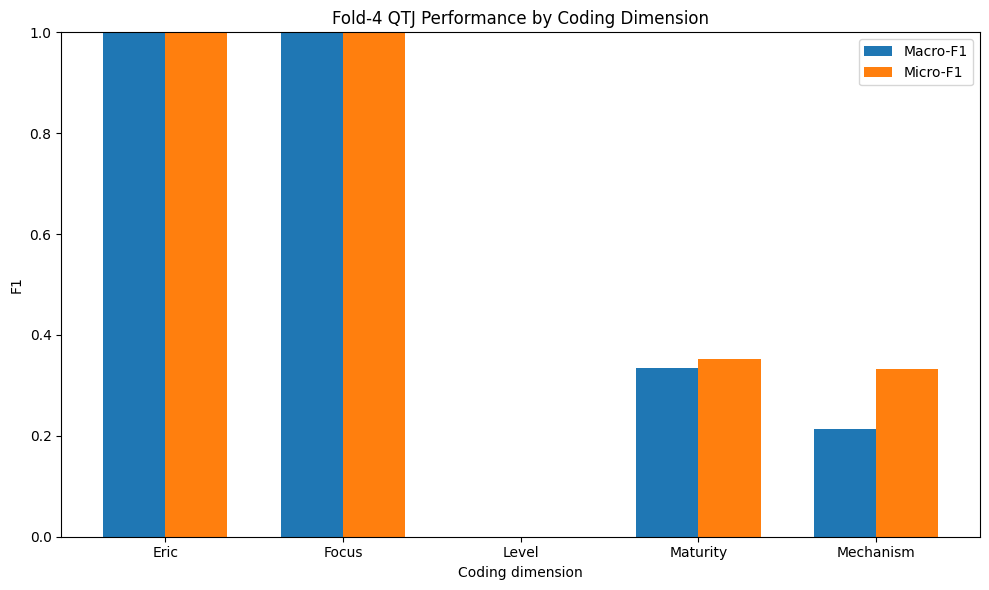

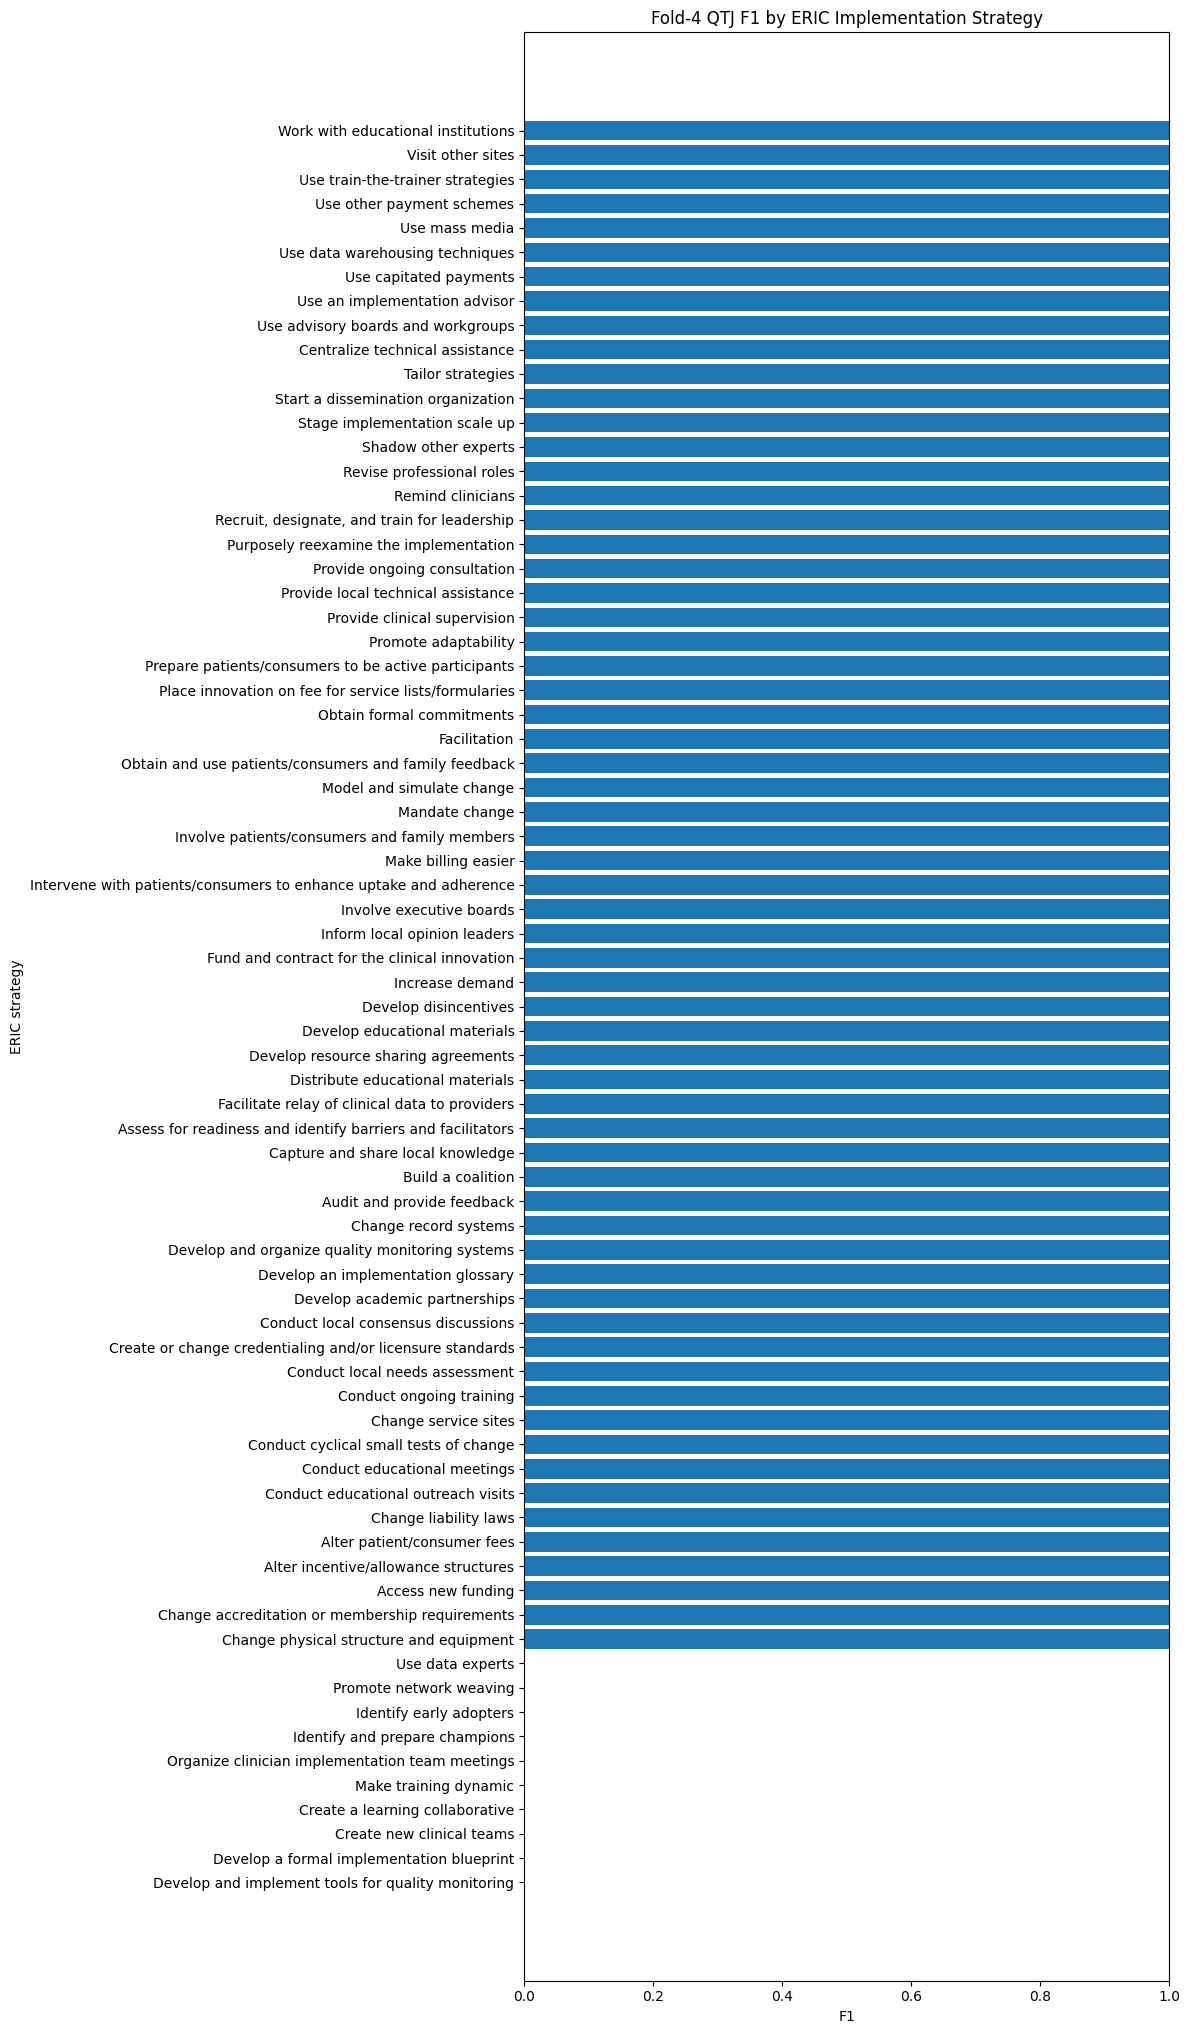

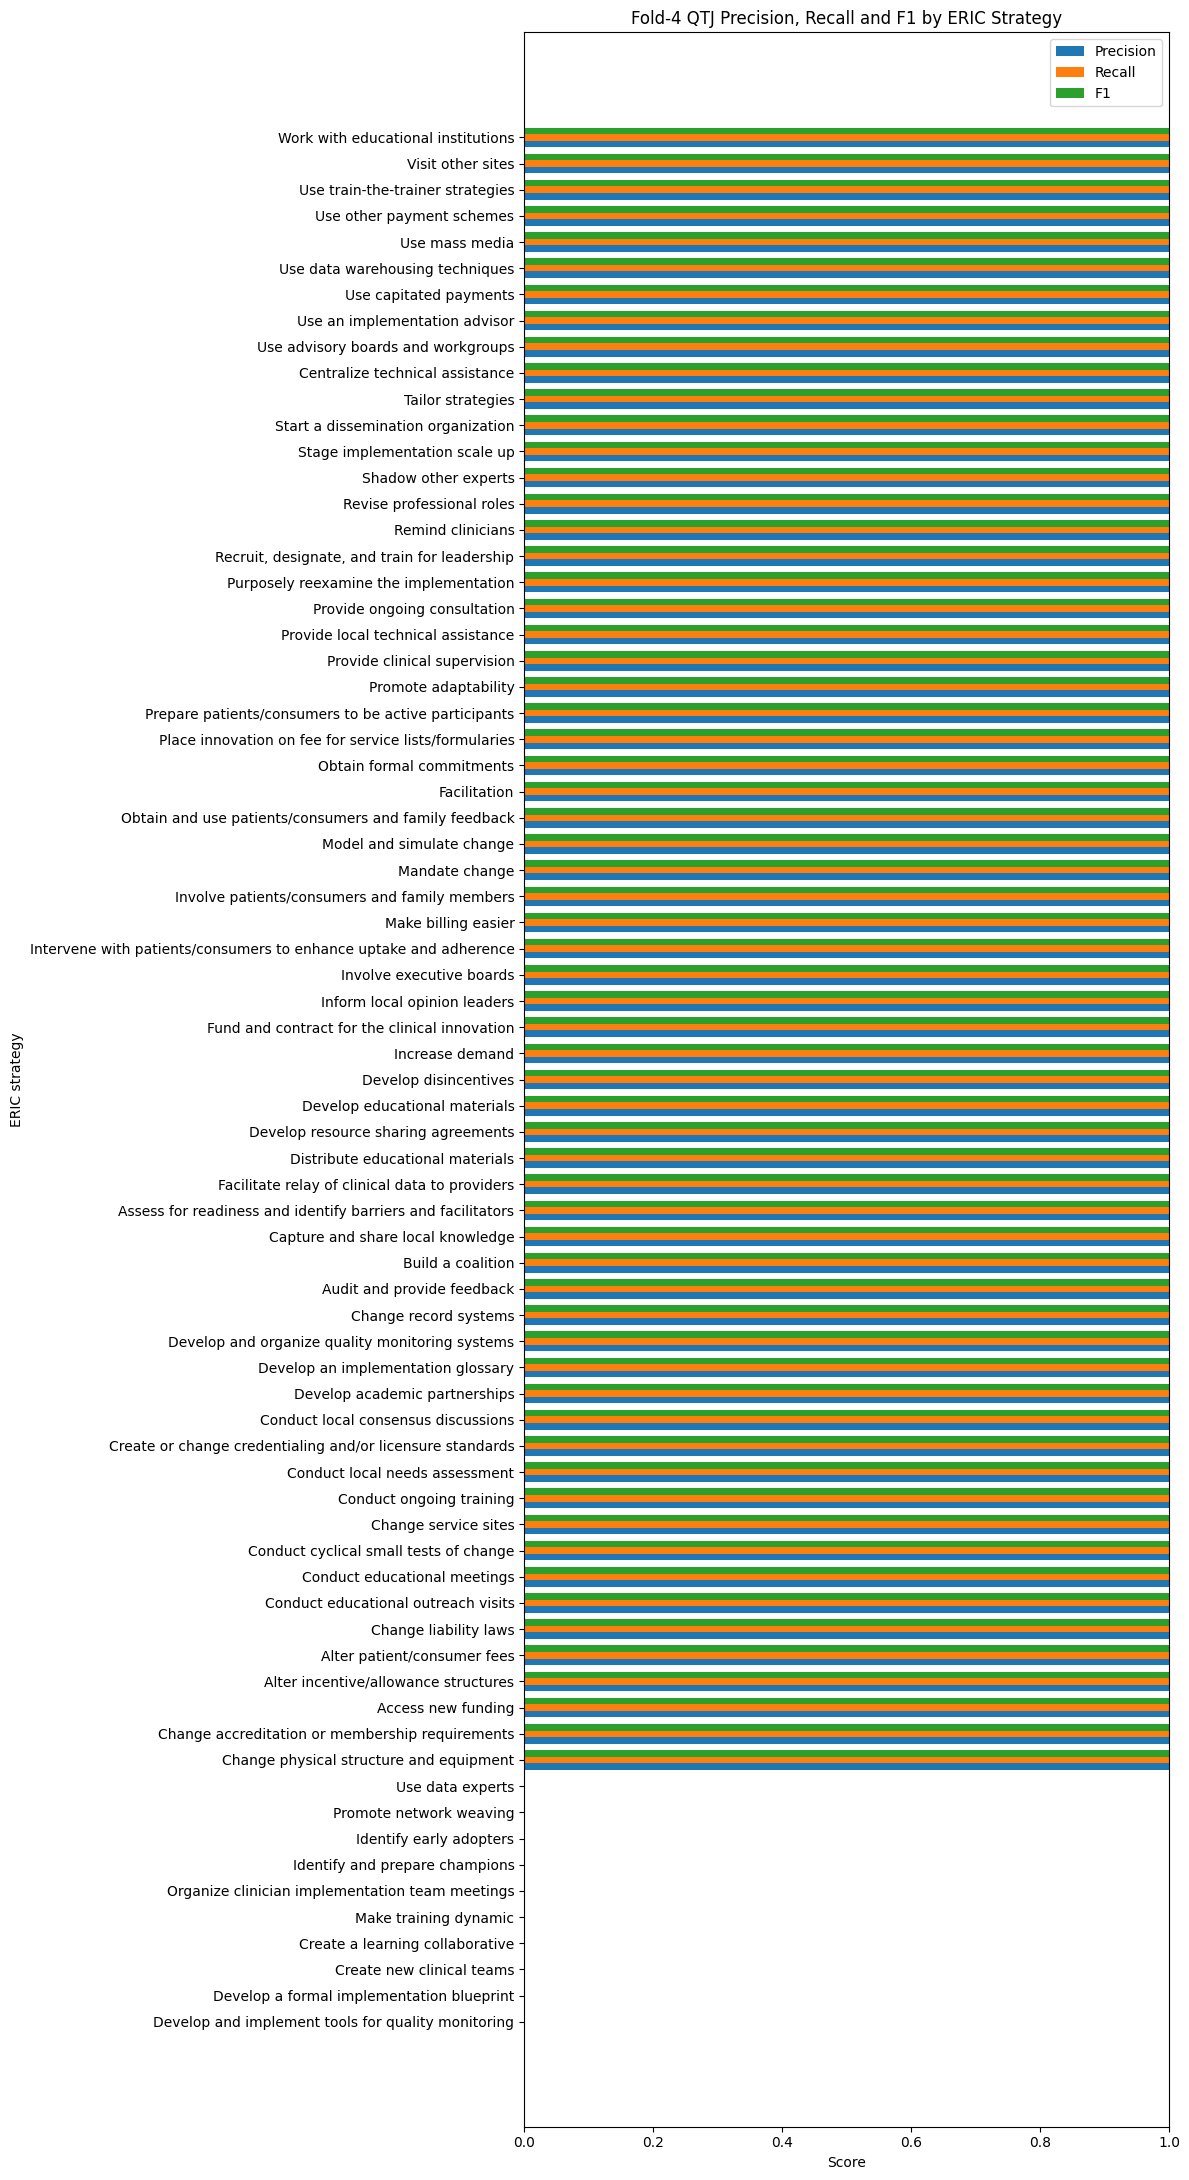

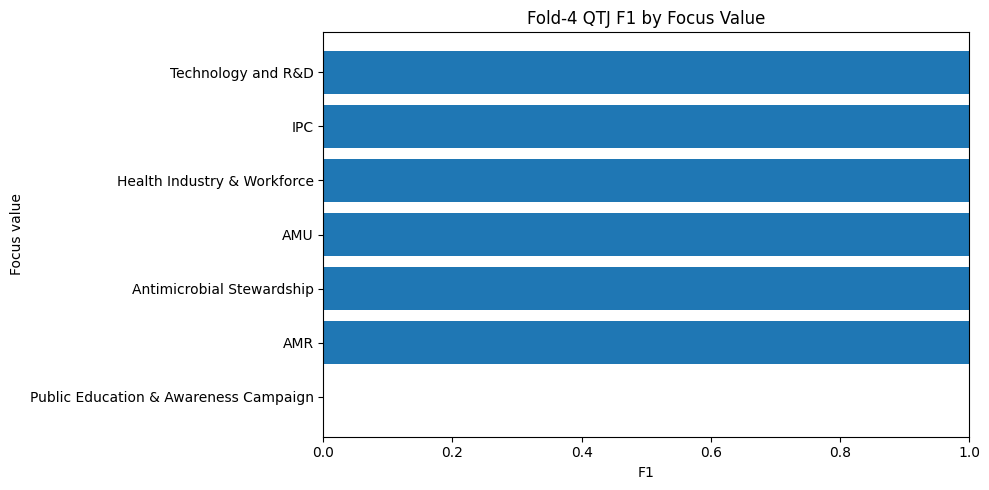

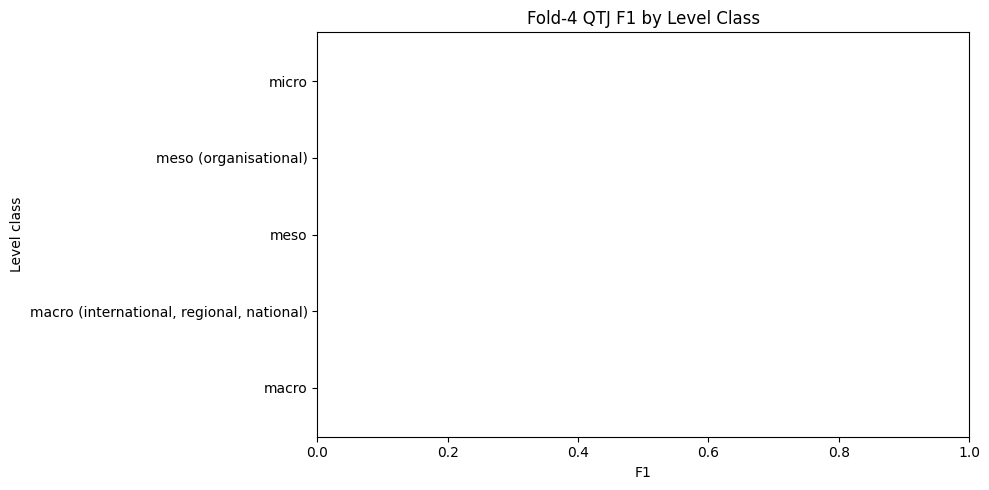

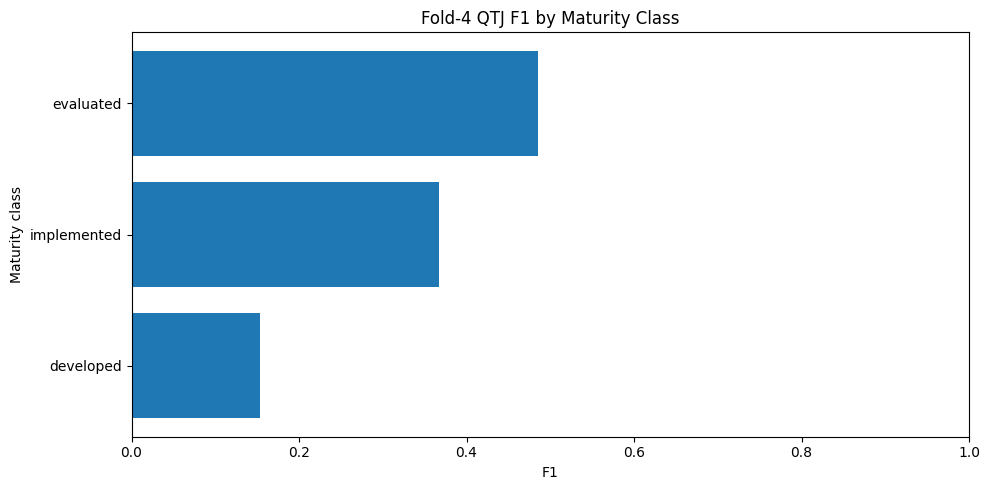

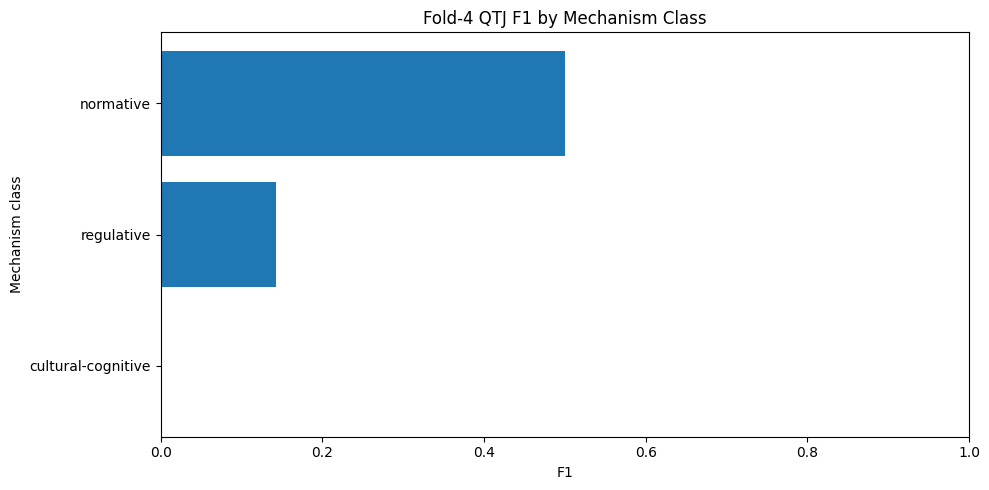

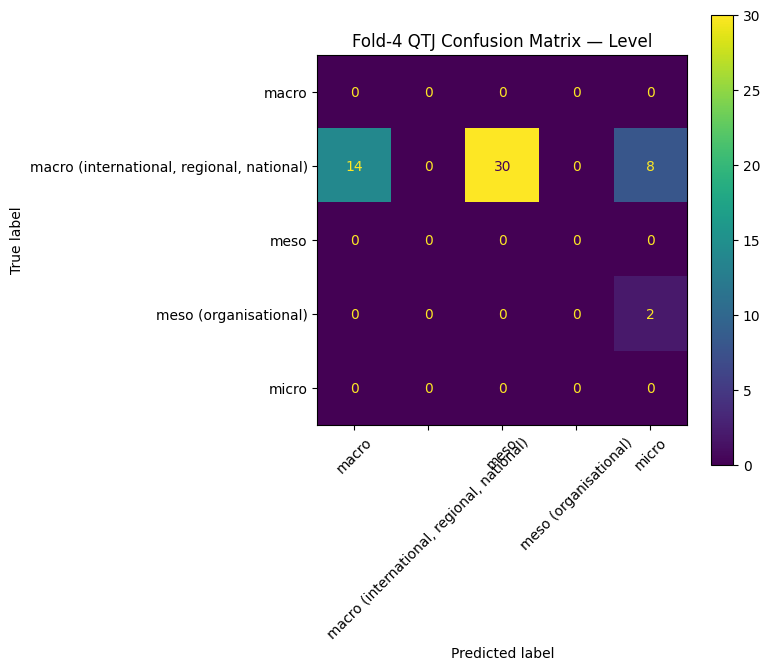

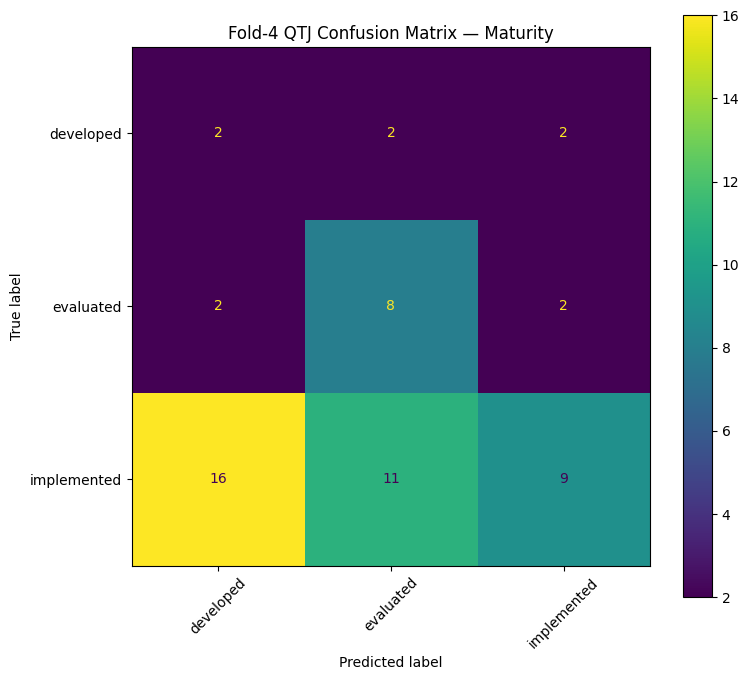

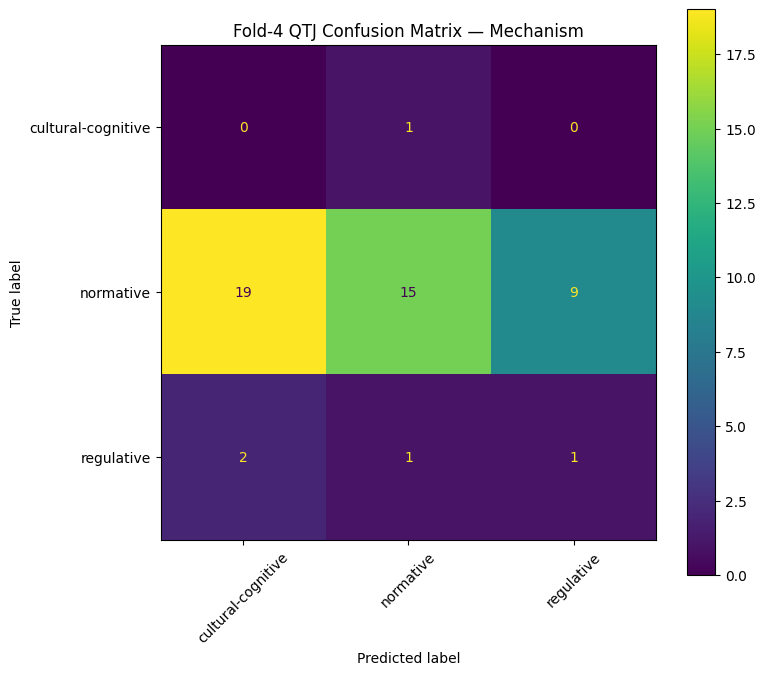


ALL METRICS + PLOTS SAVED
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold4_metrics_plots


In [ ]:
# ============================================================
# CELL 5 — METRICS + THESIS-READY PLOTS
# Uses the predictions already produced by Cell 4
# DO NOT rerun Cell 4
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

PLOT_DIR = DRIVE / "outputs" / "fold4_metrics_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Predictions available:", len(predictions))

# ============================================================
# 1. SAVE RAW PREDICTIONS
# ============================================================

with open(
    PLOT_DIR / "fold4_predictions.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        predictions,
        f,
        ensure_ascii=False,
        indent=2
    )

# ============================================================
# 2. GOLD LOOKUP
# ============================================================

gold_lookup = {
    str(r["doc_id"]): r
    for r in GOLD_ROWS
}

# ============================================================
# 3. MULTI-LABEL DIMENSIONS
#    ERIC + FOCUS
# ============================================================

multi_results = {}
per_label_tables = {}

for dim in ["eric", "focus"]:

    dim_preds = [
        p for p in predictions
        if p["dim"] == dim
    ]

    # --------------------------------------------------------
    # Per candidate
    # --------------------------------------------------------

    labels = sorted(
        set(p["value"] for p in dim_preds)
    )

    y_true_all = []
    y_pred_all = []

    rows = []

    for label in labels:

        y_true = np.array([
            p["label"]
            for p in dim_preds
            if p["value"] == label
        ])

        y_pred = np.array([
            int(p["yes_prob"] >= 0.5)
            for p in dim_preds
            if p["value"] == label
        ])

        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

        rows.append({
            "label": label,
            "n": len(y_true),
            "support": int(y_true.sum()),
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        })

    df = pd.DataFrame(rows)

    per_label_tables[dim] = df

    # --------------------------------------------------------
    # Overall metrics
    # --------------------------------------------------------

    multi_results[dim] = {
        "macro_f1": f1_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        ),
        "micro_f1": f1_score(
            y_true_all,
            y_pred_all,
            average="micro",
            zero_division=0
        ),
        "precision": precision_score(
            y_true_all,
            y_pred_all,
            zero_division=0
        ),
        "recall": recall_score(
            y_true_all,
            y_pred_all,
            zero_division=0
        ),
        "n": len(y_true_all)
    }

# ============================================================
# 4. SINGLE-LABEL DIMENSIONS
#    LEVEL + MATURITY + MECHANISM
# ============================================================

single_results = {}

single_predictions = {}

for dim in ["level", "maturity", "mechanism"]:

    dim_preds = [
        p for p in predictions
        if p["dim"] == dim
    ]

    # Group candidates by document
    by_doc = {}

    for p in dim_preds:
        by_doc.setdefault(
            str(p["doc_id"]),
            []
        ).append(p)

    y_true = []
    y_pred = []

    for doc_id, cases in by_doc.items():

        gold_row = gold_lookup.get(doc_id)

        if gold_row is None:
            continue

        gold_value = norm(
            gold_row.get(dim)
        )

        if not gold_value:
            continue

        # Highest YES probability = predicted class
        best = max(
            cases,
            key=lambda x: x["yes_prob"]
        )

        predicted_value = norm(
            best["value"]
        )

        y_true.append(gold_value)
        y_pred.append(predicted_value)

    single_predictions[dim] = {
        "y_true": y_true,
        "y_pred": y_pred
    }

    labels = sorted(
        set(y_true) | set(y_pred)
    )

    single_results[dim] = {
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        ),
        "micro_f1": f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="micro",
            zero_division=0
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        ),
        "n": len(y_true)
    }

    # --------------------------------------------------------
    # Per-class metrics
    # --------------------------------------------------------

    precision = precision_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    support = cm.sum(axis=1)

    per_label_tables[dim] = pd.DataFrame({
        "label": labels,
        "support": support,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

# ============================================================
# 5. COMBINE OVERALL RESULTS
# ============================================================

results = {}

results.update(multi_results)
results.update(single_results)

overall_rows = []

for dim, m in results.items():

    overall_rows.append({
        "dimension": dim,
        "macro_f1": m["macro_f1"],
        "micro_f1": m["micro_f1"],
        "precision": m["precision"],
        "recall": m["recall"],
        "n": m["n"]
    })

overall_df = pd.DataFrame(
    overall_rows
)

print("\n" + "=" * 70)
print("OVERALL FOLD-4 QTJ METRICS")
print("=" * 70)

display(overall_df)

overall_df.to_csv(
    PLOT_DIR / "overall_dimension_metrics.csv",
    index=False
)

# ============================================================
# 6. SAVE OVERALL JSON
# ============================================================

with open(
    PLOT_DIR / "fold4_overall_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        results,
        f,
        ensure_ascii=False,
        indent=2
    )

# ============================================================
# 7. OVERALL DIMENSION F1
# ============================================================

x = np.arange(len(overall_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    overall_df["macro_f1"],
    width,
    label="Macro-F1"
)

plt.bar(
    x + width / 2,
    overall_df["micro_f1"],
    width,
    label="Micro-F1"
)

plt.xticks(
    x,
    overall_df["dimension"].str.title()
)

plt.ylabel("F1")
plt.xlabel("Coding dimension")
plt.title("Fold-4 QTJ Performance by Coding Dimension")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "overall_dimension_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 8. ERIC — EVERY CODE
# ============================================================

eric_df = per_label_tables["eric"].copy()
eric_df = eric_df.sort_values("f1")

eric_df.to_csv(
    PLOT_DIR / "ERIC_per_code_metrics.csv",
    index=False
)

plt.figure(
    figsize=(12, max(8, len(eric_df) * 0.28))
)

plt.barh(
    eric_df["label"],
    eric_df["f1"]
)

plt.xlabel("F1")
plt.ylabel("ERIC strategy")
plt.title(
    "Fold-4 QTJ F1 by ERIC Implementation Strategy"
)

plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "ERIC_per_strategy_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 9. ERIC — PRECISION / RECALL / F1
# ============================================================

y = np.arange(len(eric_df))
height = 0.25

plt.figure(
    figsize=(12, max(8, len(eric_df) * 0.30))
)

plt.barh(
    y - height,
    eric_df["precision"],
    height,
    label="Precision"
)

plt.barh(
    y,
    eric_df["recall"],
    height,
    label="Recall"
)

plt.barh(
    y + height,
    eric_df["f1"],
    height,
    label="F1"
)

plt.yticks(
    y,
    eric_df["label"]
)

plt.xlabel("Score")
plt.ylabel("ERIC strategy")
plt.title(
    "Fold-4 QTJ Precision, Recall and F1 by ERIC Strategy"
)

plt.xlim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "ERIC_precision_recall_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. FOCUS
# ============================================================

focus_df = per_label_tables["focus"].copy()
focus_df = focus_df.sort_values("f1")

focus_df.to_csv(
    PLOT_DIR / "focus_per_value_metrics.csv",
    index=False
)

plt.figure(
    figsize=(10, max(5, len(focus_df) * 0.6))
)

plt.barh(
    focus_df["label"],
    focus_df["f1"]
)

plt.xlabel("F1")
plt.ylabel("Focus value")
plt.title("Fold-4 QTJ F1 by Focus Value")
plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "focus_per_value_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 11. LEVEL / MATURITY / MECHANISM PER-CLASS
# ============================================================

for dim in ["level", "maturity", "mechanism"]:

    df = per_label_tables[dim].copy()
    df = df.sort_values("f1")

    df.to_csv(
        PLOT_DIR / f"{dim}_per_class_metrics.csv",
        index=False
    )

    plt.figure(
        figsize=(10, max(5, len(df) * 0.7))
    )

    plt.barh(
        df["label"],
        df["f1"]
    )

    plt.xlabel("F1")
    plt.ylabel(dim.title() + " class")
    plt.title(
        f"Fold-4 QTJ F1 by {dim.title()} Class"
    )

    plt.xlim(0, 1)
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"{dim}_per_class_F1.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 12. CONFUSION MATRICES
# ============================================================

for dim in ["level", "maturity", "mechanism"]:

    y_true = single_predictions[dim]["y_true"]
    y_pred = single_predictions[dim]["y_pred"]

    labels = sorted(
        set(y_true) | set(y_pred)
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(
        figsize=(8, 7)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d"
    )

    ax.set_title(
        f"Fold-4 QTJ Confusion Matrix — {dim.title()}"
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"{dim}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 13. COMBINED PER-LABEL TABLE
# ============================================================

combined = []

for dim, df in per_label_tables.items():

    temp = df.copy()

    temp.insert(
        0,
        "dimension",
        dim
    )

    combined.append(temp)

combined_df = pd.concat(
    combined,
    ignore_index=True
)

combined_df.to_csv(
    PLOT_DIR / "ALL_per_label_metrics.csv",
    index=False
)

# ============================================================
# 14. FINAL
# ============================================================

print("\n" + "=" * 70)
print("ALL METRICS + PLOTS SAVED")
print("=" * 70)
print(PLOT_DIR)

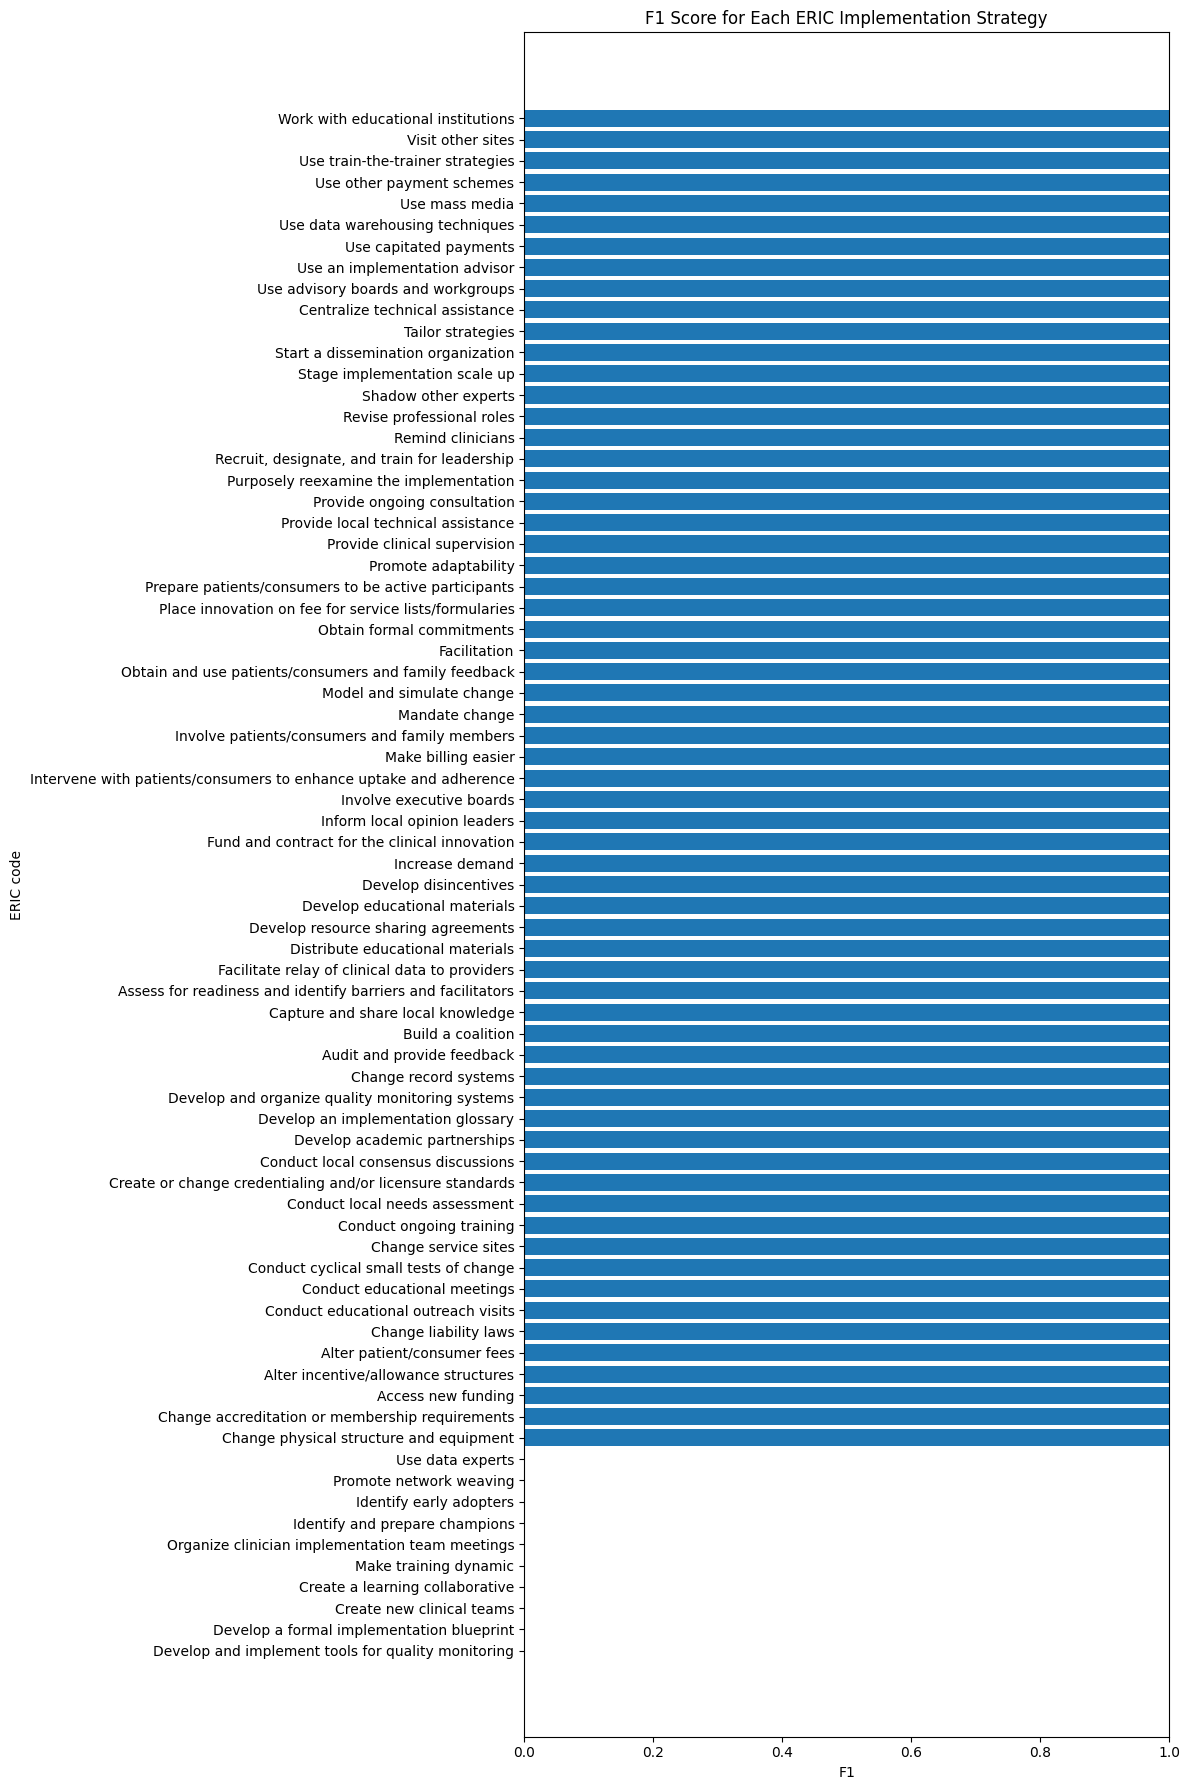

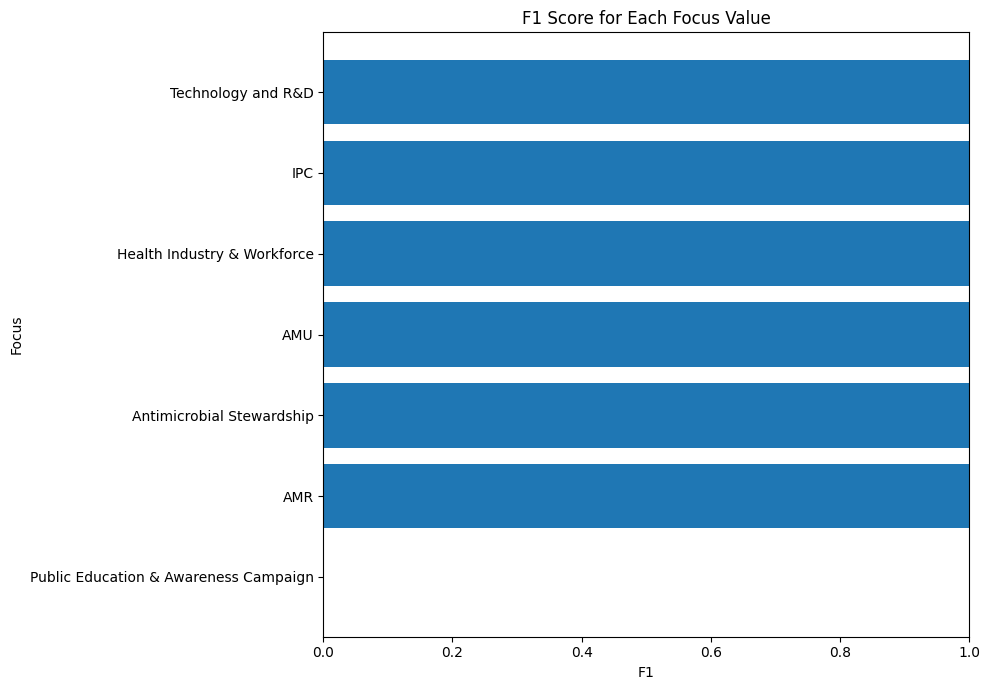

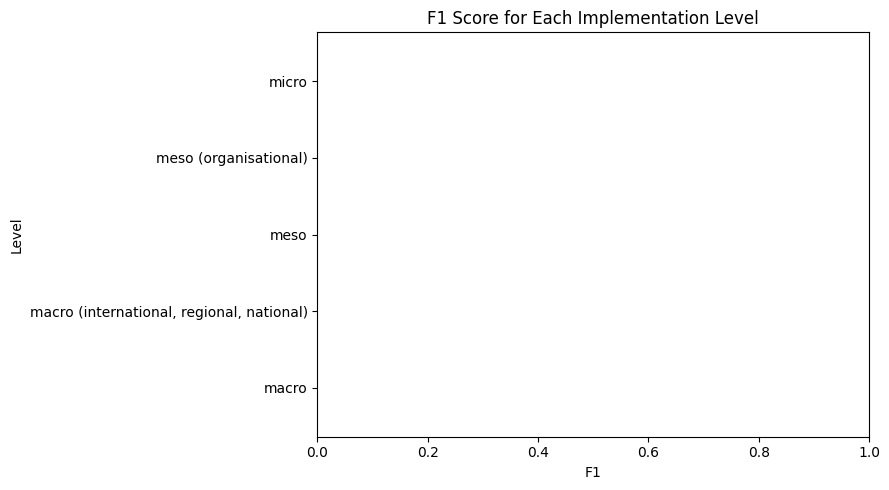

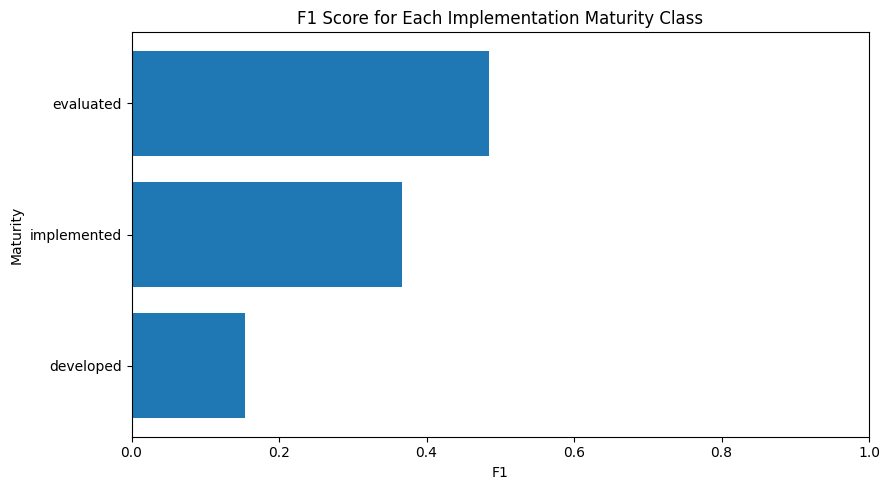

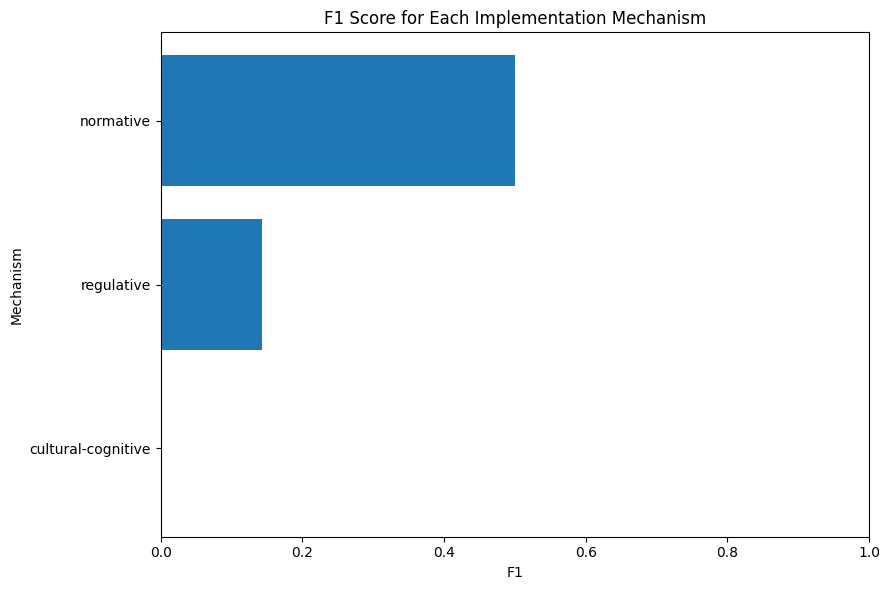


Simple plots saved to:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold4_metrics_plots/simple


In [ ]:
# ============================================================
# CELL 6 — SIMPLE PER-CODE / PER-CLASS F1 PLOTS
# ============================================================

import matplotlib.pyplot as plt

SIMPLE_PLOT_DIR = DRIVE / "outputs" / "fold4_metrics_plots" / "simple"
SIMPLE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# ERIC — every code
# ------------------------------------------------------------

df = per_label_tables["eric"].copy()
df = df.sort_values("f1", ascending=True)

plt.figure(figsize=(12, 18))

plt.barh(
    df["label"],
    df["f1"]
)

plt.xlabel("F1")
plt.ylabel("ERIC code")
plt.title("F1 Score for Each ERIC Implementation Strategy")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    SIMPLE_PLOT_DIR / "ERIC_all_codes_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FOCUS — every value
# ------------------------------------------------------------

df = per_label_tables["focus"].copy()
df = df.sort_values("f1", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    df["label"],
    df["f1"]
)

plt.xlabel("F1")
plt.ylabel("Focus")
plt.title("F1 Score for Each Focus Value")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    SIMPLE_PLOT_DIR / "Focus_all_values_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# LEVEL — every class
# ------------------------------------------------------------

df = per_label_tables["level"].copy()
df = df.sort_values("f1", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    df["label"],
    df["f1"]
)

plt.xlabel("F1")
plt.ylabel("Level")
plt.title("F1 Score for Each Implementation Level")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    SIMPLE_PLOT_DIR / "Level_all_classes_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# MATURITY — every class
# ------------------------------------------------------------

df = per_label_tables["maturity"].copy()
df = df.sort_values("f1", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    df["label"],
    df["f1"]
)

plt.xlabel("F1")
plt.ylabel("Maturity")
plt.title("F1 Score for Each Implementation Maturity Class")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    SIMPLE_PLOT_DIR / "Maturity_all_classes_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# MECHANISM — every class
# ------------------------------------------------------------

df = per_label_tables["mechanism"].copy()
df = df.sort_values("f1", ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    df["label"],
    df["f1"]
)

plt.xlabel("F1")
plt.ylabel("Mechanism")
plt.title("F1 Score for Each Implementation Mechanism")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    SIMPLE_PLOT_DIR / "Mechanism_all_classes_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nSimple plots saved to:")
print(SIMPLE_PLOT_DIR)

In [ ]:
print(type(predictions))
print("Number:", len(predictions))
print("First prediction:")
print(predictions[0])

<class 'list'>
Number: 4806
First prediction:
{'doc_id': 'Brazil_07', 'dim': 'eric', 'value': 'Promote adaptability', 'yes_prob': 0.09521484375, 'label': 0}


In [ ]:
from sklearn.metrics import f1_score
from collections import defaultdict

# Gold labels from test_pairs
gold = defaultdict(set)

for p in test_pairs:
    if p["label"] == 1:
        gold[(p["doc"], p["dim"])].add(p["value"])

print("\nMacro-F1 scores:")

for dim in ["eric", "focus", "level", "maturity", "mechanism"]:

    preds = [p for p in predictions if p["dim"] == dim]

    # All candidate labels for this dimension
    labels = sorted(set(p["value"] for p in preds))

    # Group predictions by document
    doc_preds = defaultdict(dict)

    for p in preds:
        doc_preds[p["doc_id"]][p["value"]] = p["yes_prob"]

    y_true = []
    y_pred = []

    if dim in ["eric", "focus"]:
        # Multi-label dimensions
        for doc, scores in doc_preds.items():
            gold_labels = gold[(doc, dim)]

            for label in labels:
                y_true.append(int(label in gold_labels))
                y_pred.append(int(scores.get(label, 0) >= 0.5))

    else:
        # Single-label dimensions
        for doc, scores in doc_preds.items():
            gold_labels = gold[(doc, dim)]

            if not gold_labels:
                continue

            gold_label = next(iter(gold_labels))
            predicted_label = max(scores, key=scores.get)

            y_true.append(gold_label)
            y_pred.append(predicted_label)

    if dim in ["eric", "focus"]:
        macro = f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        )
    else:
        macro = f1_score(
            y_true, y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        )

    print(f"{dim.capitalize():<12}: {macro:.4f}")


Macro-F1 scores:
Eric        : 0.4796
Focus       : 0.4805
Level       : 0.0000
Maturity    : 0.3353
Mechanism   : 0.2143


In [ ]:
y_true.append(gold_label)
y_pred.append(predicted_label)

In [ ]:
print("LEVEL GOLD VALUES:")
print(sorted(set(
    p["value"]
    for p in test_pairs
    if p["dim"] == "level" and p["label"] == 1
)))

print("\nLEVEL PREDICTION VALUES:")
print(sorted(set(
    p["value"]
    for p in predictions
    if p["dim"] == "level"
)))

print("\nExample Level prediction:")
print(next(p for p in predictions if p["dim"] == "level"))

LEVEL GOLD VALUES:
[]

LEVEL PREDICTION VALUES:
['Macro', 'Meso', 'Micro']

Example Level prediction:
{'doc_id': 'Brazil_07', 'dim': 'level', 'value': 'Macro', 'yes_prob': 0.010986328125, 'label': 0}


In [ ]:
# Check the actual gold Level values in GOLD_ROWS

print("Gold Level values:")
print(sorted(set(
    str(r["level"]).strip()
    for r in GOLD_ROWS
    if r.get("level") not in [None, "", "nan"]
)))

print("\nExample gold records:")
for r in GOLD_ROWS[:5]:
    print(r["doc_id"], "->", r.get("level"))

Gold Level values:
['Macro (International, regional, national)', 'Meso (Organisational)']

Example gold records:
Brazil_01 -> Macro (International, regional, national)
Brazil_02 -> Macro (International, regional, national)
Brazil_03 -> Meso (Organisational)
Brazil_04 -> Macro (International, regional, national)
Brazil_05 -> Macro (International, regional, national)


In [ ]:
from sklearn.metrics import f1_score
from collections import defaultdict

# -----------------------------
# GOLD LABEL NORMALISATION
# -----------------------------
def normalise_level(x):
    x = str(x).strip()

    if x.startswith("Macro"):
        return "Macro"
    if x.startswith("Meso"):
        return "Meso"
    if x.startswith("Micro"):
        return "Micro"

    return x


# Gold lookup directly from gold_full.json
gold_lookup = {}

for r in GOLD_ROWS:
    doc = r["doc_id"]

    gold_lookup[(doc, "eric")] = set(r.get("eric_codes", []))

    # Focus
    focus = str(r.get("focus", "")).strip()
    gold_lookup[(doc, "focus")] = set(
        x.strip() for x in focus.replace("/", ",").split(",") if x.strip()
    )

    # Single-label dimensions
    gold_lookup[(doc, "level")] = {normalise_level(r.get("level", ""))}
    gold_lookup[(doc, "maturity")] = {str(r.get("maturity", "")).strip()}
    gold_lookup[(doc, "mechanism")] = {str(r.get("mechanism", "")).strip()}


print("\nCorrected Macro-F1 scores:")

for dim in ["eric", "focus", "level", "maturity", "mechanism"]:

    preds = [p for p in predictions if p["dim"] == dim]

    # Group candidate probabilities by document
    doc_scores = defaultdict(dict)

    for p in preds:
        value = p["value"]

        if dim == "level":
            value = normalise_level(value)

        doc_scores[p["doc_id"]][value] = p["yes_prob"]

    y_true = []
    y_pred = []

    if dim in ["eric", "focus"]:

        # Multi-label
        labels = sorted(set(
            value
            for scores in doc_scores.values()
            for value in scores
        ))

        for doc, scores in doc_scores.items():

            gold_labels = gold_lookup.get((doc, dim), set())

            for label in labels:
                y_true.append(int(label in gold_labels))
                y_pred.append(
                    int(scores.get(label, 0) >= 0.5)
                )

        macro = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

    else:

        # Single-label: choose highest-probability candidate
        for doc, scores in doc_scores.items():

            gold_labels = gold_lookup.get((doc, dim), set())

            if not gold_labels:
                continue

            gold_label = next(iter(gold_labels))
            predicted_label = max(scores, key=scores.get)

            y_true.append(gold_label)
            y_pred.append(predicted_label)

        labels = sorted(set(y_true) | set(y_pred))

        macro = f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        )

    print(f"{dim.capitalize():<12}: {macro:.4f}")


Corrected Macro-F1 scores:
Eric        : 0.4796
Focus       : 0.4805
Level       : 0.1414
Maturity    : 0.3353
Mechanism   : 0.1487


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
from collections import defaultdict
import pandas as pd
from pathlib import Path

# ============================================================
# 1. NORMALISE LEVEL LABELS
# ============================================================

def normalise_level(x):
    x = str(x).strip()

    if x.startswith("Macro"):
        return "Macro"
    if x.startswith("Meso"):
        return "Meso"
    if x.startswith("Micro"):
        return "Micro"

    return x


# ============================================================
# 2. BUILD GOLD LABEL LOOKUP
# ============================================================

gold_lookup = {}

for r in GOLD_ROWS:
    doc = r["doc_id"]

    # ERIC = multi-label
    gold_lookup[(doc, "eric")] = set(r.get("eric_codes", []))

    # Focus = multi-label
    focus = str(r.get("focus", "")).strip()

    gold_lookup[(doc, "focus")] = set(
        x.strip()
        for x in focus.replace("/", ",").split(",")
        if x.strip()
    )

    # Single-label dimensions
    gold_lookup[(doc, "level")] = {
        normalise_level(r.get("level", ""))
    }

    gold_lookup[(doc, "maturity")] = {
        str(r.get("maturity", "")).strip()
    }

    gold_lookup[(doc, "mechanism")] = {
        str(r.get("mechanism", "")).strip()
    }


# ============================================================
# 3. GROUP PREDICTIONS BY DOCUMENT
# ============================================================

doc_scores = defaultdict(dict)

for p in predictions:

    dim = p["dim"]
    doc = p["doc_id"]
    value = p["value"]

    if dim == "level":
        value = normalise_level(value)

    doc_scores[(doc, dim)][value] = p["yes_prob"]


# ============================================================
# 4. CALCULATE ALL METRICS
# ============================================================

results = []

for dim in ["eric", "focus", "level", "maturity", "mechanism"]:

    dimension_docs = [
        (doc, d)
        for (doc, d) in doc_scores
        if d == dim
    ]

    # --------------------------------------------------------
    # MULTI-LABEL: ERIC + FOCUS
    # --------------------------------------------------------

    if dim in ["eric", "focus"]:

        labels = sorted(set(
            value
            for (doc, d) in dimension_docs
            for value in doc_scores[(doc, d)]
        ))

        y_true = []
        y_pred = []

        for doc, d in dimension_docs:

            gold_labels = gold_lookup.get(
                (doc, dim), set()
            )

            scores = doc_scores[(doc, dim)]

            for label in labels:

                y_true.append(
                    int(label in gold_labels)
                )

                y_pred.append(
                    int(scores.get(label, 0) >= 0.5)
                )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        micro_f1 = f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0
        )

        precision = precision_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0
        )


    # --------------------------------------------------------
    # SINGLE-LABEL: LEVEL + MATURITY + MECHANISM
    # --------------------------------------------------------

    else:

        y_true = []
        y_pred = []

        for doc, d in dimension_docs:

            gold_labels = gold_lookup.get(
                (doc, dim), set()
            )

            if not gold_labels:
                continue

            gold_label = next(iter(gold_labels))

            scores = doc_scores[(doc, dim)]

            predicted_label = max(
                scores,
                key=scores.get
            )

            y_true.append(gold_label)
            y_pred.append(predicted_label)

        labels = sorted(
            set(y_true) | set(y_pred)
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        )

        micro_f1 = f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="micro",
            zero_division=0
        )

        precision = precision_score(
            y_true,
            y_pred,
            labels=labels,
            average="micro",
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            labels=labels,
            average="micro",
            zero_division=0
        )


    results.append({
        "Dimension": dim,
        "Macro-F1": macro_f1,
        "Micro-F1": micro_f1,
        "Precision": precision,
        "Recall": recall
    })


# ============================================================
# 5. PRINT RESULTS
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("QTJ FOLD-4 RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Macro-F1": "{:.4f}".format,
            "Micro-F1": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format
        }
    )
)


# ============================================================
# 6. SAVE TO GOOGLE DRIVE
# ============================================================

OUT_DIR = Path(
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs/fold4_metrics_plots"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = OUT_DIR / "fold4_all_dimension_metrics.csv"

results_df.to_csv(csv_path, index=False)

print("\nSaved to:")
print(csv_path)


QTJ FOLD-4 RESULTS
Dimension Macro-F1 Micro-F1 Precision Recall
     eric   0.4796   0.8638    0.8638 0.8638
    focus   0.4805   0.8254    0.8254 0.8254
    level   0.1414   0.2593    0.2593 0.2593
 maturity   0.3353   0.3519    0.3519 0.3519
mechanism   0.1487   0.2963    0.2963 0.2963

Saved to:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold4_metrics_plots/fold4_all_dimension_metrics.csv


In [ ]:
# ============================================================
# QUOTE-THEN-JUDGE — CORRECTED RE-EVALUATION
#
# This fixes the bug where the "final" pipeline (Cells 91/110/116
# in the original notebook) reconstructed fold-4 membership using
# an MD5-hash function instead of the REAL `fold` field stored in
# gold_full.json. That hash function disagreed with the true fold
# labels on ~82% of documents, which meant the "test set" leaked
# training documents into evaluation.
#
# This script rebuilds the fold-4 test set directly from the
# authoritative `fold` field, reuses the already-trained LoRA
# adapter (no retraining needed), reruns inference, and recomputes
# metrics correctly.
#
# Paste these cells into Colab, one block at a time, in order.
# ============================================================


# ============================================================
# CELL 1 — MOUNT DRIVE + PATHS
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import json
import gzip
import re
import time
from pathlib import Path
from collections import defaultdict, Counter

import torch
import numpy as np

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")
OUT = BASE / "outputs"

GOLD_PATH = BASE / "gold_full.json"
VERDICT_PATH = BASE / "verdict_inputs.json"
DIMDEF_PATH = BASE / "dimension_definitions.json"
EVIDENCE_PATH = OUT / "evidence_qtj_fold4.json"
LORA_PATH = OUT / "fold_4" / "lora_main"

assert GOLD_PATH.exists(), f"Missing: {GOLD_PATH}"
assert VERDICT_PATH.exists(), f"Missing: {VERDICT_PATH}"
assert DIMDEF_PATH.exists(), f"Missing: {DIMDEF_PATH}"
assert EVIDENCE_PATH.exists(), f"Missing: {EVIDENCE_PATH}"
assert LORA_PATH.exists(), f"Missing LoRA adapter: {LORA_PATH}"

print("All required files found.")

DIMENSIONS = ["eric", "focus", "level", "maturity", "mechanism"]
MULTI_LABEL_DIMS = {"eric", "focus"}
SINGLE_LABEL_DIMS = {"level", "maturity", "mechanism"}

HELD_OUT_FOLD = 4
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MAX_SEQ = 1536
BATCH_SIZE = 4


# ============================================================
# CELL 2 — LOAD GOLD DATA + DEFINITIONS (CANDIDATE CODEBOOK)
# ============================================================

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    GOLD_ROWS = json.load(f)

with open(VERDICT_PATH, "r", encoding="utf-8") as f:
    verdict_inputs = json.load(f)

with open(DIMDEF_PATH, "r", encoding="utf-8") as f:
    dimension_definitions = json.load(f)

with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
    evidence_data = json.load(f)

print("Gold records:", len(GOLD_ROWS))
print("Evidence documents:", len(evidence_data))

ERIC_DEFS = dict(verdict_inputs["definitions"])

CANDIDATES = {"eric": dict(ERIC_DEFS)}

for dim in ["focus", "level", "maturity", "mechanism"]:
    cfg = dimension_definitions.get(dim)
    if cfg is None:
        raise KeyError(f"Missing dimension definition for: {dim}")
    values = cfg.get("values", {})
    CANDIDATES[dim] = dict(values)

print("\nCandidate counts:")
for dim in DIMENSIONS:
    print(f"  {dim:12s}: {len(CANDIDATES[dim])}")


# ============================================================
# CELL 3 — THE FIX: REBUILD FOLD-4 TEST DOCUMENTS FROM THE
#           TRUE STORED `fold` FIELD (NOT A HASH FUNCTION)
# ============================================================

# Map every document ID (primary doc_id AND any linked doc_ids)
# to the fold it is ACTUALLY recorded as belonging to.

doc_to_fold = {}

for row in GOLD_ROWS:
    fold = row["fold"]
    linked_ids = row.get("doc_ids") or [row["doc_id"]]
    for did in linked_ids:
        if did in doc_to_fold and doc_to_fold[did] != fold:
            raise ValueError(
                f"Document {did} appears in multiple folds "
                f"({doc_to_fold[did]} and {fold}) — leakage in "
                f"the source gold_full.json itself."
            )
        doc_to_fold[did] = fold

TEST_DOCS = {
    did for did, fold in doc_to_fold.items()
    if fold == HELD_OUT_FOLD
}

TRAIN_DOCS = {
    did for did, fold in doc_to_fold.items()
    if fold != HELD_OUT_FOLD
}

print("TRUE fold-4 test documents:", len(TEST_DOCS))
print("TRUE training documents:", len(TRAIN_DOCS))
print("Overlap (must be zero):", len(TEST_DOCS & TRAIN_DOCS))

assert len(TEST_DOCS & TRAIN_DOCS) == 0, "Leakage detected — stop."

# Sanity check against gold record counts for fold 4
n_records_fold4 = sum(1 for r in GOLD_ROWS if r["fold"] == HELD_OUT_FOLD)
print("Gold records with fold == 4:", n_records_fold4)


# ============================================================
# CELL 4 — GOLD LABEL EXTRACTION (same normalisation logic
#           as the original notebook's Cell 19)
# ============================================================

def gold_values(row, dim):

    if dim == "eric":
        return set(row.get("eric_codes") or [])

    if dim == "focus":
        raw = row.get("focus") or ""
        parts = re.split(r"[/,;&]|\band\b", str(raw), flags=re.IGNORECASE)
        return {p.strip() for p in parts if p.strip()}

    raw = row.get(dim)
    if raw is None or str(raw).strip() == "":
        return set()

    raw_str = str(raw).strip().lower()

    for candidate in CANDIDATES[dim]:
        base = candidate.lower().split(" (")[0]
        if base == raw_str or base in raw_str:
            return {candidate}

    return set()


# Build a lookup: doc_id -> gold row (first record referencing it)
gold_by_doc = {}
for row in GOLD_ROWS:
    linked_ids = row.get("doc_ids") or [row["doc_id"]]
    for did in linked_ids:
        gold_by_doc.setdefault(did, row)


# ============================================================
# CELL 5 — REBUILD test_pairs OVER THE CORRECT 41-DOCUMENT SET
# ============================================================

test_pairs = []

for doc_id in sorted(TEST_DOCS):

    if doc_id not in evidence_data:
        # No retrieval evidence was ever computed for this document
        # (e.g. it failed text extraction). Report and skip.
        print(f"WARNING: no evidence for {doc_id}, skipping.")
        continue

    row = gold_by_doc.get(doc_id)
    if row is None:
        print(f"WARNING: no gold row for {doc_id}, skipping.")
        continue

    for key, item in evidence_data[doc_id].items():

        if "|" not in key:
            continue

        dim, value = key.split("|", 1)

        if dim not in DIMENSIONS:
            continue

        positives = gold_values(row, dim)
        label = int(value in positives)

        test_pairs.append({
            "doc": doc_id,
            "dim": dim,
            "value": value,
            "definition": CANDIDATES[dim].get(value, ""),
            "passage": item.get("passage", ""),
            "evidence": item.get("evidence", ""),
            "label": label,
        })

print("Corrected test pairs:", len(test_pairs))
print("\nBy dimension:")
for dim in DIMENSIONS:
    subset = [p for p in test_pairs if p["dim"] == dim]
    positives = sum(p["label"] for p in subset)
    print(f"  {dim:12s} | pairs = {len(subset):5d} | positive = {positives:4d}")


# ============================================================
# CELL 6 — LOAD MODEL + TRAINED LoRA ADAPTER
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

YES_ID = tok.encode("YES", add_special_tokens=False)
NO_ID = tok.encode("NO", add_special_tokens=False)
assert len(YES_ID) == 1 and len(NO_ID) == 1
YES_ID, NO_ID = YES_ID[0], NO_ID[0]

use_bf16 = torch.cuda.is_bf16_supported()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()

print("Model + LoRA adapter loaded from:", LORA_PATH)


# ============================================================
# CELL 7 — INFERENCE (single-pass judge using retrieved evidence,
#           same scoring mechanism as the original notebook)
# ============================================================

predictions = []

t0 = time.time()

for start in range(0, len(test_pairs), BATCH_SIZE):

    batch = test_pairs[start:start + BATCH_SIZE]

    prompts = []
    for p in batch:
        prompt = f"""You are an expert implementation-science coder.

Candidate label:
{p['value']}

Definition:
{p['definition']}

Policy passage:
{p['passage']}

Evidence quote:
{p['evidence']}

Question:
Does the quoted evidence support assigning the candidate label to this passage?

Answer only YES or NO.
"""
        prompts.append(prompt)

    inputs = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_SEQ,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        logits = model(**inputs).logits
        last_pos = inputs["attention_mask"].sum(dim=1) - 1
        idx = torch.arange(logits.shape[0], device=logits.device)
        last_logits = logits[idx, last_pos, :]

        probs = torch.softmax(
            torch.stack([last_logits[:, NO_ID], last_logits[:, YES_ID]], dim=1),
            dim=1,
        )
        yes_probs = probs[:, 1].float().detach().cpu().numpy()

    for p, prob in zip(batch, yes_probs):
        predictions.append({
            "doc_id": p["doc"],
            "dim": p["dim"],
            "value": p["value"],
            "yes_prob": float(prob),
            "label": p["label"],
        })

    del inputs, logits, last_logits, probs
    if start % (BATCH_SIZE * 10) == 0:
        torch.cuda.empty_cache()

print(f"\nInference complete in {(time.time()-t0)/60:.1f} min.")
print("Predictions:", len(predictions))


# ============================================================
# CELL 8 — METRICS (macro/micro F1, precision, recall)
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd

def normalise_level(x):
    x = str(x).strip()
    if x.startswith("Macro"):
        return "Macro"
    if x.startswith("Meso"):
        return "Meso"
    if x.startswith("Micro"):
        return "Micro"
    return x

# Ground truth per (doc, dim)
gold_lookup = {}
for doc_id in TEST_DOCS:
    row = gold_by_doc.get(doc_id)
    if row is None:
        continue
    for dim in DIMENSIONS:
        vals = gold_values(row, dim)
        if dim == "level":
            vals = {normalise_level(v) for v in vals}
        gold_lookup[(doc_id, dim)] = vals

# Group predicted scores by (doc, dim)
doc_scores = defaultdict(dict)
for p in predictions:
    value = p["value"]
    if p["dim"] == "level":
        value = normalise_level(value)
    doc_scores[(p["doc_id"], p["dim"])][value] = p["yes_prob"]

results = []

for dim in DIMENSIONS:

    dim_keys = [(d, dd) for (d, dd) in doc_scores if dd == dim]

    y_true, y_pred = [], []

    if dim in MULTI_LABEL_DIMS:

        labels = sorted(set(
            v for k in dim_keys for v in doc_scores[k]
        ))

        for doc, d in dim_keys:
            gold_set = gold_lookup.get((doc, dim), set())
            scores = doc_scores[(doc, dim)]
            for label in labels:
                y_true.append(int(label in gold_set))
                y_pred.append(int(scores.get(label, 0) >= 0.5))

        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
        precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
        recall = recall_score(y_true, y_pred, average="micro", zero_division=0)

    else:

        for doc, d in dim_keys:
            gold_set = gold_lookup.get((doc, dim), set())
            if not gold_set:
                continue
            gold_label = next(iter(gold_set))
            scores = doc_scores[(doc, dim)]
            predicted_label = max(scores, key=scores.get)
            y_true.append(gold_label)
            y_pred.append(predicted_label)

        labels = sorted(set(y_true) | set(y_pred))
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        precision = precision_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        recall = recall_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)

    results.append({
        "Dimension": dim,
        "Macro-F1": macro_f1,
        "Micro-F1": micro_f1,
        "Precision": precision,
        "Recall": recall,
        "N_docs": len(dim_keys),
    })

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("QTJ FOLD-4 RESULTS  —  CORRECTED (true fold split, no leakage)")
print("=" * 70)
print(results_df.to_string(index=False, formatters={
    "Macro-F1": "{:.4f}".format,
    "Micro-F1": "{:.4f}".format,
    "Precision": "{:.4f}".format,
    "Recall": "{:.4f}".format,
}))


# ============================================================
# CELL 9 — SAVE CORRECTED RESULTS
# ============================================================

OUT_DIR = OUT / "fold4_metrics_plots_CORRECTED"
OUT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(OUT_DIR / "fold4_all_dimension_metrics_CORRECTED.csv", index=False)

with open(OUT_DIR / "fold4_predictions_CORRECTED.json", "w", encoding="utf-8") as f:
    json.dump(predictions, f, ensure_ascii=False, indent=2)

print("\nSaved corrected results to:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All required files found.
Gold records: 228
Evidence documents: 221

Candidate counts:
  eric        : 73
  focus       : 7
  level       : 3
  maturity    : 3
  mechanism   : 3
TRUE fold-4 test documents: 40
TRUE training documents: 180
Overlap (must be zero): 0
Gold records with fold == 4: 41
Corrected test pairs: 3560

By dimension:
  eric         | pairs =  2920 | positive =  315
  focus        | pairs =   280 | positive =   41
  level        | pairs =   120 | positive =   40
  maturity     | pairs =   120 | positive =   40
  mechanism    | pairs =   120 | positive =   33


model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Model + LoRA adapter loaded from: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold_4/lora_main

Inference complete in 19.2 min.
Predictions: 3560

QTJ FOLD-4 RESULTS  —  CORRECTED (true fold split, no leakage)
Dimension Macro-F1 Micro-F1 Precision Recall  N_docs
     eric   0.4925   0.8801    0.8801 0.8801      40
    focus   0.4789   0.8429    0.8429 0.8429      40
    level   0.2881   0.5750    0.5750 0.5750      40
 maturity   0.3052   0.3500    0.3500 0.3500      40
mechanism   0.3054   0.5455    0.5455 0.5455      40

Saved corrected results to: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs/fold4_metrics_plots_CORRECTED


In [ ]:
!pip install -U bitsandbytes>=0.46.1